In [18]:
import os

print(os.getcwd())

c:\Users\omdae\OneDrive\Desktop\Mero_Predict\notebooks


In [19]:
print(os.listdir())

['company data.ipynb']


In [20]:
import glob
import os

DATA_DIR = r"C:\Users\omdae\Nepse_Dataset"

all_files = glob.glob(
    os.path.join(DATA_DIR, "*.csv")
)

# Get filenames only
file_names = [
    os.path.basename(file)
    for file in all_files
]

# Sort by filename/date
file_names.sort()

print("Total CSV files:", len(file_names))
print("Oldest file:", file_names[0])
print("Latest file:", file_names[-1])

Total CSV files: 891
Oldest file: 2024_03_04.csv
Latest file: symbol_classification.csv


In [21]:
import pandas as pd

DATA_DIR = r"C:\Users\omdae\Nepse_Dataset"

df = pd.read_csv(
    DATA_DIR + r"\2024_03_04.csv"
)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (237, 21)

Columns:
['S.No', 'Symbol', 'Conf.', 'Open', 'High', 'Low', 'Close', 'VWAP', 'Vol', 'Prev. Close', 'Turnover', 'Trans.', 'Diff', 'Range', 'Diff %', 'Range %', 'VWAP %', '120 Days', '180 Days', '52 Weeks High', '52 Weeks Low']

First 5 rows:


,S.No,Symbol,Conf.,Open,High,Low,Close,VWAP,Vol,Prev. Close,...,Trans.,Diff,Range,Diff %,Range %,VWAP %,120 Days,180 Days,52 Weeks High,52 Weeks Low
0,1,ADBL,47.59,228.00,237.40,228.00,237.40,228.65,530.00,224.00,...,5,13.4,9.4,5.98,4.12,3.69,247.55,245.16,307.70,223.00
1,2,AHL,47.46,429.70,463.40,429.70,463.40,442.77,130.00,421.30,...,9,42.1,33.7,9.99,7.84,4.45,368.54,360.96,504.00,273.10
2,3,AHPC,50.05,179.70,193.80,179.70,193.80,191.64,"14,812.00",176.20,...,52,17.6,14.1,9.99,7.85,1.12,218.88,234.61,316.00,176.00
3,4,AKJCL,33.43,215.70,232.60,215.70,217.00,229.49,"4,000.00",211.50,...,21,5.5,16.9,2.60,7.83,-5.75,183.08,187.64,250.00,141.30
4,5,AKPL,48.71,177.40,191.40,177.40,188.00,189.13,"17,823.00",174.00,...,66,14.0,14.0,8.05,7.89,-0.60,182.15,219.04,422.00,152.40


In [22]:
print(df.dtypes)

S.No               int64
Symbol               str
Conf.            float64
Open                 str
High                 str
Low                  str
Close                str
VWAP                 str
Vol                  str
Prev. Close          str
Turnover             str
Trans.             int64
Diff             float64
Range            float64
Diff %           float64
Range %          float64
VWAP %           float64
120 Days             str
180 Days             str
52 Weeks High        str
52 Weeks Low         str
dtype: object


In [23]:
print(df.isnull().sum())

S.No             0
Symbol           0
Conf.            0
Open             0
High             0
Low              0
Close            0
VWAP             0
Vol              0
Prev. Close      0
Turnover         0
Trans.           0
Diff             0
Range            0
Diff %           0
Range %          0
VWAP %           0
120 Days         0
180 Days         0
52 Weeks High    0
52 Weeks Low     0
dtype: int64


In [24]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [25]:
print("Number of companies:", df["Symbol"].nunique())

Number of companies: 237


In [26]:
print(df["Symbol"].unique())

<StringArray>
[ 'ADBL',   'AHL',  'AHPC', 'AKJCL',  'AKPL', 'ALBSL', 'ALICL',  'ANLB',
   'API', 'AVYAN',
 ...
  'UMHL',  'UMRH', 'UNHPL',  'UPCL', 'UPPER', 'USHEC',  'USHL',  'USLB',
  'VLBS', 'VLUCL']
Length: 237, dtype: str


In [27]:
import glob
import pandas as pd
import os

DATA_DIR = r"C:\Users\omdae\Nepse_Dataset"

all_files = glob.glob(
    os.path.join(DATA_DIR, "*.csv")
)

df_list = []

for file in all_files:
    filename = os.path.splitext(
        os.path.basename(file)
    )[0]

    # Only process files with YYYY_MM_DD format
    try:
        date = pd.to_datetime(
            filename,
            format="%Y_%m_%d"
        )
    except ValueError:
        continue

    temp_df = pd.read_csv(file)
    temp_df["Date"] = date

    df_list.append(temp_df)

df = pd.concat(
    df_list,
    ignore_index=True
)

print("Shape:", df.shape)
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

Shape: (287022, 25)
Start date: 2024-03-04 00:00:00
End date: 2026-08-27 00:00:00


In [28]:
print(df.head())

   S.No Symbol  Conf.    Open    High     Low   Close    VWAP        Vol  \
0     1   ADBL  47.59  228.00  237.40  228.00  237.40  228.65     530.00   
1     2    AHL  47.46  429.70  463.40  429.70  463.40  442.77     130.00   
2     3   AHPC  50.05  179.70  193.80  179.70  193.80  191.64  14,812.00   
3     4  AKJCL  33.43  215.70  232.60  215.70  217.00  229.49   4,000.00   
4     5   AKPL  48.71  177.40  191.40  177.40  188.00  189.13  17,823.00   

  Prev. Close  ... Range % VWAP % 120 Days 180 Days  52 Weeks High  \
0      224.00  ...    4.12   3.69   247.55   245.16         307.70   
1      421.30  ...    7.84   4.45   368.54   360.96         504.00   
2      176.20  ...    7.85   1.12   218.88   234.61         316.00   
3      211.50  ...    7.83  -5.75   183.08   187.64         250.00   
4      174.00  ...    7.89  -0.60   182.15   219.04         422.00   

   52 Weeks Low       Date  LTP Close - LTP Close - LTP %  
0        223.00 2024-03-04  NaN         NaN           NaN  
1 

In [29]:
print(df.tail())

        S.No Symbol  Conf.      Open      High       Low     Close      VWAP  \
287017   344   USLB  30.39    945.00    970.00    941.00    970.00    953.15   
287018   345   VLBS  28.77    610.20    628.50    610.20    620.00    622.67   
287019   346  VLUCL  34.53    368.00    383.50    368.00    383.50    373.74   
287020   347   WNLB   24.2  1,125.00  1,125.00  1,107.00  1,110.00  1,111.40   
287021   348   YMHL  20.81    575.00    593.90    561.50    593.90    578.62   

             Vol Prev. Close  ... Range % VWAP %  120 Days  180 Days  \
287017  2,224.00      970.00  ...    3.08   1.74  1,270.93  1,348.44   
287018  1,533.00      627.90  ...    3.00  -0.43    712.34    731.80   
287019  4,663.00      374.00  ...    4.21   2.54    484.68    513.74   
287020    516.00    1,126.00  ...    1.63  -0.13  1,429.92  1,517.97   
287021  9,782.00      589.90  ...    5.77   2.57      0.00      0.00   

        52 Weeks High  52 Weeks Low       Date       LTP Close - LTP  \
287017       2

In [30]:
print("Unique dates:", df["Date"].nunique())
print("Unique companies:", df["Symbol"].nunique())

Unique dates: 890
Unique companies: 521


In [31]:
print(df.isnull().sum())

S.No                  0
Symbol                0
Conf.                 0
Open                  0
High                  0
Low                   0
Close                 0
VWAP                  0
Vol                   0
Prev. Close           0
Turnover              0
Trans.                0
Diff                  0
Range                 0
Diff %                0
Range %               0
VWAP %                0
120 Days              0
180 Days              0
52 Weeks High         0
52 Weeks Low          0
Date                  0
LTP              121181
Close - LTP      121823
Close - LTP %    121823
dtype: int64


In [32]:
print(df[["LTP", "Close - LTP", "Close - LTP %"]].notnull().sum())

LTP              165841
Close - LTP      165199
Close - LTP %    165199
dtype: int64


In [33]:
df_clean = df.drop(columns=["LTP", "Close - LTP", "Close - LTP %"])

print("Shape:", df_clean.shape)
print(df_clean.columns.tolist())

Shape: (287022, 22)
['S.No', 'Symbol', 'Conf.', 'Open', 'High', 'Low', 'Close', 'VWAP', 'Vol', 'Prev. Close', 'Turnover', 'Trans.', 'Diff', 'Range', 'Diff %', 'Range %', 'VWAP %', '120 Days', '180 Days', '52 Weeks High', '52 Weeks Low', 'Date']


In [34]:
print(df_clean.dtypes[df_clean.dtypes == "object"])

Conf.     object
Trans.    object
Diff      object
Range     object
dtype: object


In [35]:
numeric_cols = [
    "Conf.", "Open", "High", "Low", "Close", "VWAP",
    "Vol", "Prev. Close", "Turnover", "Trans.",
    "Diff", "Range", "120 Days", "180 Days",
    "52 Weeks High", "52 Weeks Low"
]

In [36]:
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(
        df_clean[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

In [37]:
print(df_clean.dtypes)

S.No                      int64
Symbol                      str
Conf.                   float64
Open                    float64
High                    float64
Low                     float64
Close                   float64
VWAP                    float64
Vol                     float64
Prev. Close             float64
Turnover                float64
Trans.                    int64
Diff                    float64
Range                   float64
Diff %                  float64
Range %                 float64
VWAP %                  float64
120 Days                float64
180 Days                float64
52 Weeks High           float64
52 Weeks Low            float64
Date             datetime64[us]
dtype: object


In [38]:
print(df_clean.isnull().sum())

S.No                  0
Symbol                0
Conf.            137208
Open                  0
High                  0
Low                   0
Close                 0
VWAP                  0
Vol                   0
Prev. Close           0
Turnover              0
Trans.                0
Diff                  0
Range                 0
Diff %                0
Range %               0
VWAP %                0
120 Days            650
180 Days            650
52 Weeks High         0
52 Weeks Low          0
Date                  0
dtype: int64


In [39]:
print(df_clean[df_clean["Conf."].isna()][["Symbol", "Date"]].head(10))

     Symbol       Date
861  ACLBSL 2024-03-07
862    ADBL 2024-03-07
863     AHL 2024-03-07
864    AHPC 2024-03-07
865   AKJCL 2024-03-07
866    AKPL 2024-03-07
867   ALBSL 2024-03-07
868   ALICL 2024-03-07
869  ALICLP 2024-03-07
870    ANLB 2024-03-07


In [40]:
print("Conf. missing percentage:",
      df_clean["Conf."].isna().mean() * 100)

Conf. missing percentage: 47.80400108702469


In [41]:
df_clean = df_clean.drop(columns=["Conf."])

print("Shape:", df_clean.shape)

Shape: (287022, 21)


In [42]:
missing_120_180 = df_clean[
    df_clean["120 Days"].isna() | df_clean["180 Days"].isna()
]

print("Rows with missing 120/180 Days:", len(missing_120_180))

display(missing_120_180[["Symbol", "Date", "120 Days", "180 Days"]].head(20))

Rows with missing 120/180 Days: 650


,Symbol,Date,120 Days,180 Days
48690,ACLBSL,2024-08-06,NaN,NaN
48691,ADBL,2024-08-06,NaN,NaN
48692,AHL,2024-08-06,NaN,NaN
48693,AHPC,2024-08-06,NaN,NaN
48694,AKJCL,2024-08-06,NaN,NaN
48695,AKPL,2024-08-06,NaN,NaN
48696,ALBSL,2024-08-06,NaN,NaN
48697,ALICL,2024-08-06,NaN,NaN
48698,ANLB,2024-08-06,NaN,NaN
48699,API,2024-08-06,NaN,NaN


In [43]:
df_clean = df_clean.drop(columns=["120 Days", "180 Days"])

print("Shape:", df_clean.shape)
print(df_clean.isnull().sum())

Shape: (287022, 19)
S.No             0
Symbol           0
Open             0
High             0
Low              0
Close            0
VWAP             0
Vol              0
Prev. Close      0
Turnover         0
Trans.           0
Diff             0
Range            0
Diff %           0
Range %          0
VWAP %           0
52 Weeks High    0
52 Weeks Low     0
Date             0
dtype: int64


In [44]:
print("Exact duplicate rows:", df_clean.duplicated().sum())

Exact duplicate rows: 0


In [45]:
print(
    "Duplicate Date + Symbol:",
    df_clean.duplicated(subset=["Date", "Symbol"]).sum()
)

Duplicate Date + Symbol: 0


In [46]:
df_clean.describe()

,S.No,Open,High,Low,Close,VWAP,Vol,Prev. Close,Turnover,Trans.,Diff,Range,Diff %,Range %,VWAP %,52 Weeks High,52 Weeks Low,Date
count,287022.000000,287022.000000,287022.000000,287022.000000,287022.000000,287022.000000,2.870220e+05,287022.000000,2.870220e+05,287022.000000,287022.000000,287022.000000,287022.000000,287022.000000,287022.000000,287022.000000,287022.000000,287022
mean,162.284800,976.187968,991.697367,962.617831,976.542236,975.281961,5.365806e+04,976.153625,2.288356e+07,254.822244,0.413962,29.079536,0.069612,3.395150,0.036526,1249.828686,734.959036,2025-05-31 05:25:16.474695
min,1.000000,6.920000,7.060000,0.000000,7.000000,7.050000,1.000000e+00,0.000000,1.399000e+02,0.000000,-3737.000000,-19.000000,-15.000000,-1.640000,-548.000000,7.990000,0.000000,2024-03-04 00:00:00
25%,81.000000,315.100000,322.000000,310.300000,316.000000,316.040000,3.282000e+03,315.640000,1.335797e+06,29.000000,-5.800000,5.900000,-1.120000,1.860000,-0.440000,398.000000,219.500000,2024-10-16 00:00:00
50%,162.000000,571.400000,583.300000,561.300000,571.500000,571.290000,1.442000e+04,571.200000,6.993904e+06,112.000000,-0.060000,14.800000,-0.080000,2.890000,0.000000,760.000000,404.100000,2025-06-03 00:00:00
75%,243.000000,979.000000,993.000000,963.100000,980.000000,978.312500,4.706225e+04,979.695000,2.081417e+07,276.000000,4.200000,29.000000,0.940000,4.330000,0.520000,1155.000000,717.000000,2026-01-13 00:00:00
max,383.000000,55080.000000,56805.800000,53400.000000,55000.000000,54715.850000,1.400623e+07,55000.000000,2.012993e+09,59382.000000,4113.900000,5587.000000,20.000000,380.000000,92.870000,56805.800000,45200.000000,2026-08-27 00:00:00
std,93.834012,2890.386527,2912.943725,2864.069625,2886.288548,2885.242670,1.611254e+05,2885.518446,5.531305e+07,594.980489,60.852282,79.108896,2.328495,2.649454,5.697768,3425.266767,2412.226034,NaN


In [47]:
display(df_clean.describe())

,S.No,Open,High,Low,Close,VWAP,Vol,Prev. Close,Turnover,Trans.,Diff,Range,Diff %,Range %,VWAP %,52 Weeks High,52 Weeks Low,Date
count,287022.000000,287022.000000,287022.000000,287022.000000,287022.000000,287022.000000,2.870220e+05,287022.000000,2.870220e+05,287022.000000,287022.000000,287022.000000,287022.000000,287022.000000,287022.000000,287022.000000,287022.000000,287022
mean,162.284800,976.187968,991.697367,962.617831,976.542236,975.281961,5.365806e+04,976.153625,2.288356e+07,254.822244,0.413962,29.079536,0.069612,3.395150,0.036526,1249.828686,734.959036,2025-05-31 05:25:16.474695
min,1.000000,6.920000,7.060000,0.000000,7.000000,7.050000,1.000000e+00,0.000000,1.399000e+02,0.000000,-3737.000000,-19.000000,-15.000000,-1.640000,-548.000000,7.990000,0.000000,2024-03-04 00:00:00
25%,81.000000,315.100000,322.000000,310.300000,316.000000,316.040000,3.282000e+03,315.640000,1.335797e+06,29.000000,-5.800000,5.900000,-1.120000,1.860000,-0.440000,398.000000,219.500000,2024-10-16 00:00:00
50%,162.000000,571.400000,583.300000,561.300000,571.500000,571.290000,1.442000e+04,571.200000,6.993904e+06,112.000000,-0.060000,14.800000,-0.080000,2.890000,0.000000,760.000000,404.100000,2025-06-03 00:00:00
75%,243.000000,979.000000,993.000000,963.100000,980.000000,978.312500,4.706225e+04,979.695000,2.081417e+07,276.000000,4.200000,29.000000,0.940000,4.330000,0.520000,1155.000000,717.000000,2026-01-13 00:00:00
max,383.000000,55080.000000,56805.800000,53400.000000,55000.000000,54715.850000,1.400623e+07,55000.000000,2.012993e+09,59382.000000,4113.900000,5587.000000,20.000000,380.000000,92.870000,56805.800000,45200.000000,2026-08-27 00:00:00
std,93.834012,2890.386527,2912.943725,2864.069625,2886.288548,2885.242670,1.611254e+05,2885.518446,5.531305e+07,594.980489,60.852282,79.108896,2.328495,2.649454,5.697768,3425.266767,2412.226034,NaN


In [48]:
print(df_clean["Date"].head())

0   2024-03-04
1   2024-03-04
2   2024-03-04
3   2024-03-04
4   2024-03-04
Name: Date, dtype: datetime64[us]


In [49]:
df_clean.isnull().sum()

S.No             0
Symbol           0
Open             0
High             0
Low              0
Close            0
VWAP             0
Vol              0
Prev. Close      0
Turnover         0
Trans.           0
Diff             0
Range            0
Diff %           0
Range %          0
VWAP %           0
52 Weeks High    0
52 Weeks Low     0
Date             0
dtype: int64

In [50]:
df_clean["Symbol"].nunique()

521

In [51]:
df_clean["Symbol"].unique()

<StringArray>
[      'ADBL',        'AHL',       'AHPC',      'AKJCL',       'AKPL',
      'ALBSL',      'ALICL',       'ANLB',        'API',      'AVYAN',
 ...
      'ADBLB',        'ECL',       'SEF2',      'LSH12',      'SAEF2',
       'RSY2',      'MEPDL',      'SAPIL',    'ADBLB87', 'NMBUR93/94']
Length: 521, dtype: str

In [52]:
# Count symbols ending with P
print("Promoter/Preference-like symbols:", 
      df_clean["Symbol"].str.endswith("P").sum())

# Show symbols containing D (many are debentures/bonds)
print("Symbols containing D:")
print(sorted([s for s in df_clean["Symbol"].unique() if "D" in s])[:100])

Promoter/Preference-like symbols: 3606
Symbols containing D:
['ADBL', 'ADBLB', 'ADBLB86', 'ADBLB87', 'ADBLD83', 'BANDIPUR', 'BEDC', 'BHDC', 'BOKD86', 'BOKD86KA', 'CBLD88', 'CCBD88', 'CHDC', 'CIZBD86', 'CIZBD90', 'DDBL', 'DHEL', 'DHPL', 'DLBS', 'DOLTI', 'DORDI', 'EBLD85', 'EBLD86', 'EBLD91', 'EDBL', 'EDBLPO', 'FMDBL', 'FMDBLP', 'FOWAD', 'FOWADP', 'GBBD85', 'GBD80/81', 'GBILD84/85', 'GBILD86/87', 'GRDBL', 'GRDBLP', 'GWFD83', 'HBLD83', 'HBLD86', 'HDHPC', 'HDL', 'HIDCL', 'HIDCLP', 'ICFCD83', 'ICFCD88', 'ICFCD89', 'JBBD87', 'KBLD86', 'KBLD89', 'KBLD90', 'KDBY', 'KDL', 'KMCDB', 'KMCDBP', 'KSBBLD87', 'LBBLD89', 'LBLD86', 'LBLD88', 'MANDU', 'MBLD2085', 'MBLD87', 'MDB', 'MDBPO', 'MEPDL', 'MFLD85', 'MLBLD89', 'MMFDB', 'MMFDBP', 'MND84/85', 'NABILD2089', 'NABILD87', 'NADEP', 'NBBD2085', 'NBLD82', 'NBLD85', 'NBLD87', 'NCCD86', 'NESDO', 'NHDL', 'NIBD2082', 'NIBD84', 'NICAD 85/86', 'NICAD2091', 'NICAD8182', 'NICAD8283', 'NICAD85/86', 'NICD83/84', 'NICD88', 'NIFRAGED', 'NIMBD90', 'NMBD2085', 'NMBD87/

In [53]:
p_symbols = df_clean.loc[
    df_clean["Symbol"].str.endswith("P"), "Symbol"
].unique()

print(len(p_symbols))

55


In [54]:
d_symbols = sorted([
    s for s in df_clean["Symbol"].unique()
    if "D" in s
])

print("Unique symbols containing D:", len(d_symbols))
print(d_symbols)

Unique symbols containing D: 134
['ADBL', 'ADBLB', 'ADBLB86', 'ADBLB87', 'ADBLD83', 'BANDIPUR', 'BEDC', 'BHDC', 'BOKD86', 'BOKD86KA', 'CBLD88', 'CCBD88', 'CHDC', 'CIZBD86', 'CIZBD90', 'DDBL', 'DHEL', 'DHPL', 'DLBS', 'DOLTI', 'DORDI', 'EBLD85', 'EBLD86', 'EBLD91', 'EDBL', 'EDBLPO', 'FMDBL', 'FMDBLP', 'FOWAD', 'FOWADP', 'GBBD85', 'GBD80/81', 'GBILD84/85', 'GBILD86/87', 'GRDBL', 'GRDBLP', 'GWFD83', 'HBLD83', 'HBLD86', 'HDHPC', 'HDL', 'HIDCL', 'HIDCLP', 'ICFCD83', 'ICFCD88', 'ICFCD89', 'JBBD87', 'KBLD86', 'KBLD89', 'KBLD90', 'KDBY', 'KDL', 'KMCDB', 'KMCDBP', 'KSBBLD87', 'LBBLD89', 'LBLD86', 'LBLD88', 'MANDU', 'MBLD2085', 'MBLD87', 'MDB', 'MDBPO', 'MEPDL', 'MFLD85', 'MLBLD89', 'MMFDB', 'MMFDBP', 'MND84/85', 'NABILD2089', 'NABILD87', 'NADEP', 'NBBD2085', 'NBLD82', 'NBLD85', 'NBLD87', 'NCCD86', 'NESDO', 'NHDL', 'NIBD2082', 'NIBD84', 'NICAD 85/86', 'NICAD2091', 'NICAD8182', 'NICAD8283', 'NICAD85/86', 'NICD83/84', 'NICD88', 'NIFRAGED', 'NIMBD90', 'NMBD2085', 'NMBD87/88', 'NMBD89/90', 'NYADI', '

In [55]:
symbol_counts = df_clean["Symbol"].value_counts()

print(symbol_counts.head(20))

Symbol
ADBL     889
AHL      889
AHPC     889
AKJCL    889
AKPL     889
ALICL    889
API      889
AVYAN    889
BARUN    889
BBC      889
BEDC     889
BFC      889
BGWT     889
BHDC     889
BHL      889
BHPL     889
BNHC     889
BPCL     889
CBBL     889
CFCL     889
Name: count, dtype: int64


In [56]:
df_clean.groupby("Symbol")["Date"].agg(["min", "max", "count"]).sort_values("count", ascending=False).head(20)

,min,max,count
Symbol,,,
VLUCL,2024-03-04,2026-08-27,889
USLB,2024-03-04,2026-08-27,889
TPC,2024-03-04,2026-08-27,889
TAMOR,2024-03-04,2026-08-27,889
SWBBL,2024-03-04,2026-08-27,889
STC,2024-03-04,2026-08-27,889
SSHL,2024-03-04,2026-08-27,889
SRLI,2024-03-04,2026-08-27,889
BNHC,2024-03-04,2026-08-27,889


In [57]:
coverage = df_clean.groupby("Symbol")["Date"].count()

print(coverage.describe())

count    521.00000
mean     550.90595
std      375.25884
min        1.00000
25%      140.00000
50%      851.00000
75%      889.00000
max      889.00000
Name: Date, dtype: float64


In [58]:
print(coverage.value_counts().sort_index())

Date
1        9
2       11
3        5
4        6
5        7
      ... 
885     10
886     16
887      8
888     12
889    190
Name: count, Length: 187, dtype: int64


In [59]:
symbols = sorted(df_clean["Symbol"].unique())

print("Total symbols:", len(symbols))

for symbol in symbols:
    print(symbol)

Total symbols: 521
ACLBSL
ACLBSLP
ADBL
ADBLB
ADBLB86
ADBLB87
ADBLD83
AHL
AHPC
AKJCL
AKPL
ALBSL
ALBSLP
ALICL
ALICLP
ANLB
APHL
API
AVYAN
BANDIPUR
BARUN
BBC
BEDC
BFC
BFCPO
BGWT
BHCL
BHDC
BHL
BHPL
BJHL
BNHC
BNL
BNT
BOKD86
BOKD86KA
BPCL
BPW
BUNGAL
C30MF
CBBL
CBBLPO
CBLD88
CCBD88
CFCL
CGH
CHCL
CHDC
CHL
CIT
CITY
CIZBD86
CIZBD90
CKHL
CLI
CMF1
CMF2
CORBL
CORBLP
CREST
CSY
CYCL
CYCLP
CZBIL
CZBILP
DDBL
DHEL
DHPL
DLBS
DOLTI
DORDI
EBL
EBLD85
EBLD86
EBLD91
EBLEB89
ECL
EDBL
EDBLPO
EHPL
ENL
FMDBL
FMDBLP
FOWAD
FOWADP
GBBD85
GBBL
GBBLPO
GBD80/81
GBILD84/85
GBILD86/87
GBIME
GBIMEP
GBIMESY2
GBLBS
GCIL
GFCL
GHL
GIBF1
GILB
GILBPO
GLBSL
GLH
GMFBS
GMFIL
GMFILP
GMLI
GRDBL
GRDBLP
GSY
GUFL
GUFLPO
GVL
GWFD83
H8020
HATHY
HBL
HBLD83
HBLD86
HBLPO
HDHPC
HDL
HEI
HEIP
HFIN
HHL
HIDCL
HIDCLP
HIMSTAR
HLBSL
HLI
HLICF
HLIPO
HPPL
HRL
HURJA
ICFC
ICFCD83
ICFCD88
ICFCD89
ICFCPO
IGI
IGIPO
IHL
ILBS
ILBSP
ILI
JALPA
JBBD87
JBBL
JBBLPO
JBLB
JBLBP
JFL
JFLPO
JHAPA
JOSHI
JSLBB
JSLBBP
KAHL
KBL
KBLD86
KBLD89
KBLD90
KBLPO
KBSH
KDBY
KDL
KEF

In [60]:
df_clean.groupby("Symbol")["Close"].count().describe()

count    521.00000
mean     550.90595
std      375.25884
min        1.00000
25%      140.00000
50%      851.00000
75%      889.00000
max      889.00000
Name: Close, dtype: float64

In [61]:
df_model = df_clean.copy()

print(df_model.shape)
print(df_model.columns.tolist())

(287022, 19)
['S.No', 'Symbol', 'Open', 'High', 'Low', 'Close', 'VWAP', 'Vol', 'Prev. Close', 'Turnover', 'Trans.', 'Diff', 'Range', 'Diff %', 'Range %', 'VWAP %', '52 Weeks High', '52 Weeks Low', 'Date']


In [62]:
symbol_table = pd.DataFrame({
    "Symbol": sorted(df_model["Symbol"].unique())
})

print(symbol_table.shape)
symbol_table.head(20)

(521, 1)


,Symbol
0,ACLBSL
1,ACLBSLP
2,ADBL
3,ADBLB
4,ADBLB86
5,ADBLB87
6,ADBLD83
7,AHL
8,AHPC
9,AKJCL


In [63]:
symbol_table.to_csv("symbol_classification.csv", index=False)

In [64]:
import os

print(os.path.exists("symbol_classification.csv"))

True


In [65]:
symbol_table.head(20)

,Symbol
0,ACLBSL
1,ACLBSLP
2,ADBL
3,ADBLB
4,ADBLB86
5,ADBLB87
6,ADBLD83
7,AHL
8,AHPC
9,AKJCL


In [66]:
symbol_table.shape

(521, 1)

In [67]:
symbol_table.tail(20)

,Symbol
501,UHEWA
502,ULBSL
503,ULHC
504,UMHL
505,UMRH
506,UNHPL
507,UNL
508,UNLB
509,UNLBP
510,UPCL


In [68]:
symbol_table["Sector"] = ""
symbol_table["Instrument_Type"] = ""

symbol_table.head()

,Symbol,Sector,Instrument_Type
0,ACLBSL,,
1,ACLBSLP,,
2,ADBL,,
3,ADBLB,,
4,ADBLB86,,


In [69]:
print("Total symbols:", len(symbol_table))
print("Missing Sector:", (symbol_table["Sector"] == "").sum())
print("Missing Instrument Type:", (symbol_table["Instrument_Type"] == "").sum())

Total symbols: 521
Missing Sector: 521
Missing Instrument Type: 521


In [70]:
symbol_table_backup = symbol_table.copy()

print(symbol_table_backup.shape)

(521, 3)


In [71]:
print(symbol_table.head(10))

    Symbol Sector Instrument_Type
0   ACLBSL                       
1  ACLBSLP                       
2     ADBL                       
3    ADBLB                       
4  ADBLB86                       
5  ADBLB87                       
6  ADBLD83                       
7      AHL                       
8     AHPC                       
9    AKJCL                       


In [72]:
classification = {
    "ACLBSL": ("Microfinance", "Ordinary Share"),
    "ACLBSLP": ("Microfinance", "Promoter Share"),
    "ADBL": ("Commercial Banks", "Ordinary Share"),
    "ADBLB": ("Commercial Banks", "Promoter Share"),
    "ADBLB86": ("Commercial Banks", "Corporate Debenture"),
    "ADBLB87": ("Commercial Banks", "Corporate Debenture"),
    "ADBLD83": ("Commercial Banks", "Corporate Debenture"),
    "AHL": ("Manufacturing And Processing", "Ordinary Share"),
    "AHPC": ("Hydro Power", "Ordinary Share"),
    "AKJCL": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [73]:
print(symbol_table.head(10).to_string(index=False))

 Symbol                       Sector     Instrument_Type
 ACLBSL                 Microfinance      Ordinary Share
ACLBSLP                 Microfinance      Promoter Share
   ADBL             Commercial Banks      Ordinary Share
  ADBLB             Commercial Banks      Promoter Share
ADBLB86             Commercial Banks Corporate Debenture
ADBLB87             Commercial Banks Corporate Debenture
ADBLD83             Commercial Banks Corporate Debenture
    AHL Manufacturing And Processing      Ordinary Share
   AHPC                  Hydro Power      Ordinary Share
  AKJCL                  Hydro Power      Ordinary Share


In [74]:
print(symbol_table.iloc[10:20].to_string(index=False))

  Symbol Sector Instrument_Type
    AKPL                       
   ALBSL                       
  ALBSLP                       
   ALICL                       
  ALICLP                       
    ANLB                       
    APHL                       
     API                       
   AVYAN                       
BANDIPUR                       


In [75]:
classification = {
    "AKPL": ("Hydro Power", "Ordinary Share"),
    "ALBSL": ("Microfinance", "Ordinary Share"),
    "ALBSLP": ("Microfinance", "Promoter Share"),
    "ALICL": ("Life Insurance", "Ordinary Share"),
    "ALICLP": ("Life Insurance", "Promoter Share"),
    "ANLB": ("Microfinance", "Ordinary Share"),
    "APHL": ("Hydro Power", "Ordinary Share"),
    "API": ("Hydro Power", "Ordinary Share"),
    "AVYAN": ("Microfinance", "Ordinary Share"),
    "BANDIPUR": ("Hotels And Tourism", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [76]:
print(symbol_table.iloc[10:20].to_string(index=False))

  Symbol             Sector Instrument_Type
    AKPL        Hydro Power  Ordinary Share
   ALBSL       Microfinance  Ordinary Share
  ALBSLP       Microfinance  Promoter Share
   ALICL     Life Insurance  Ordinary Share
  ALICLP     Life Insurance  Promoter Share
    ANLB       Microfinance  Ordinary Share
    APHL        Hydro Power  Ordinary Share
     API        Hydro Power  Ordinary Share
   AVYAN       Microfinance  Ordinary Share
BANDIPUR Hotels And Tourism  Ordinary Share


In [77]:
print(symbol_table.iloc[20:30].to_string(index=False))

Symbol Sector Instrument_Type
 BARUN                       
   BBC                       
  BEDC                       
   BFC                       
 BFCPO                       
  BGWT                       
  BHCL                       
  BHDC                       
   BHL                       
  BHPL                       


In [78]:
classification = {
    "BARUN": ("Hydro Power", "Ordinary Share"),
    "BBC": ("Manufacturing And Processing", "Ordinary Share"),
    "BEDC": ("Hydro Power", "Ordinary Share"),
    "BFC": ("Finance", "Ordinary Share"),
    "BFCPO": ("Finance", "Promoter Share"),
    "BGWT": ("Manufacturing And Processing", "Ordinary Share"),
    "BHCL": ("Hydro Power", "Ordinary Share"),
    "BHDC": ("Hydro Power", "Ordinary Share"),
    "BHL": ("Hydro Power", "Ordinary Share"),
    "BHPL": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [79]:
print(symbol_table.iloc[20:30].to_string(index=False))

Symbol                       Sector Instrument_Type
 BARUN                  Hydro Power  Ordinary Share
   BBC Manufacturing And Processing  Ordinary Share
  BEDC                  Hydro Power  Ordinary Share
   BFC                      Finance  Ordinary Share
 BFCPO                      Finance  Promoter Share
  BGWT Manufacturing And Processing  Ordinary Share
  BHCL                  Hydro Power  Ordinary Share
  BHDC                  Hydro Power  Ordinary Share
   BHL                  Hydro Power  Ordinary Share
  BHPL                  Hydro Power  Ordinary Share


In [80]:
print(symbol_table.iloc[30:40].to_string(index=False))

  Symbol Sector Instrument_Type
    BJHL                       
    BNHC                       
     BNL                       
     BNT                       
  BOKD86                       
BOKD86KA                       
    BPCL                       
     BPW                       
  BUNGAL                       
   C30MF                       


In [81]:
classification = {
    "BJHL": ("Hydro Power", "Ordinary Share"),
    "BNHC": ("Hydro Power", "Ordinary Share"),
    "BNL": ("Manufacturing And Processing", "Ordinary Share"),
    "BNT": ("Manufacturing And Processing", "Ordinary Share"),
    "BOKD86": ("Commercial Banks", "Corporate Debenture"),
    "BOKD86KA": ("Commercial Banks", "Corporate Debenture"),
    "BPCL": ("Hydro Power", "Ordinary Share"),
    "BPW": ("Hydro Power", "Ordinary Share"),
    "BUNGAL": ("Hotels And Tourism", "Ordinary Share"),
    "C30MF": ("Mutual Fund", "Mutual Fund")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [82]:
print(symbol_table.iloc[30:40].to_string(index=False))

  Symbol                       Sector     Instrument_Type
    BJHL                  Hydro Power      Ordinary Share
    BNHC                  Hydro Power      Ordinary Share
     BNL Manufacturing And Processing      Ordinary Share
     BNT Manufacturing And Processing      Ordinary Share
  BOKD86             Commercial Banks Corporate Debenture
BOKD86KA             Commercial Banks Corporate Debenture
    BPCL                  Hydro Power      Ordinary Share
     BPW                  Hydro Power      Ordinary Share
  BUNGAL           Hotels And Tourism      Ordinary Share
   C30MF                  Mutual Fund         Mutual Fund


In [83]:
print("Classified:", (symbol_table["Sector"] != "").sum())
print("Remaining:", (symbol_table["Sector"] == "").sum())

Classified: 40
Remaining: 481


In [84]:
print(symbol_table.iloc[40:50].to_string(index=False))

Symbol Sector Instrument_Type
  CBBL                       
CBBLPO                       
CBLD88                       
CCBD88                       
  CFCL                       
   CGH                       
  CHCL                       
  CHDC                       
   CHL                       
   CIT                       


In [85]:
classification = {
    "CBBL": ("Development Banks", "Ordinary Share"),
    "CBBLPO": ("Development Banks", "Promoter Share"),
    "CBLD88": ("Commercial Banks", "Corporate Debenture"),
    "CCBD88": ("Commercial Banks", "Corporate Debenture"),
    "CFCL": ("Finance", "Ordinary Share"),
    "CGH": ("Hotels And Tourism", "Ordinary Share"),
    "CHCL": ("Hydro Power", "Ordinary Share"),
    "CHDC": ("Hydro Power", "Ordinary Share"),
    "CHL": ("Hydro Power", "Ordinary Share"),
    "CIT": ("Investment", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [86]:
print(symbol_table.iloc[40:50].to_string(index=False))

Symbol             Sector     Instrument_Type
  CBBL  Development Banks      Ordinary Share
CBBLPO  Development Banks      Promoter Share
CBLD88   Commercial Banks Corporate Debenture
CCBD88   Commercial Banks Corporate Debenture
  CFCL            Finance      Ordinary Share
   CGH Hotels And Tourism      Ordinary Share
  CHCL        Hydro Power      Ordinary Share
  CHDC        Hydro Power      Ordinary Share
   CHL        Hydro Power      Ordinary Share
   CIT         Investment      Ordinary Share


In [87]:
print(symbol_table.iloc[50:60].to_string(index=False))

 Symbol Sector Instrument_Type
   CITY                       
CIZBD86                       
CIZBD90                       
   CKHL                       
    CLI                       
   CMF1                       
   CMF2                       
  CORBL                       
 CORBLP                       
  CREST                       


In [88]:
classification = {
    "CITY": ("Commercial Banks", "Ordinary Share"),
    "CIZBD86": ("Commercial Banks", "Corporate Debenture"),
    "CIZBD90": ("Commercial Banks", "Corporate Debenture"),
    "CKHL": ("Hydro Power", "Ordinary Share"),
    "CLI": ("Life Insurance", "Ordinary Share"),
    "CMF1": ("Mutual Fund", "Mutual Fund"),
    "CMF2": ("Mutual Fund", "Mutual Fund"),
    "CORBL": ("Development Banks", "Ordinary Share"),
    "CORBLP": ("Development Banks", "Promoter Share"),
    "CREST": ("Microfinance", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [89]:
print(symbol_table.iloc[50:60].to_string(index=False))

 Symbol            Sector     Instrument_Type
   CITY  Commercial Banks      Ordinary Share
CIZBD86  Commercial Banks Corporate Debenture
CIZBD90  Commercial Banks Corporate Debenture
   CKHL       Hydro Power      Ordinary Share
    CLI    Life Insurance      Ordinary Share
   CMF1       Mutual Fund         Mutual Fund
   CMF2       Mutual Fund         Mutual Fund
  CORBL Development Banks      Ordinary Share
 CORBLP Development Banks      Promoter Share
  CREST      Microfinance      Ordinary Share


In [90]:
print(symbol_table.iloc[60:70].to_string(index=False))

Symbol Sector Instrument_Type
   CSY                       
  CYCL                       
 CYCLP                       
 CZBIL                       
CZBILP                       
  DDBL                       
  DHEL                       
  DHPL                       
  DLBS                       
 DOLTI                       


In [91]:
classification = {
    "CSY": ("Others", "Ordinary Share"),
    "CYCL": ("Microfinance", "Ordinary Share"),
    "CYCLP": ("Microfinance", "Promoter Share"),
    "CZBIL": ("Commercial Banks", "Ordinary Share"),
    "CZBILP": ("Commercial Banks", "Promoter Share"),
    "DDBL": ("Development Banks", "Ordinary Share"),
    "DHEL": ("Hydro Power", "Ordinary Share"),
    "DHPL": ("Hydro Power", "Ordinary Share"),
    "DLBS": ("Microfinance", "Ordinary Share"),
    "DOLTI": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [92]:
print(symbol_table.iloc[60:70].to_string(index=False))

Symbol            Sector Instrument_Type
   CSY            Others  Ordinary Share
  CYCL      Microfinance  Ordinary Share
 CYCLP      Microfinance  Promoter Share
 CZBIL  Commercial Banks  Ordinary Share
CZBILP  Commercial Banks  Promoter Share
  DDBL Development Banks  Ordinary Share
  DHEL       Hydro Power  Ordinary Share
  DHPL       Hydro Power  Ordinary Share
  DLBS      Microfinance  Ordinary Share
 DOLTI       Hydro Power  Ordinary Share


In [93]:
print(symbol_table.iloc[70:80].to_string(index=False))

 Symbol Sector Instrument_Type
  DORDI                       
    EBL                       
 EBLD85                       
 EBLD86                       
 EBLD91                       
EBLEB89                       
    ECL                       
   EDBL                       
 EDBLPO                       
   EHPL                       


In [94]:
classification = {
    "DORDI": ("Hydro Power", "Ordinary Share"),
    "EBL": ("Commercial Banks", "Ordinary Share"),
    "EBLD85": ("Commercial Banks", "Corporate Debenture"),
    "EBLD86": ("Commercial Banks", "Corporate Debenture"),
    "EBLD91": ("Commercial Banks", "Corporate Debenture"),
    "EBLEB89": ("Commercial Banks", "Corporate Debenture"),
    "ECL": ("Hydro Power", "Ordinary Share"),
    "EDBL": ("Development Banks", "Ordinary Share"),
    "EDBLPO": ("Development Banks", "Promoter Share"),
    "EHPL": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [95]:
print(symbol_table.iloc[70:80].to_string(index=False))

 Symbol            Sector     Instrument_Type
  DORDI       Hydro Power      Ordinary Share
    EBL  Commercial Banks      Ordinary Share
 EBLD85  Commercial Banks Corporate Debenture
 EBLD86  Commercial Banks Corporate Debenture
 EBLD91  Commercial Banks Corporate Debenture
EBLEB89  Commercial Banks Corporate Debenture
    ECL       Hydro Power      Ordinary Share
   EDBL Development Banks      Ordinary Share
 EDBLPO Development Banks      Promoter Share
   EHPL       Hydro Power      Ordinary Share


In [96]:
print(symbol_table.iloc[80:90].to_string(index=False))

    Symbol Sector Instrument_Type
       ENL                       
     FMDBL                       
    FMDBLP                       
     FOWAD                       
    FOWADP                       
    GBBD85                       
      GBBL                       
    GBBLPO                       
  GBD80/81                       
GBILD84/85                       


In [97]:
classification = {
    "ENL": ("Manufacturing And Processing", "Ordinary Share"),
    "FMDBL": ("Development Banks", "Ordinary Share"),
    "FMDBLP": ("Development Banks", "Promoter Share"),
    "FOWAD": ("Microfinance", "Ordinary Share"),
    "FOWADP": ("Microfinance", "Promoter Share"),
    "GBBD85": ("Development Banks", "Corporate Debenture"),
    "GBBL": ("Development Banks", "Ordinary Share"),
    "GBBLPO": ("Development Banks", "Promoter Share"),
    "GBD80/81": ("Development Banks", "Corporate Debenture"),
    "GBILD84/85": ("Development Banks", "Corporate Debenture")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [98]:
print(symbol_table.iloc[80:90].to_string(index=False))

    Symbol                       Sector     Instrument_Type
       ENL Manufacturing And Processing      Ordinary Share
     FMDBL            Development Banks      Ordinary Share
    FMDBLP            Development Banks      Promoter Share
     FOWAD                 Microfinance      Ordinary Share
    FOWADP                 Microfinance      Promoter Share
    GBBD85            Development Banks Corporate Debenture
      GBBL            Development Banks      Ordinary Share
    GBBLPO            Development Banks      Promoter Share
  GBD80/81            Development Banks Corporate Debenture
GBILD84/85            Development Banks Corporate Debenture


In [99]:
print(symbol_table.iloc[90:100].to_string(index=False))

    Symbol Sector Instrument_Type
GBILD86/87                       
     GBIME                       
    GBIMEP                       
  GBIMESY2                       
     GBLBS                       
      GCIL                       
      GFCL                       
       GHL                       
     GIBF1                       
      GILB                       


In [100]:
classification = {
    "GBILD86/87": ("Development Banks", "Corporate Debenture"),
    "GBIME": ("Commercial Banks", "Ordinary Share"),
    "GBIMEP": ("Commercial Banks", "Promoter Share"),
    "GBIMESY2": ("Commercial Banks", "Mutual Fund"),
    "GBLBS": ("Microfinance", "Ordinary Share"),
    "GCIL": ("Manufacturing And Processing", "Ordinary Share"),
    "GFCL": ("Finance", "Ordinary Share"),
    "GHL": ("Hydro Power", "Ordinary Share"),
    "GIBF1": ("Mutual Fund", "Mutual Fund"),
    "GILB": ("Development Banks", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [101]:
print(symbol_table.iloc[90:100].to_string(index=False))

    Symbol                       Sector     Instrument_Type
GBILD86/87            Development Banks Corporate Debenture
     GBIME             Commercial Banks      Ordinary Share
    GBIMEP             Commercial Banks      Promoter Share
  GBIMESY2             Commercial Banks         Mutual Fund
     GBLBS                 Microfinance      Ordinary Share
      GCIL Manufacturing And Processing      Ordinary Share
      GFCL                      Finance      Ordinary Share
       GHL                  Hydro Power      Ordinary Share
     GIBF1                  Mutual Fund         Mutual Fund
      GILB            Development Banks      Ordinary Share


In [102]:
print(symbol_table.iloc[100:110].to_string(index=False))

Symbol Sector Instrument_Type
GILBPO                       
 GLBSL                       
   GLH                       
 GMFBS                       
 GMFIL                       
GMFILP                       
  GMLI                       
 GRDBL                       
GRDBLP                       
   GSY                       


In [103]:
classification = {
    "GILBPO": ("Development Banks", "Promoter Share"),
    "GLBSL": ("Microfinance", "Ordinary Share"),
    "GLH": ("Hydro Power", "Ordinary Share"),
    "GMFBS": ("Mutual Fund", "Mutual Fund"),
    "GMFIL": ("Microfinance", "Ordinary Share"),
    "GMFILP": ("Microfinance", "Promoter Share"),
    "GMLI": ("Life Insurance", "Ordinary Share"),
    "GRDBL": ("Development Banks", "Ordinary Share"),
    "GRDBLP": ("Development Banks", "Promoter Share"),
    "GSY": ("Others", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [104]:
print(symbol_table.iloc[100:110].to_string(index=False))

Symbol            Sector Instrument_Type
GILBPO Development Banks  Promoter Share
 GLBSL      Microfinance  Ordinary Share
   GLH       Hydro Power  Ordinary Share
 GMFBS       Mutual Fund     Mutual Fund
 GMFIL      Microfinance  Ordinary Share
GMFILP      Microfinance  Promoter Share
  GMLI    Life Insurance  Ordinary Share
 GRDBL Development Banks  Ordinary Share
GRDBLP Development Banks  Promoter Share
   GSY            Others  Ordinary Share


In [105]:
print(symbol_table.iloc[110:120].to_string(index=False))

Symbol Sector Instrument_Type
  GUFL                       
GUFLPO                       
   GVL                       
GWFD83                       
 H8020                       
 HATHY                       
   HBL                       
HBLD83                       
HBLD86                       
 HBLPO                       


In [106]:
classification = {
    "GUFL": ("Finance", "Ordinary Share"),
    "GUFLPO": ("Finance", "Promoter Share"),
    "GVL": ("Manufacturing And Processing", "Ordinary Share"),
    "GWFD83": ("Finance", "Corporate Debenture"),
    "H8020": ("Mutual Fund", "Mutual Fund"),
    "HATHY": ("Hotels And Tourism", "Ordinary Share"),
    "HBL": ("Commercial Banks", "Ordinary Share"),
    "HBLD83": ("Commercial Banks", "Corporate Debenture"),
    "HBLD86": ("Commercial Banks", "Corporate Debenture"),
    "HBLPO": ("Commercial Banks", "Promoter Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [107]:
print(symbol_table.iloc[110:120].to_string(index=False))

Symbol                       Sector     Instrument_Type
  GUFL                      Finance      Ordinary Share
GUFLPO                      Finance      Promoter Share
   GVL Manufacturing And Processing      Ordinary Share
GWFD83                      Finance Corporate Debenture
 H8020                  Mutual Fund         Mutual Fund
 HATHY           Hotels And Tourism      Ordinary Share
   HBL             Commercial Banks      Ordinary Share
HBLD83             Commercial Banks Corporate Debenture
HBLD86             Commercial Banks Corporate Debenture
 HBLPO             Commercial Banks      Promoter Share


In [108]:
print(symbol_table.iloc[120:130].to_string(index=False))

 Symbol Sector Instrument_Type
  HDHPC                       
    HDL                       
    HEI                       
   HEIP                       
   HFIN                       
    HHL                       
  HIDCL                       
 HIDCLP                       
HIMSTAR                       
  HLBSL                       


In [109]:
classification = {
    "HDHPC": ("Hydro Power", "Ordinary Share"),
    "HDL": ("Manufacturing And Processing", "Ordinary Share"),
    "HEI": ("Manufacturing And Processing", "Ordinary Share"),
    "HEIP": ("Manufacturing And Processing", "Promoter Share"),
    "HFIN": ("Finance", "Ordinary Share"),
    "HHL": ("Hotels And Tourism", "Ordinary Share"),
    "HIDCL": ("Hydro Power", "Ordinary Share"),
    "HIDCLP": ("Hydro Power", "Promoter Share"),
    "HIMSTAR": ("Manufacturing And Processing", "Ordinary Share"),
    "HLBSL": ("Microfinance", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [110]:
print(symbol_table.iloc[120:130].to_string(index=False))

 Symbol                       Sector Instrument_Type
  HDHPC                  Hydro Power  Ordinary Share
    HDL Manufacturing And Processing  Ordinary Share
    HEI Manufacturing And Processing  Ordinary Share
   HEIP Manufacturing And Processing  Promoter Share
   HFIN                      Finance  Ordinary Share
    HHL           Hotels And Tourism  Ordinary Share
  HIDCL                  Hydro Power  Ordinary Share
 HIDCLP                  Hydro Power  Promoter Share
HIMSTAR Manufacturing And Processing  Ordinary Share
  HLBSL                 Microfinance  Ordinary Share


In [111]:
print(symbol_table.iloc[130:140].to_string(index=False))

 Symbol Sector Instrument_Type
    HLI                       
  HLICF                       
  HLIPO                       
   HPPL                       
    HRL                       
  HURJA                       
   ICFC                       
ICFCD83                       
ICFCD88                       
ICFCD89                       


In [112]:
classification = {
    "HLI": ("Life Insurance", "Ordinary Share"),
    "HLICF": ("Life Insurance", "Ordinary Share"),
    "HLIPO": ("Life Insurance", "Promoter Share"),
    "HPPL": ("Hydro Power", "Ordinary Share"),
    "HRL": ("Hydro Power", "Ordinary Share"),
    "HURJA": ("Hydro Power", "Ordinary Share"),
    "ICFC": ("Finance", "Ordinary Share"),
    "ICFCD83": ("Finance", "Corporate Debenture"),
    "ICFCD88": ("Finance", "Corporate Debenture"),
    "ICFCD89": ("Finance", "Corporate Debenture")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [113]:
print(symbol_table.iloc[130:140].to_string(index=False))

 Symbol         Sector     Instrument_Type
    HLI Life Insurance      Ordinary Share
  HLICF Life Insurance      Ordinary Share
  HLIPO Life Insurance      Promoter Share
   HPPL    Hydro Power      Ordinary Share
    HRL    Hydro Power      Ordinary Share
  HURJA    Hydro Power      Ordinary Share
   ICFC        Finance      Ordinary Share
ICFCD83        Finance Corporate Debenture
ICFCD88        Finance Corporate Debenture
ICFCD89        Finance Corporate Debenture


In [114]:
print(symbol_table.iloc[140:150].to_string(index=False))

Symbol Sector Instrument_Type
ICFCPO                       
   IGI                       
 IGIPO                       
   IHL                       
  ILBS                       
 ILBSP                       
   ILI                       
 JALPA                       
JBBD87                       
  JBBL                       


In [115]:
classification = {
    "ICFCPO": ("Finance", "Promoter Share"),
    "IGI": ("Non Life Insurance", "Ordinary Share"),
    "IGIPO": ("Non Life Insurance", "Promoter Share"),
    "IHL": ("Hotels And Tourism", "Ordinary Share"),
    "ILBS": ("Microfinance", "Ordinary Share"),
    "ILBSP": ("Microfinance", "Promoter Share"),
    "ILI": ("Life Insurance", "Ordinary Share"),
    "JALPA": ("Microfinance", "Ordinary Share"),
    "JBBD87": ("Development Banks", "Corporate Debenture"),
    "JBBL": ("Development Banks", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [116]:
print(symbol_table.iloc[140:150].to_string(index=False))

Symbol             Sector     Instrument_Type
ICFCPO            Finance      Promoter Share
   IGI Non Life Insurance      Ordinary Share
 IGIPO Non Life Insurance      Promoter Share
   IHL Hotels And Tourism      Ordinary Share
  ILBS       Microfinance      Ordinary Share
 ILBSP       Microfinance      Promoter Share
   ILI     Life Insurance      Ordinary Share
 JALPA       Microfinance      Ordinary Share
JBBD87  Development Banks Corporate Debenture
  JBBL  Development Banks      Ordinary Share


In [117]:
print(symbol_table.iloc[150:160].to_string(index=False))

Symbol Sector Instrument_Type
JBBLPO                       
  JBLB                       
 JBLBP                       
   JFL                       
 JFLPO                       
 JHAPA                       
 JOSHI                       
 JSLBB                       
JSLBBP                       
  KAHL                       


In [118]:
classification = {
    "JBBLPO": ("Development Banks", "Promoter Share"),
    "JBLB": ("Microfinance", "Ordinary Share"),
    "JBLBP": ("Microfinance", "Promoter Share"),
    "JFL": ("Finance", "Ordinary Share"),
    "JFLPO": ("Finance", "Promoter Share"),
    "JHAPA": ("Development Banks", "Ordinary Share"),
    "JOSHI": ("Hydro Power", "Ordinary Share"),
    "JSLBB": ("Microfinance", "Ordinary Share"),
    "JSLBBP": ("Microfinance", "Promoter Share"),
    "KAHL": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [119]:
print(symbol_table.iloc[150:160].to_string(index=False))

Symbol            Sector Instrument_Type
JBBLPO Development Banks  Promoter Share
  JBLB      Microfinance  Ordinary Share
 JBLBP      Microfinance  Promoter Share
   JFL           Finance  Ordinary Share
 JFLPO           Finance  Promoter Share
 JHAPA Development Banks  Ordinary Share
 JOSHI       Hydro Power  Ordinary Share
 JSLBB      Microfinance  Ordinary Share
JSLBBP      Microfinance  Promoter Share
  KAHL       Hydro Power  Ordinary Share


In [120]:
print(symbol_table.iloc[160:170].to_string(index=False))

Symbol Sector Instrument_Type
   KBL                       
KBLD86                       
KBLD89                       
KBLD90                       
 KBLPO                       
  KBSH                       
  KDBY                       
   KDL                       
   KEF                       
  KHPL                       


In [121]:
classification = {
    "KBL": ("Commercial Banks", "Ordinary Share"),
    "KBLD86": ("Commercial Banks", "Corporate Debenture"),
    "KBLD89": ("Commercial Banks", "Corporate Debenture"),
    "KBLD90": ("Commercial Banks", "Corporate Debenture"),
    "KBLPO": ("Commercial Banks", "Promoter Share"),
    "KBSH": ("Microfinance", "Ordinary Share"),
    "KDBY": ("Mutual Fund", "Mutual Fund"),
    "KDL": ("Hydro Power", "Ordinary Share"),
    "KEF": ("Mutual Fund", "Mutual Fund"),
    "KHPL": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [122]:
print(symbol_table.iloc[160:170].to_string(index=False))

Symbol           Sector     Instrument_Type
   KBL Commercial Banks      Ordinary Share
KBLD86 Commercial Banks Corporate Debenture
KBLD89 Commercial Banks Corporate Debenture
KBLD90 Commercial Banks Corporate Debenture
 KBLPO Commercial Banks      Promoter Share
  KBSH     Microfinance      Ordinary Share
  KDBY      Mutual Fund         Mutual Fund
   KDL      Hydro Power      Ordinary Share
   KEF      Mutual Fund         Mutual Fund
  KHPL      Hydro Power      Ordinary Share


In [123]:
print(symbol_table.iloc[170:180].to_string(index=False))

  Symbol Sector Instrument_Type
    KKHC                       
   KLBSL                       
  KLBSLP                       
   KMCDB                       
  KMCDBP                       
    KPCL                       
    KRBL                       
   KSBBL                       
KSBBLD87                       
  KSBBLP                       


In [124]:
classification = {
    "KKHC": ("Hydro Power", "Ordinary Share"),
    "KLBSL": ("Microfinance", "Ordinary Share"),
    "KLBSLP": ("Microfinance", "Promoter Share"),
    "KMCDB": ("Microfinance", "Ordinary Share"),
    "KMCDBP": ("Microfinance", "Promoter Share"),
    "KPCL": ("Hydro Power", "Ordinary Share"),
    "KRBL": ("Commercial Banks", "Ordinary Share"),
    "KSBBL": ("Development Banks", "Ordinary Share"),
    "KSBBLD87": ("Development Banks", "Corporate Debenture"),
    "KSBBLP": ("Development Banks", "Promoter Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [125]:
print(symbol_table.iloc[170:180].to_string(index=False))

  Symbol            Sector     Instrument_Type
    KKHC       Hydro Power      Ordinary Share
   KLBSL      Microfinance      Ordinary Share
  KLBSLP      Microfinance      Promoter Share
   KMCDB      Microfinance      Ordinary Share
  KMCDBP      Microfinance      Promoter Share
    KPCL       Hydro Power      Ordinary Share
    KRBL  Commercial Banks      Ordinary Share
   KSBBL Development Banks      Ordinary Share
KSBBLD87 Development Banks Corporate Debenture
  KSBBLP Development Banks      Promoter Share


In [126]:
print(symbol_table.iloc[180:190].to_string(index=False))

 Symbol Sector Instrument_Type
    KSY                       
   LBBL                       
LBBLD89                       
 LBBLPO                       
 LBLD86                       
 LBLD88                       
    LEC                       
   LEMF                       
   LICN                       
   LLBS                       


In [127]:
classification = {
    "KSY": ("Others", "Ordinary Share"),
    "LBBL": ("Development Banks", "Ordinary Share"),
    "LBBLD89": ("Development Banks", "Corporate Debenture"),
    "LBBLPO": ("Development Banks", "Promoter Share"),
    "LBLD86": ("Commercial Banks", "Corporate Debenture"),
    "LBLD88": ("Commercial Banks", "Corporate Debenture"),
    "LEC": ("Hydro Power", "Ordinary Share"),
    "LEMF": ("Mutual Fund", "Mutual Fund"),
    "LICN": ("Life Insurance", "Ordinary Share"),
    "LLBS": ("Microfinance", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [128]:
print(symbol_table.iloc[180:190].to_string(index=False))

 Symbol            Sector     Instrument_Type
    KSY            Others      Ordinary Share
   LBBL Development Banks      Ordinary Share
LBBLD89 Development Banks Corporate Debenture
 LBBLPO Development Banks      Promoter Share
 LBLD86  Commercial Banks Corporate Debenture
 LBLD88  Commercial Banks Corporate Debenture
    LEC       Hydro Power      Ordinary Share
   LEMF       Mutual Fund         Mutual Fund
   LICN    Life Insurance      Ordinary Share
   LLBS      Microfinance      Ordinary Share


In [129]:
print(symbol_table.iloc[190:200].to_string(index=False))

Symbol Sector Instrument_Type
 LSH12                       
   LSL                       
 LSLPO                       
   LUK                       
  LVF2                       
 MABEL                       
 MAKAR                       
 MANDU                       
 MATRI                       
MATRIP                       


In [130]:
classification = {
    "LSH12": ("Mutual Fund", "Mutual Fund"),
    "LSL": ("Commercial Banks", "Ordinary Share"),
    "LSLPO": ("Commercial Banks", "Promoter Share"),
    "LUK": ("Mutual Fund", "Mutual Fund"),
    "LVF2": ("Mutual Fund", "Mutual Fund"),
    "MABEL": ("Commercial Banks", "Ordinary Share"),
    "MAKAR": ("Hydro Power", "Ordinary Share"),
    "MANDU": ("Hydro Power", "Ordinary Share"),
    "MATRI": ("Manufacturing And Processing", "Ordinary Share"),
    "MATRIP": ("Manufacturing And Processing", "Promoter Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [131]:
print(symbol_table.iloc[190:200].to_string(index=False))

Symbol                       Sector Instrument_Type
 LSH12                  Mutual Fund     Mutual Fund
   LSL             Commercial Banks  Ordinary Share
 LSLPO             Commercial Banks  Promoter Share
   LUK                  Mutual Fund     Mutual Fund
  LVF2                  Mutual Fund     Mutual Fund
 MABEL             Commercial Banks  Ordinary Share
 MAKAR                  Hydro Power  Ordinary Share
 MANDU                  Hydro Power  Ordinary Share
 MATRI Manufacturing And Processing  Ordinary Share
MATRIP Manufacturing And Processing  Promoter Share


In [132]:
print(symbol_table.iloc[200:210].to_string(index=False))

  Symbol Sector Instrument_Type
    MBJC                       
     MBL                       
MBLD2085                       
  MBLD87                       
   MBLEF                       
   MBLPO                       
    MCHL                       
     MDB                       
   MDBPO                       
    MEHL                       


In [133]:
classification = {
    "MBJC": ("Hydro Power", "Ordinary Share"),
    "MBL": ("Commercial Banks", "Ordinary Share"),
    "MBLD2085": ("Commercial Banks", "Corporate Debenture"),
    "MBLD87": ("Commercial Banks", "Corporate Debenture"),
    "MBLEF": ("Mutual Fund", "Mutual Fund"),
    "MBLPO": ("Commercial Banks", "Promoter Share"),
    "MCHL": ("Hydro Power", "Ordinary Share"),
    "MDB": ("Development Banks", "Ordinary Share"),
    "MDBPO": ("Development Banks", "Promoter Share"),
    "MEHL": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [134]:
print(symbol_table.iloc[200:210].to_string(index=False))

  Symbol            Sector     Instrument_Type
    MBJC       Hydro Power      Ordinary Share
     MBL  Commercial Banks      Ordinary Share
MBLD2085  Commercial Banks Corporate Debenture
  MBLD87  Commercial Banks Corporate Debenture
   MBLEF       Mutual Fund         Mutual Fund
   MBLPO  Commercial Banks      Promoter Share
    MCHL       Hydro Power      Ordinary Share
     MDB Development Banks      Ordinary Share
   MDBPO Development Banks      Promoter Share
    MEHL       Hydro Power      Ordinary Share


In [135]:
print(symbol_table.iloc[210:220].to_string(index=False))

Symbol Sector Instrument_Type
   MEL                       
   MEN                       
 MEPDL                       
  MERO                       
  MFIL                       
MFILPO                       
MFLD85                       
  MHCL                       
   MHL                       
  MHNL                       


In [136]:
classification = {
    "MEL": ("Hydro Power", "Ordinary Share"),
    "MEN": ("Hydro Power", "Ordinary Share"),
    "MEPDL": ("Hydro Power", "Ordinary Share"),
    "MERO": ("Finance", "Ordinary Share"),
    "MFIL": ("Finance", "Ordinary Share"),
    "MFILPO": ("Finance", "Promoter Share"),
    "MFLD85": ("Finance", "Corporate Debenture"),
    "MHCL": ("Hydro Power", "Ordinary Share"),
    "MHL": ("Hydro Power", "Ordinary Share"),
    "MHNL": ("Manufacturing And Processing", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [137]:
print(symbol_table.iloc[210:220].to_string(index=False))

Symbol                       Sector     Instrument_Type
   MEL                  Hydro Power      Ordinary Share
   MEN                  Hydro Power      Ordinary Share
 MEPDL                  Hydro Power      Ordinary Share
  MERO                      Finance      Ordinary Share
  MFIL                      Finance      Ordinary Share
MFILPO                      Finance      Promoter Share
MFLD85                      Finance Corporate Debenture
  MHCL                  Hydro Power      Ordinary Share
   MHL                  Hydro Power      Ordinary Share
  MHNL Manufacturing And Processing      Ordinary Share


In [138]:
print(symbol_table.iloc[220:230].to_string(index=False))

 Symbol Sector Instrument_Type
   MKCL                       
   MKHC                       
   MKHL                       
   MKJC                       
   MKLB                       
  MLBBL                       
 MLBBLP                       
   MLBL                       
MLBLD89                       
 MLBLPO                       


In [139]:
classification = {
    "MKCL": ("Hydro Power", "Ordinary Share"),
    "MKHC": ("Hydro Power", "Ordinary Share"),
    "MKHL": ("Hydro Power", "Ordinary Share"),
    "MKJC": ("Hydro Power", "Ordinary Share"),
    "MKLB": ("Microfinance", "Ordinary Share"),
    "MLBBL": ("Development Banks", "Ordinary Share"),
    "MLBBLP": ("Development Banks", "Promoter Share"),
    "MLBL": ("Development Banks", "Ordinary Share"),
    "MLBLD89": ("Development Banks", "Corporate Debenture"),
    "MLBLPO": ("Development Banks", "Promoter Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [140]:
print(symbol_table.iloc[220:230].to_string(index=False))

 Symbol            Sector     Instrument_Type
   MKCL       Hydro Power      Ordinary Share
   MKHC       Hydro Power      Ordinary Share
   MKHL       Hydro Power      Ordinary Share
   MKJC       Hydro Power      Ordinary Share
   MKLB      Microfinance      Ordinary Share
  MLBBL Development Banks      Ordinary Share
 MLBBLP Development Banks      Promoter Share
   MLBL Development Banks      Ordinary Share
MLBLD89 Development Banks Corporate Debenture
 MLBLPO Development Banks      Promoter Share


In [141]:
print(symbol_table.iloc[230:240].to_string(index=False))

Symbol Sector Instrument_Type
  MLBS                       
 MLBSL                       
MLBSLP                       
 MLBSP                       
  MMF1                       
 MMFDB                       
MMFDBP                       
 MMKJL                       
 MNBBL                       
MNBBLP                       


In [142]:
classification = {
    "MLBS": ("Microfinance", "Ordinary Share"),
    "MLBSL": ("Microfinance", "Ordinary Share"),
    "MLBSLP": ("Microfinance", "Promoter Share"),
    "MLBSP": ("Microfinance", "Promoter Share"),
    "MMF1": ("Mutual Fund", "Mutual Fund"),
    "MMFDB": ("Development Banks", "Ordinary Share"),
    "MMFDBP": ("Development Banks", "Promoter Share"),
    "MMKJL": ("Mutual Fund", "Mutual Fund"),
    "MNBBL": ("Development Banks", "Ordinary Share"),
    "MNBBLP": ("Development Banks", "Promoter Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [143]:
print(symbol_table.iloc[230:240].to_string(index=False))

Symbol            Sector Instrument_Type
  MLBS      Microfinance  Ordinary Share
 MLBSL      Microfinance  Ordinary Share
MLBSLP      Microfinance  Promoter Share
 MLBSP      Microfinance  Promoter Share
  MMF1       Mutual Fund     Mutual Fund
 MMFDB Development Banks  Ordinary Share
MMFDBP Development Banks  Promoter Share
 MMKJL       Mutual Fund     Mutual Fund
 MNBBL Development Banks  Ordinary Share
MNBBLP Development Banks  Promoter Share


In [144]:
print(symbol_table.iloc[240:250].to_string(index=False))

  Symbol Sector Instrument_Type
MND84/85                       
   MNMF1                       
    MPFL                       
  MPFLPO                       
    MSHL                       
    MSLB                       
   MSLBP                       
   NABBC                       
  NABBCP                       
   NABIL                       


In [145]:
classification = {
    "MND84/85": ("Commercial Banks", "Corporate Debenture"),
    "MNMF1": ("Mutual Fund", "Mutual Fund"),
    "MPFL": ("Finance", "Ordinary Share"),
    "MPFLPO": ("Finance", "Promoter Share"),
    "MSHL": ("Hydro Power", "Ordinary Share"),
    "MSLB": ("Microfinance", "Ordinary Share"),
    "MSLBP": ("Microfinance", "Promoter Share"),
    "NABBC": ("Microfinance", "Ordinary Share"),
    "NABBCP": ("Microfinance", "Promoter Share"),
    "NABIL": ("Commercial Banks", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [146]:
print(symbol_table.iloc[240:250].to_string(index=False))

  Symbol           Sector     Instrument_Type
MND84/85 Commercial Banks Corporate Debenture
   MNMF1      Mutual Fund         Mutual Fund
    MPFL          Finance      Ordinary Share
  MPFLPO          Finance      Promoter Share
    MSHL      Hydro Power      Ordinary Share
    MSLB     Microfinance      Ordinary Share
   MSLBP     Microfinance      Promoter Share
   NABBC     Microfinance      Ordinary Share
  NABBCP     Microfinance      Promoter Share
   NABIL Commercial Banks      Ordinary Share


In [147]:
print(symbol_table.iloc[250:260].to_string(index=False))

    Symbol Sector Instrument_Type
NABILD2089                       
  NABILD87                       
    NABILP                       
     NADEP                       
  NBBD2085                       
      NBF2                       
      NBF3                       
       NBL                       
    NBLD82                       
    NBLD85                       


In [148]:
classification = {
    "NABILD2089": ("Commercial Banks", "Corporate Debenture"),
    "NABILD87": ("Commercial Banks", "Corporate Debenture"),
    "NABILP": ("Commercial Banks", "Promoter Share"),
    "NADEP": ("Microfinance", "Ordinary Share"),
    "NBBD2085": ("Development Banks", "Corporate Debenture"),
    "NBF2": ("Mutual Fund", "Mutual Fund"),
    "NBF3": ("Mutual Fund", "Mutual Fund"),
    "NBL": ("Commercial Banks", "Ordinary Share"),
    "NBLD82": ("Commercial Banks", "Corporate Debenture"),
    "NBLD85": ("Commercial Banks", "Corporate Debenture")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [149]:
print(symbol_table.iloc[250:260].to_string(index=False))

    Symbol            Sector     Instrument_Type
NABILD2089  Commercial Banks Corporate Debenture
  NABILD87  Commercial Banks Corporate Debenture
    NABILP  Commercial Banks      Promoter Share
     NADEP      Microfinance      Ordinary Share
  NBBD2085 Development Banks Corporate Debenture
      NBF2       Mutual Fund         Mutual Fund
      NBF3       Mutual Fund         Mutual Fund
       NBL  Commercial Banks      Ordinary Share
    NBLD82  Commercial Banks Corporate Debenture
    NBLD85  Commercial Banks Corporate Debenture


In [150]:
print(symbol_table.iloc[260:270].to_string(index=False))

  Symbol Sector Instrument_Type
  NBLD87                       
  NCCD86                       
   NESDO                       
     NFS                       
   NFSPO                       
    NGPL                       
    NHDL                       
    NHPC                       
NIBD2082                       
  NIBD84                       


In [151]:
classification = {
    "NBLD87": ("Commercial Banks", "Corporate Debenture"),
    "NCCD86": ("Commercial Banks", "Corporate Debenture"),
    "NESDO": ("Microfinance", "Ordinary Share"),
    "NFS": ("Finance", "Ordinary Share"),
    "NFSPO": ("Finance", "Promoter Share"),
    "NGPL": ("Hydro Power", "Ordinary Share"),
    "NHDL": ("Hydro Power", "Ordinary Share"),
    "NHPC": ("Hydro Power", "Ordinary Share"),
    "NIBD2082": ("Commercial Banks", "Corporate Debenture"),
    "NIBD84": ("Commercial Banks", "Corporate Debenture")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [152]:
print(symbol_table.iloc[260:270].to_string(index=False))

  Symbol           Sector     Instrument_Type
  NBLD87 Commercial Banks Corporate Debenture
  NCCD86 Commercial Banks Corporate Debenture
   NESDO     Microfinance      Ordinary Share
     NFS          Finance      Ordinary Share
   NFSPO          Finance      Promoter Share
    NGPL      Hydro Power      Ordinary Share
    NHDL      Hydro Power      Ordinary Share
    NHPC      Hydro Power      Ordinary Share
NIBD2082 Commercial Banks Corporate Debenture
  NIBD84 Commercial Banks Corporate Debenture


In [153]:
print(symbol_table.iloc[270:280].to_string(index=False))

     Symbol Sector Instrument_Type
     NIBLGF                       
    NIBLSTF                       
     NIBSF2                       
       NICA                       
NICAD 85/86                       
  NICAD2091                       
  NICAD8182                       
  NICAD8283                       
 NICAD85/86                       
      NICAP                       


In [154]:
classification = {
    "NIBLGF": ("Mutual Fund", "Mutual Fund"),
    "NIBLSTF": ("Mutual Fund", "Mutual Fund"),
    "NIBSF2": ("Mutual Fund", "Mutual Fund"),
    "NICA": ("Commercial Banks", "Ordinary Share"),
    "NICAD 85/86": ("Commercial Banks", "Corporate Debenture"),
    "NICAD2091": ("Commercial Banks", "Corporate Debenture"),
    "NICAD8182": ("Commercial Banks", "Corporate Debenture"),
    "NICAD8283": ("Commercial Banks", "Corporate Debenture"),
    "NICAD85/86": ("Commercial Banks", "Corporate Debenture"),
    "NICAP": ("Commercial Banks", "Promoter Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [155]:
print(symbol_table.iloc[270:280].to_string(index=False))

     Symbol           Sector     Instrument_Type
     NIBLGF      Mutual Fund         Mutual Fund
    NIBLSTF      Mutual Fund         Mutual Fund
     NIBSF2      Mutual Fund         Mutual Fund
       NICA Commercial Banks      Ordinary Share
NICAD 85/86 Commercial Banks Corporate Debenture
  NICAD2091 Commercial Banks Corporate Debenture
  NICAD8182 Commercial Banks Corporate Debenture
  NICAD8283 Commercial Banks Corporate Debenture
 NICAD85/86 Commercial Banks Corporate Debenture
      NICAP Commercial Banks      Promoter Share


In [156]:
print(symbol_table.iloc[280:290].to_string(index=False))

   Symbol Sector Instrument_Type
    NICBF                       
NICD83/84                       
   NICD88                       
    NICFC                       
    NICGF                       
   NICGF2                       
     NICL                       
  NICLBSL                       
   NICLPO                       
    NICSF                       


In [157]:
classification = {
    "NICBF": ("Mutual Fund", "Mutual Fund"),
    "NICD83/84": ("Commercial Banks", "Corporate Debenture"),
    "NICD88": ("Commercial Banks", "Corporate Debenture"),
    "NICFC": ("Mutual Fund", "Mutual Fund"),
    "NICGF": ("Mutual Fund", "Mutual Fund"),
    "NICGF2": ("Mutual Fund", "Mutual Fund"),
    "NICL": ("Non Life Insurance", "Ordinary Share"),
    "NICLBSL": ("Non Life Insurance", "Ordinary Share"),
    "NICLPO": ("Non Life Insurance", "Promoter Share"),
    "NICSF": ("Mutual Fund", "Mutual Fund")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [158]:
print(symbol_table.iloc[280:290].to_string(index=False))

   Symbol             Sector     Instrument_Type
    NICBF        Mutual Fund         Mutual Fund
NICD83/84   Commercial Banks Corporate Debenture
   NICD88   Commercial Banks Corporate Debenture
    NICFC        Mutual Fund         Mutual Fund
    NICGF        Mutual Fund         Mutual Fund
   NICGF2        Mutual Fund         Mutual Fund
     NICL Non Life Insurance      Ordinary Share
  NICLBSL Non Life Insurance      Ordinary Share
   NICLPO Non Life Insurance      Promoter Share
    NICSF        Mutual Fund         Mutual Fund


In [159]:
print(symbol_table.iloc[290:300].to_string(index=False))

      Symbol Sector Instrument_Type
       NIFRA                       
    NIFRAGED                       
      NIFRAP                       
NIFRAUR85/86                       
         NIL                       
       NILPO                       
        NIMB                       
     NIMBD90                       
      NIMBPO                       
       NLBBL                       


In [160]:
classification = {
    "NIFRA": ("Others", "Ordinary Share"),
    "NIFRAGED": ("Others", "Corporate Debenture"),
    "NIFRAP": ("Others", "Promoter Share"),
    "NIFRAUR85/86": ("Others", "Corporate Debenture"),
    "NIL": ("Non Life Insurance", "Ordinary Share"),
    "NILPO": ("Non Life Insurance", "Promoter Share"),
    "NIMB": ("Commercial Banks", "Ordinary Share"),
    "NIMBD90": ("Commercial Banks", "Corporate Debenture"),
    "NIMBPO": ("Commercial Banks", "Promoter Share"),
    "NLBBL": ("Microfinance", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [161]:
print(symbol_table.iloc[290:300].to_string(index=False))

      Symbol             Sector     Instrument_Type
       NIFRA             Others      Ordinary Share
    NIFRAGED             Others Corporate Debenture
      NIFRAP             Others      Promoter Share
NIFRAUR85/86             Others Corporate Debenture
         NIL Non Life Insurance      Ordinary Share
       NILPO Non Life Insurance      Promoter Share
        NIMB   Commercial Banks      Ordinary Share
     NIMBD90   Commercial Banks Corporate Debenture
      NIMBPO   Commercial Banks      Promoter Share
       NLBBL       Microfinance      Ordinary Share


In [162]:
print(symbol_table.iloc[300:310].to_string(index=False))

   Symbol Sector Instrument_Type
      NLG                       
     NLIC                       
    NLICL                       
   NLICLP                       
    NLICP                       
      NLO                       
      NMB                       
    NMB50                       
 NMBD2085                       
NMBD87/88                       


In [163]:
classification = {
    "NLG": ("Non Life Insurance", "Ordinary Share"),
    "NLIC": ("Life Insurance", "Ordinary Share"),
    "NLICL": ("Life Insurance", "Ordinary Share"),
    "NLICLP": ("Life Insurance", "Promoter Share"),
    "NLICP": ("Life Insurance", "Promoter Share"),
    "NLO": ("Hydro Power", "Ordinary Share"),
    "NMB": ("Commercial Banks", "Ordinary Share"),
    "NMB50": ("Mutual Fund", "Mutual Fund"),
    "NMBD2085": ("Commercial Banks", "Corporate Debenture"),
    "NMBD87/88": ("Commercial Banks", "Corporate Debenture")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [164]:
print(symbol_table.iloc[300:310].to_string(index=False))

   Symbol             Sector     Instrument_Type
      NLG Non Life Insurance      Ordinary Share
     NLIC     Life Insurance      Ordinary Share
    NLICL     Life Insurance      Ordinary Share
   NLICLP     Life Insurance      Promoter Share
    NLICP     Life Insurance      Promoter Share
      NLO        Hydro Power      Ordinary Share
      NMB   Commercial Banks      Ordinary Share
    NMB50        Mutual Fund         Mutual Fund
 NMBD2085   Commercial Banks Corporate Debenture
NMBD87/88   Commercial Banks Corporate Debenture


In [165]:
print(symbol_table.iloc[310:320].to_string(index=False))

    Symbol Sector Instrument_Type
 NMBD89/90                       
    NMBHF2                       
     NMBMF                       
     NMBPO                       
NMBUR93/94                       
     NMFBS                       
    NMFBSP                       
      NMIC                       
    NMLBBL                       
   NMLBBLP                       


In [166]:
classification = {
    "NMBD89/90": ("Commercial Banks", "Corporate Debenture"),
    "NMBHF2": ("Mutual Fund", "Mutual Fund"),
    "NMBMF": ("Microfinance", "Ordinary Share"),
    "NMBPO": ("Commercial Banks", "Promoter Share"),
    "NMBUR93/94": ("Commercial Banks", "Corporate Debenture"),
    "NMFBS": ("Microfinance", "Ordinary Share"),
    "NMFBSP": ("Microfinance", "Promoter Share"),
    "NMIC": ("Non Life Insurance", "Ordinary Share"),
    "NMLBBL": ("Microfinance", "Ordinary Share"),
    "NMLBBLP": ("Microfinance", "Promoter Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [167]:
print(symbol_table.iloc[310:320].to_string(index=False))

    Symbol             Sector     Instrument_Type
 NMBD89/90   Commercial Banks Corporate Debenture
    NMBHF2        Mutual Fund         Mutual Fund
     NMBMF       Microfinance      Ordinary Share
     NMBPO   Commercial Banks      Promoter Share
NMBUR93/94   Commercial Banks Corporate Debenture
     NMFBS       Microfinance      Ordinary Share
    NMFBSP       Microfinance      Promoter Share
      NMIC Non Life Insurance      Ordinary Share
    NMLBBL       Microfinance      Ordinary Share
   NMLBBLP       Microfinance      Promoter Share


In [168]:
print(symbol_table.iloc[320:330].to_string(index=False))

Symbol Sector Instrument_Type
  NRIC                       
 NRICP                       
   NRM                       
   NRN                       
 NSIF2                       
   NSY                       
   NTC                       
  NUBL                       
  NWCL                       
 NYADI                       


In [169]:
classification = {
    "NRIC": ("Non Life Insurance", "Ordinary Share"),
    "NRICP": ("Non Life Insurance", "Promoter Share"),
    "NRM": ("Manufacturing And Processing", "Ordinary Share"),
    "NRN": ("Others", "Ordinary Share"),
    "NSIF2": ("Mutual Fund", "Mutual Fund"),
    "NSY": ("Others", "Ordinary Share"),
    "NTC": ("Others", "Ordinary Share"),
    "NUBL": ("Microfinance", "Ordinary Share"),
    "NWCL": ("Others", "Ordinary Share"),
    "NYADI": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [170]:
print(symbol_table.iloc[320:330].to_string(index=False))

Symbol                       Sector Instrument_Type
  NRIC           Non Life Insurance  Ordinary Share
 NRICP           Non Life Insurance  Promoter Share
   NRM Manufacturing And Processing  Ordinary Share
   NRN                       Others  Ordinary Share
 NSIF2                  Mutual Fund     Mutual Fund
   NSY                       Others  Ordinary Share
   NTC                       Others  Ordinary Share
  NUBL                 Microfinance  Ordinary Share
  NWCL                       Others  Ordinary Share
 NYADI                  Hydro Power  Ordinary Share


In [171]:
print(symbol_table.iloc[330:340].to_string(index=False))

Symbol Sector Instrument_Type
   OHL                       
  OMPL                       
 PBD84                       
 PBD85                       
 PBD88                       
PBLD84                       
PBLD86                       
PBLD87                       
  PCBL                       
 PCBLP                       


In [172]:
classification = {
    "OHL": ("Hotels And Tourism", "Ordinary Share"),
    "OMPL": ("Hydro Power", "Ordinary Share"),
    "PBD84": ("Commercial Banks", "Corporate Debenture"),
    "PBD85": ("Commercial Banks", "Corporate Debenture"),
    "PBD88": ("Commercial Banks", "Corporate Debenture"),
    "PBLD84": ("Commercial Banks", "Corporate Debenture"),
    "PBLD86": ("Commercial Banks", "Corporate Debenture"),
    "PBLD87": ("Commercial Banks", "Corporate Debenture"),
    "PCBL": ("Commercial Banks", "Ordinary Share"),
    "PCBLP": ("Commercial Banks", "Promoter Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [173]:
print(symbol_table.iloc[330:340].to_string(index=False))

Symbol             Sector     Instrument_Type
   OHL Hotels And Tourism      Ordinary Share
  OMPL        Hydro Power      Ordinary Share
 PBD84   Commercial Banks Corporate Debenture
 PBD85   Commercial Banks Corporate Debenture
 PBD88   Commercial Banks Corporate Debenture
PBLD84   Commercial Banks Corporate Debenture
PBLD86   Commercial Banks Corporate Debenture
PBLD87   Commercial Banks Corporate Debenture
  PCBL   Commercial Banks      Ordinary Share
 PCBLP   Commercial Banks      Promoter Share


In [174]:
print(symbol_table.iloc[340:350].to_string(index=False))

Symbol Sector Instrument_Type
  PCIL                       
   PFL                       
 PFLPO                       
  PHCL                       
 PMHPL                       
  PMLI                       
 PMLIP                       
  PPCL                       
   PPL                       
  PRIN                       


In [175]:
classification = {
    "PCIL": ("Manufacturing And Processing", "Ordinary Share"),
    "PFL": ("Finance", "Ordinary Share"),
    "PFLPO": ("Finance", "Promoter Share"),
    "PHCL": ("Hydro Power", "Ordinary Share"),
    "PMHPL": ("Hydro Power", "Ordinary Share"),
    "PMLI": ("Life Insurance", "Ordinary Share"),
    "PMLIP": ("Life Insurance", "Promoter Share"),
    "PPCL": ("Hydro Power", "Ordinary Share"),
    "PPL": ("Hydro Power", "Ordinary Share"),
    "PRIN": ("Non Life Insurance", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [176]:
print(symbol_table.iloc[340:350].to_string(index=False))

Symbol                       Sector Instrument_Type
  PCIL Manufacturing And Processing  Ordinary Share
   PFL                      Finance  Ordinary Share
 PFLPO                      Finance  Promoter Share
  PHCL                  Hydro Power  Ordinary Share
 PMHPL                  Hydro Power  Ordinary Share
  PMLI               Life Insurance  Ordinary Share
 PMLIP               Life Insurance  Promoter Share
  PPCL                  Hydro Power  Ordinary Share
   PPL                  Hydro Power  Ordinary Share
  PRIN           Non Life Insurance  Ordinary Share


In [177]:
print(symbol_table.iloc[350:360].to_string(index=False))

  Symbol Sector Instrument_Type
   PROFL                       
  PROFLP                       
    PRSF                       
    PRVU                       
  PRVUPO                       
     PSF                       
    PURE                       
   RADHI                       
    RAWA                       
RBBD2088                       


In [178]:
classification = {
    "PROFL": ("Microfinance", "Ordinary Share"),
    "PROFLP": ("Microfinance", "Promoter Share"),
    "PRSF": ("Mutual Fund", "Mutual Fund"),
    "PRVU": ("Commercial Banks", "Ordinary Share"),
    "PRVUPO": ("Commercial Banks", "Promoter Share"),
    "PSF": ("Mutual Fund", "Mutual Fund"),
    "PURE": ("Hydro Power", "Ordinary Share"),
    "RADHI": ("Hydro Power", "Ordinary Share"),
    "RAWA": ("Hydro Power", "Ordinary Share"),
    "RBBD2088": ("Development Banks", "Corporate Debenture")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [179]:
print(symbol_table.iloc[350:360].to_string(index=False))

  Symbol            Sector     Instrument_Type
   PROFL      Microfinance      Ordinary Share
  PROFLP      Microfinance      Promoter Share
    PRSF       Mutual Fund         Mutual Fund
    PRVU  Commercial Banks      Ordinary Share
  PRVUPO  Commercial Banks      Promoter Share
     PSF       Mutual Fund         Mutual Fund
    PURE       Hydro Power      Ordinary Share
   RADHI       Hydro Power      Ordinary Share
    RAWA       Hydro Power      Ordinary Share
RBBD2088 Development Banks Corporate Debenture


In [180]:
print(symbol_table.iloc[360:370].to_string(index=False))

Symbol Sector Instrument_Type
RBBD83                       
RBBF40                       
  RBCL                       
RBCLPO                       
  RFPL                       
 RHGCL                       
  RHPL                       
  RIDI                       
  RLEL                       
  RLFL                       


In [181]:
classification = {
    "RBBD83": ("Development Banks", "Corporate Debenture"),
    "RBBF40": ("Mutual Fund", "Mutual Fund"),
    "RBCL": ("Manufacturing And Processing", "Ordinary Share"),
    "RBCLPO": ("Manufacturing And Processing", "Promoter Share"),
    "RFPL": ("Finance", "Ordinary Share"),
    "RHGCL": ("Hydro Power", "Ordinary Share"),
    "RHPL": ("Hydro Power", "Ordinary Share"),
    "RIDI": ("Hydro Power", "Ordinary Share"),
    "RLEL": ("Hydro Power", "Ordinary Share"),
    "RLFL": ("Finance", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [182]:
print(symbol_table.iloc[360:370].to_string(index=False))

Symbol                       Sector     Instrument_Type
RBBD83            Development Banks Corporate Debenture
RBBF40                  Mutual Fund         Mutual Fund
  RBCL Manufacturing And Processing      Ordinary Share
RBCLPO Manufacturing And Processing      Promoter Share
  RFPL                      Finance      Ordinary Share
 RHGCL                  Hydro Power      Ordinary Share
  RHPL                  Hydro Power      Ordinary Share
  RIDI                  Hydro Power      Ordinary Share
  RLEL                  Hydro Power      Ordinary Share
  RLFL                      Finance      Ordinary Share


In [183]:
print(symbol_table.iloc[370:380].to_string(index=False))

Symbol Sector Instrument_Type
RLFLPO                       
  RMF1                       
  RMF2                       
  RNLI                       
  RSDC                       
 RSDCP                       
  RSML                       
   RSY                       
  RSY2                       
  RURU                       


In [184]:
classification = {
    "RLFLPO": ("Finance", "Promoter Share"),
    "RMF1": ("Mutual Fund", "Mutual Fund"),
    "RMF2": ("Mutual Fund", "Mutual Fund"),
    "RNLI": ("Life Insurance", "Ordinary Share"),
    "RSDC": ("Microfinance", "Ordinary Share"),
    "RSDCP": ("Microfinance", "Promoter Share"),
    "RSML": ("Manufacturing And Processing", "Ordinary Share"),
    "RSY": ("Others", "Ordinary Share"),
    "RSY2": ("Others", "Ordinary Share"),
    "RURU": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [185]:
print(symbol_table.iloc[370:380].to_string(index=False))

Symbol                       Sector Instrument_Type
RLFLPO                      Finance  Promoter Share
  RMF1                  Mutual Fund     Mutual Fund
  RMF2                  Mutual Fund     Mutual Fund
  RNLI               Life Insurance  Ordinary Share
  RSDC                 Microfinance  Ordinary Share
 RSDCP                 Microfinance  Promoter Share
  RSML Manufacturing And Processing  Ordinary Share
   RSY                       Others  Ordinary Share
  RSY2                       Others  Ordinary Share
  RURU                  Hydro Power  Ordinary Share


In [186]:
print(symbol_table.iloc[380:390].to_string(index=False))

Symbol Sector Instrument_Type
 SABBL                       
 SABSL                       
 SADBL                       
SADBLP                       
  SAEF                       
 SAEF2                       
 SAGAR                       
  SAGF                       
 SAHAS                       
  SAIL                       


In [187]:
classification = {
    "SABBL": ("Development Banks", "Ordinary Share"),
    "SABSL": ("Microfinance", "Ordinary Share"),
    "SADBL": ("Development Banks", "Ordinary Share"),
    "SADBLP": ("Development Banks", "Promoter Share"),
    "SAEF": ("Mutual Fund", "Mutual Fund"),
    "SAEF2": ("Mutual Fund", "Mutual Fund"),
    "SAGAR": ("Mutual Fund", "Mutual Fund"),
    "SAGF": ("Mutual Fund", "Mutual Fund"),
    "SAHAS": ("Hydro Power", "Ordinary Share"),
    "SAIL": ("Manufacturing And Processing", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [188]:
print(symbol_table.iloc[380:390].to_string(index=False))

Symbol                       Sector Instrument_Type
 SABBL            Development Banks  Ordinary Share
 SABSL                 Microfinance  Ordinary Share
 SADBL            Development Banks  Ordinary Share
SADBLP            Development Banks  Promoter Share
  SAEF                  Mutual Fund     Mutual Fund
 SAEF2                  Mutual Fund     Mutual Fund
 SAGAR                  Mutual Fund     Mutual Fund
  SAGF                  Mutual Fund     Mutual Fund
 SAHAS                  Hydro Power  Ordinary Share
  SAIL Manufacturing And Processing  Ordinary Share


In [189]:
print(symbol_table.iloc[390:400].to_string(index=False))

  Symbol Sector Instrument_Type
  SALICO                       
SALICOPO                       
   SAMAJ                       
SAND2085                       
  SANIMA                       
   SANVI                       
  SAPDBL                       
 SAPDBLP                       
   SAPIL                       
  SARBTM                       


In [190]:
classification = {
    "SALICO": ("Non Life Insurance", "Ordinary Share"),
    "SALICOPO": ("Non Life Insurance", "Promoter Share"),
    "SAMAJ": ("Manufacturing And Processing", "Ordinary Share"),
    "SAND2085": ("Commercial Banks", "Corporate Debenture"),
    "SANIMA": ("Commercial Banks", "Ordinary Share"),
    "SANVI": ("Hydro Power", "Ordinary Share"),
    "SAPDBL": ("Development Banks", "Ordinary Share"),
    "SAPDBLP": ("Development Banks", "Promoter Share"),
    "SAPIL": ("Non Life Insurance", "Ordinary Share"),
    "SARBTM": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [191]:
print(symbol_table.iloc[390:400].to_string(index=False))

  Symbol                       Sector     Instrument_Type
  SALICO           Non Life Insurance      Ordinary Share
SALICOPO           Non Life Insurance      Promoter Share
   SAMAJ Manufacturing And Processing      Ordinary Share
SAND2085             Commercial Banks Corporate Debenture
  SANIMA             Commercial Banks      Ordinary Share
   SANVI                  Hydro Power      Ordinary Share
  SAPDBL            Development Banks      Ordinary Share
 SAPDBLP            Development Banks      Promoter Share
   SAPIL           Non Life Insurance      Ordinary Share
  SARBTM                  Hydro Power      Ordinary Share


In [192]:
print(symbol_table.iloc[400:410].to_string(index=False))

  Symbol Sector Instrument_Type
    SBCF                       
   SBD87                       
   SBD89                       
     SBI                       
 SBIBD86                       
SBID2090                       
  SBID83                       
  SBID89                       
     SBL                       
SBLD2082                       


In [193]:
classification = {
    "SBCF": ("Mutual Fund", "Mutual Fund"),
    "SBD87": ("Commercial Banks", "Corporate Debenture"),
    "SBD89": ("Commercial Banks", "Corporate Debenture"),
    "SBI": ("Commercial Banks", "Ordinary Share"),
    "SBIBD86": ("Commercial Banks", "Corporate Debenture"),
    "SBID2090": ("Commercial Banks", "Corporate Debenture"),
    "SBID83": ("Commercial Banks", "Corporate Debenture"),
    "SBID89": ("Commercial Banks", "Corporate Debenture"),
    "SBL": ("Commercial Banks", "Ordinary Share"),
    "SBLD2082": ("Commercial Banks", "Corporate Debenture")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [194]:
print(symbol_table.iloc[400:410].to_string(index=False))

  Symbol           Sector     Instrument_Type
    SBCF      Mutual Fund         Mutual Fund
   SBD87 Commercial Banks Corporate Debenture
   SBD89 Commercial Banks Corporate Debenture
     SBI Commercial Banks      Ordinary Share
 SBIBD86 Commercial Banks Corporate Debenture
SBID2090 Commercial Banks Corporate Debenture
  SBID83 Commercial Banks Corporate Debenture
  SBID89 Commercial Banks Corporate Debenture
     SBL Commercial Banks      Ordinary Share
SBLD2082 Commercial Banks Corporate Debenture


In [195]:
classification = {
    "SBLD83": ("Commercial Banks", "Corporate Debenture"),
    "SBLD84": ("Commercial Banks", "Corporate Debenture"),
    "SBLD89": ("Commercial Banks", "Corporate Debenture"),
    "SBLPO": ("Commercial Banks", "Promoter Share"),
    "SCB": ("Commercial Banks", "Ordinary Share"),
    "SCBD": ("Commercial Banks", "Corporate Debenture"),
    "SDBD87": ("Commercial Banks", "Corporate Debenture"),
    "SDLBSL": ("Microfinance", "Ordinary Share"),
    "SEF": ("Mutual Fund", "Mutual Fund"),
    "SEF2": ("Mutual Fund", "Mutual Fund")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [196]:
print(symbol_table.iloc[410:420].to_string(index=False))

  Symbol           Sector     Instrument_Type
SBLD2091                                     
  SBLD83 Commercial Banks Corporate Debenture
  SBLD84 Commercial Banks Corporate Debenture
  SBLD89 Commercial Banks Corporate Debenture
   SBLPO Commercial Banks      Promoter Share
     SCB Commercial Banks      Ordinary Share
    SCBD Commercial Banks Corporate Debenture
  SDBD87 Commercial Banks Corporate Debenture
  SDLBSL     Microfinance      Ordinary Share
     SEF      Mutual Fund         Mutual Fund


In [197]:
print(symbol_table.iloc[420:430].to_string(index=False))

Symbol      Sector Instrument_Type
  SEF2 Mutual Fund     Mutual Fund
  SFCL                            
 SFCLP                            
  SFEF                            
  SFMF                            
  SGHC                            
  SGHL                            
  SGIC                            
 SGICP                            
  SHEL                            


In [198]:
classification = {
    "SFCL": ("Finance", "Ordinary Share"),
    "SFCLP": ("Finance", "Promoter Share"),
    "SFEF": ("Mutual Fund", "Mutual Fund"),
    "SFMF": ("Mutual Fund", "Mutual Fund"),
    "SGHC": ("Hydro Power", "Ordinary Share"),
    "SGHL": ("Hydro Power", "Ordinary Share"),
    "SGIC": ("Non Life Insurance", "Ordinary Share"),
    "SGICP": ("Non Life Insurance", "Promoter Share"),
    "SHEL": ("Hydro Power", "Ordinary Share"),
    "SHINE": ("Development Banks", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [199]:
print(symbol_table.iloc[420:430].to_string(index=False))

Symbol             Sector Instrument_Type
  SEF2        Mutual Fund     Mutual Fund
  SFCL            Finance  Ordinary Share
 SFCLP            Finance  Promoter Share
  SFEF        Mutual Fund     Mutual Fund
  SFMF        Mutual Fund     Mutual Fund
  SGHC        Hydro Power  Ordinary Share
  SGHL        Hydro Power  Ordinary Share
  SGIC Non Life Insurance  Ordinary Share
 SGICP Non Life Insurance  Promoter Share
  SHEL        Hydro Power  Ordinary Share


In [200]:
print(symbol_table.iloc[430:440].to_string(index=False))

Symbol            Sector Instrument_Type
 SHINE Development Banks  Ordinary Share
SHINED                                  
SHINEP                                  
 SHIVM                                  
   SHL                                  
  SHLB                                  
  SHPC                                  
  SICL                                  
SICLPO                                  
  SIFC                                  


In [201]:
classification = {
    "SHINED": ("Development Banks", "Ordinary Share"),
    "SHINEP": ("Development Banks", "Promoter Share"),
    "SHIVM": ("Manufacturing And Processing", "Ordinary Share"),
    "SHL": ("Hotels And Tourism", "Ordinary Share"),
    "SHLB": ("Hotels And Tourism", "Ordinary Share"),
    "SHPC": ("Hydro Power", "Ordinary Share"),
    "SICL": ("Non Life Insurance", "Ordinary Share"),
    "SICLPO": ("Non Life Insurance", "Promoter Share"),
    "SIFC": ("Finance", "Ordinary Share"),
    "SIFCPO": ("Finance", "Promoter Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [202]:
print(symbol_table.iloc[430:440].to_string(index=False))

Symbol                       Sector Instrument_Type
 SHINE            Development Banks  Ordinary Share
SHINED            Development Banks  Ordinary Share
SHINEP            Development Banks  Promoter Share
 SHIVM Manufacturing And Processing  Ordinary Share
   SHL           Hotels And Tourism  Ordinary Share
  SHLB           Hotels And Tourism  Ordinary Share
  SHPC                  Hydro Power  Ordinary Share
  SICL           Non Life Insurance  Ordinary Share
SICLPO           Non Life Insurance  Promoter Share
  SIFC                      Finance  Ordinary Share


In [203]:
print(symbol_table.iloc[440:450].to_string(index=False))

Symbol  Sector Instrument_Type
SIFCPO Finance  Promoter Share
 SIGS2                        
 SIGS3                        
SIKLES                        
 SINDU                        
SINDUP                        
  SIPD                        
  SJCL                        
 SJLIC                        
SJLICP                        


In [204]:
classification = {
    "SIGS2": ("Mutual Fund", "Mutual Fund"),
    "SIGS3": ("Mutual Fund", "Mutual Fund"),
    "SIKLES": ("Hydro Power", "Ordinary Share"),
    "SINDU": ("Hydro Power", "Ordinary Share"),
    "SINDUP": ("Hydro Power", "Promoter Share"),
    "SIPD": ("Hydro Power", "Ordinary Share"),
    "SJCL": ("Hydro Power", "Ordinary Share"),
    "SJLIC": ("Life Insurance", "Ordinary Share"),
    "SJLICP": ("Life Insurance", "Promoter Share"),
    "SKBBL": ("Development Banks", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [205]:
print(symbol_table.iloc[440:450].to_string(index=False))

Symbol         Sector Instrument_Type
SIFCPO        Finance  Promoter Share
 SIGS2    Mutual Fund     Mutual Fund
 SIGS3    Mutual Fund     Mutual Fund
SIKLES    Hydro Power  Ordinary Share
 SINDU    Hydro Power  Ordinary Share
SINDUP    Hydro Power  Promoter Share
  SIPD    Hydro Power  Ordinary Share
  SJCL    Hydro Power  Ordinary Share
 SJLIC Life Insurance  Ordinary Share
SJLICP Life Insurance  Promoter Share


In [206]:
print(symbol_table.iloc[450:460].to_string(index=False))

Symbol            Sector Instrument_Type
 SKBBL Development Banks  Ordinary Share
SKBBLP                                  
 SKHEL                                  
  SKHL                                  
 SLBBL                                  
SLBBLP                                  
 SLBSL                                  
  SLCF                                  
 SMATA                                  
SMATAP                                  


In [207]:
classification = {
    "SKBBLP": ("Development Banks", "Promoter Share"),
    "SKHEL": ("Hydro Power", "Ordinary Share"),
    "SKHL": ("Hydro Power", "Ordinary Share"),
    "SLBBL": ("Development Banks", "Ordinary Share"),
    "SLBBLP": ("Development Banks", "Promoter Share"),
    "SLBSL": ("Microfinance", "Ordinary Share"),
    "SLCF": ("Finance", "Ordinary Share"),
    "SMATA": ("Mutual Fund", "Mutual Fund"),
    "SMATAP": ("Mutual Fund", "Mutual Fund"),
    "SMB": ("Commercial Banks", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [208]:
print(symbol_table.iloc[450:460].to_string(index=False))

Symbol            Sector Instrument_Type
 SKBBL Development Banks  Ordinary Share
SKBBLP Development Banks  Promoter Share
 SKHEL       Hydro Power  Ordinary Share
  SKHL       Hydro Power  Ordinary Share
 SLBBL Development Banks  Ordinary Share
SLBBLP Development Banks  Promoter Share
 SLBSL      Microfinance  Ordinary Share
  SLCF           Finance  Ordinary Share
 SMATA       Mutual Fund     Mutual Fund
SMATAP       Mutual Fund     Mutual Fund


In [209]:
print(symbol_table.iloc[460:470].to_string(index=False))

Symbol           Sector Instrument_Type
   SMB Commercial Banks  Ordinary Share
 SMBPO                                 
 SMFBS                                 
   SMH                                 
  SMHL                                 
  SMJC                                 
 SMPDA                                 
SMPDAP                                 
  SNLI                                 
SNMAPO                                 


In [210]:
classification = {
    "SMBPO": ("Commercial Banks", "Promoter Share"),
    "SMFBS": ("Microfinance", "Ordinary Share"),
    "SMH": ("Hydro Power", "Ordinary Share"),
    "SMHL": ("Hydro Power", "Ordinary Share"),
    "SMJC": ("Hydro Power", "Ordinary Share"),
    "SMPDA": ("Hydro Power", "Ordinary Share"),
    "SMPDAP": ("Hydro Power", "Promoter Share"),
    "SNLI": ("Life Insurance", "Ordinary Share"),
    "SNMAPO": ("Hydro Power", "Promoter Share"),
    "SNORL": ("Manufacturing And Processing", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [211]:
print(symbol_table.iloc[460:470].to_string(index=False))

Symbol           Sector Instrument_Type
   SMB Commercial Banks  Ordinary Share
 SMBPO Commercial Banks  Promoter Share
 SMFBS     Microfinance  Ordinary Share
   SMH      Hydro Power  Ordinary Share
  SMHL      Hydro Power  Ordinary Share
  SMJC      Hydro Power  Ordinary Share
 SMPDA      Hydro Power  Ordinary Share
SMPDAP      Hydro Power  Promoter Share
  SNLI   Life Insurance  Ordinary Share
SNMAPO      Hydro Power  Promoter Share


In [212]:
print(symbol_table.iloc[470:480].to_string(index=False))

Symbol                       Sector Instrument_Type
 SNORL Manufacturing And Processing  Ordinary Share
  SOHL                                             
  SONA                                             
  SOPL                                             
   SPC                                             
  SPDL                                             
  SPHL                                             
  SPIL                                             
SPILPO                                             
   SPL                                             


In [213]:
classification = {
    "SONA": ("Manufacturing And Processing", "Ordinary Share"),
    "SOPL": ("Hydro Power", "Ordinary Share"),
    "SPC": ("Hydro Power", "Ordinary Share"),
    "SPDL": ("Hydro Power", "Ordinary Share"),
    "SPHL": ("Hydro Power", "Ordinary Share"),
    "SPIL": ("Non Life Insurance", "Ordinary Share"),
    "SPILPO": ("Non Life Insurance", "Promoter Share"),
    "SPL": ("Hydro Power", "Ordinary Share"),
    "SRBLD83": ("Commercial Banks", "Corporate Debenture"),
    "SRD80": ("Commercial Banks", "Corporate Debenture")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [214]:
print(symbol_table.iloc[470:480].to_string(index=False))

Symbol                       Sector Instrument_Type
 SNORL Manufacturing And Processing  Ordinary Share
  SOHL                                             
  SONA Manufacturing And Processing  Ordinary Share
  SOPL                  Hydro Power  Ordinary Share
   SPC                  Hydro Power  Ordinary Share
  SPDL                  Hydro Power  Ordinary Share
  SPHL                  Hydro Power  Ordinary Share
  SPIL           Non Life Insurance  Ordinary Share
SPILPO           Non Life Insurance  Promoter Share
   SPL                  Hydro Power  Ordinary Share


In [215]:
print(symbol_table.iloc[480:490].to_string(index=False))

 Symbol           Sector     Instrument_Type
SRBLD83 Commercial Banks Corporate Debenture
  SRD80 Commercial Banks Corporate Debenture
   SRLI                                     
  SRLIP                                     
   SSHL                                     
    STC                                     
SWASTIK                                     
  SWBBL                                     
 SWBBLP                                     
   SWMF                                     


In [216]:
classification = {
    "SRLI": ("Life Insurance", "Ordinary Share"),
    "SRLIP": ("Life Insurance", "Promoter Share"),
    "SSHL": ("Hydro Power", "Ordinary Share"),
    "STC": ("Trading", "Ordinary Share"),
    "SWASTIK": ("Manufacturing And Processing", "Ordinary Share"),
    "SWBBL": ("Development Banks", "Ordinary Share"),
    "SWBBLP": ("Development Banks", "Promoter Share"),
    "SWMF": ("Mutual Fund", "Mutual Fund"),
    "SWMFPO": ("Mutual Fund", "Promoter Share"),
    "SYPNL": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [217]:
print(symbol_table.iloc[480:490].to_string(index=False))

 Symbol                       Sector     Instrument_Type
SRBLD83             Commercial Banks Corporate Debenture
  SRD80             Commercial Banks Corporate Debenture
   SRLI               Life Insurance      Ordinary Share
  SRLIP               Life Insurance      Promoter Share
   SSHL                  Hydro Power      Ordinary Share
    STC                      Trading      Ordinary Share
SWASTIK Manufacturing And Processing      Ordinary Share
  SWBBL            Development Banks      Ordinary Share
 SWBBLP            Development Banks      Promoter Share
   SWMF                  Mutual Fund         Mutual Fund


In [218]:
print(symbol_table.iloc[490:500].to_string(index=False))

Symbol      Sector Instrument_Type
SWMFPO Mutual Fund  Promoter Share
 SYPNL Hydro Power  Ordinary Share
 TAMOR                            
   TPC                            
 TPKHL                            
   TRH                            
  TSHL                            
   TTL                            
  TVCL                            
  UAIL                            


In [219]:
classification = {
    "SYPNL": ("Hydro Power", "Ordinary Share"),
    "TAMOR": ("Hydro Power", "Ordinary Share"),
    "TPC": ("Trading", "Ordinary Share"),
    "TPKHL": ("Hydro Power", "Ordinary Share"),
    "TRH": ("Hotels And Tourism", "Ordinary Share"),
    "TSHL": ("Hydro Power", "Ordinary Share"),
    "TTL": ("Trading", "Ordinary Share"),
    "TVCL": ("Hydro Power", "Ordinary Share"),
    "UAIL": ("Non Life Insurance", "Ordinary Share"),
    "UAILPO": ("Non Life Insurance", "Promoter Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [220]:
print(symbol_table.iloc[490:500].to_string(index=False))

Symbol             Sector Instrument_Type
SWMFPO        Mutual Fund  Promoter Share
 SYPNL        Hydro Power  Ordinary Share
 TAMOR        Hydro Power  Ordinary Share
   TPC            Trading  Ordinary Share
 TPKHL        Hydro Power  Ordinary Share
   TRH Hotels And Tourism  Ordinary Share
  TSHL        Hydro Power  Ordinary Share
   TTL            Trading  Ordinary Share
  TVCL        Hydro Power  Ordinary Share
  UAIL Non Life Insurance  Ordinary Share


In [221]:
print(symbol_table.iloc[500:510].to_string(index=False))

Symbol             Sector Instrument_Type
UAILPO Non Life Insurance  Promoter Share
 UHEWA                                   
 ULBSL                                   
  ULHC                                   
  UMHL                                   
  UMRH                                   
 UNHPL                                   
   UNL                                   
  UNLB                                   
 UNLBP                                   


In [222]:
classification = {
    "UHEWA": ("Hydro Power", "Ordinary Share"),
    "ULBSL": ("Microfinance", "Ordinary Share"),
    "ULHC": ("Hydro Power", "Ordinary Share"),
    "UMHL": ("Hydro Power", "Ordinary Share"),
    "UMRH": ("Hydro Power", "Ordinary Share"),
    "UNHPL": ("Hydro Power", "Ordinary Share"),
    "UNL": ("Manufacturing And Processing", "Ordinary Share"),
    "UNLB": ("Commercial Banks", "Ordinary Share"),
    "UNLBP": ("Commercial Banks", "Promoter Share"),
    "UPCL": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [223]:
print(symbol_table.iloc[500:510].to_string(index=False))

Symbol                       Sector Instrument_Type
UAILPO           Non Life Insurance  Promoter Share
 UHEWA                  Hydro Power  Ordinary Share
 ULBSL                 Microfinance  Ordinary Share
  ULHC                  Hydro Power  Ordinary Share
  UMHL                  Hydro Power  Ordinary Share
  UMRH                  Hydro Power  Ordinary Share
 UNHPL                  Hydro Power  Ordinary Share
   UNL Manufacturing And Processing  Ordinary Share
  UNLB             Commercial Banks  Ordinary Share
 UNLBP             Commercial Banks  Promoter Share


In [224]:
print(symbol_table.iloc[510:520].to_string(index=False))

Symbol      Sector Instrument_Type
  UPCL Hydro Power  Ordinary Share
 UPPER                            
 USHEC                            
  USHL                            
  USLB                            
  VLBS                            
VLBSPO                            
 VLUCL                            
  WNLB                            
 WNLBP                            


In [225]:
classification = {
    "UPPER": ("Hydro Power", "Ordinary Share"),
    "USHEC": ("Hydro Power", "Ordinary Share"),
    "USHL": ("Hydro Power", "Ordinary Share"),
    "USLB": ("Microfinance", "Ordinary Share"),
    "VLBS": ("Microfinance", "Ordinary Share"),
    "VLBSPO": ("Microfinance", "Promoter Share"),
    "VLUCL": ("Hydro Power", "Ordinary Share"),
    "WNLB": ("Microfinance", "Ordinary Share"),
    "WNLBP": ("Microfinance", "Promoter Share"),
    "YMHL": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [226]:
print(symbol_table.iloc[510:520].to_string(index=False))

Symbol       Sector Instrument_Type
  UPCL  Hydro Power  Ordinary Share
 UPPER  Hydro Power  Ordinary Share
 USHEC  Hydro Power  Ordinary Share
  USHL  Hydro Power  Ordinary Share
  USLB Microfinance  Ordinary Share
  VLBS Microfinance  Ordinary Share
VLBSPO Microfinance  Promoter Share
 VLUCL  Hydro Power  Ordinary Share
  WNLB Microfinance  Ordinary Share
 WNLBP Microfinance  Promoter Share


In [227]:
print("Missing Sector:", (symbol_table["Sector"] == "").sum())
print("Missing Instrument Type:", (symbol_table["Instrument_Type"] == "").sum())

Missing Sector: 2
Missing Instrument Type: 2


In [228]:
missing = symbol_table[
    (symbol_table["Sector"] == "") |
    (symbol_table["Instrument_Type"] == "")
]

print(missing)

       Symbol Sector Instrument_Type
410  SBLD2091                       
471      SOHL                       


In [229]:
classification = {
    "SBLD2091": ("Commercial Banks", "Corporate Debenture"),
    "SOHL": ("Hydro Power", "Ordinary Share")
}

for symbol, (sector, instrument_type) in classification.items():
    symbol_table.loc[
        symbol_table["Symbol"] == symbol,
        ["Sector", "Instrument_Type"]
    ] = [sector, instrument_type]

In [230]:
print("Missing Sector:", (symbol_table["Sector"] == "").sum())
print("Missing Instrument Type:", (symbol_table["Instrument_Type"] == "").sum())

Missing Sector: 0
Missing Instrument Type: 0


In [231]:
print("Symbols in symbol_table:", symbol_table["Symbol"].nunique())
print("Symbols in df_model:", df_model["Symbol"].nunique())

missing_symbols = set(df_model["Symbol"].unique()) - set(symbol_table["Symbol"].unique())

print("Missing symbols from classification:", missing_symbols)

Symbols in symbol_table: 521
Symbols in df_model: 521
Missing symbols from classification: set()


In [232]:
df_model = df_model.merge(
    symbol_table,
    on="Symbol",
    how="left"
)

print("Shape:", df_model.shape)
print(df_model.columns.tolist())

Shape: (287022, 21)
['S.No', 'Symbol', 'Open', 'High', 'Low', 'Close', 'VWAP', 'Vol', 'Prev. Close', 'Turnover', 'Trans.', 'Diff', 'Range', 'Diff %', 'Range %', 'VWAP %', '52 Weeks High', '52 Weeks Low', 'Date', 'Sector', 'Instrument_Type']


In [233]:
print(df_model[["Symbol", "Sector", "Instrument_Type"]].head(10))

  Symbol                        Sector Instrument_Type
0   ADBL              Commercial Banks  Ordinary Share
1    AHL  Manufacturing And Processing  Ordinary Share
2   AHPC                   Hydro Power  Ordinary Share
3  AKJCL                   Hydro Power  Ordinary Share
4   AKPL                   Hydro Power  Ordinary Share
5  ALBSL                  Microfinance  Ordinary Share
6  ALICL                Life Insurance  Ordinary Share
7   ANLB                  Microfinance  Ordinary Share
8    API                   Hydro Power  Ordinary Share
9  AVYAN                  Microfinance  Ordinary Share


In [234]:
print("Shape:", df_model.shape)
print("\nColumns:")
print(df_model.columns.tolist())

Shape: (287022, 21)

Columns:
['S.No', 'Symbol', 'Open', 'High', 'Low', 'Close', 'VWAP', 'Vol', 'Prev. Close', 'Turnover', 'Trans.', 'Diff', 'Range', 'Diff %', 'Range %', 'VWAP %', '52 Weeks High', '52 Weeks Low', 'Date', 'Sector', 'Instrument_Type']


In [235]:
print("Missing Sector:", df_model["Sector"].isna().sum())
print("Missing Instrument Type:", df_model["Instrument_Type"].isna().sum())

Missing Sector: 0
Missing Instrument Type: 0


In [236]:
print(df_model["Sector"].value_counts())

Sector
Hydro Power                     83286
Commercial Banks                40652
Mutual Fund                     33443
Microfinance                    32320
Development Banks               23431
Manufacturing And Processing    18040
Finance                         16068
Life Insurance                  11645
Non Life Insurance              11240
Hotels And Tourism               7656
Others                           6184
Trading                          2168
Investment                        889
Name: count, dtype: int64


In [237]:
print(df_model["Instrument_Type"].value_counts())

Instrument_Type
Ordinary Share         223475
Mutual Fund             33739
Corporate Debenture     24712
Promoter Share           5096
Name: count, dtype: int64


In [238]:
print(df_model.head())

   S.No Symbol   Open   High    Low  Close    VWAP      Vol  Prev. Close  \
0     1   ADBL  228.0  237.4  228.0  237.4  228.65    530.0        224.0   
1     2    AHL  429.7  463.4  429.7  463.4  442.77    130.0        421.3   
2     3   AHPC  179.7  193.8  179.7  193.8  191.64  14812.0        176.2   
3     4  AKJCL  215.7  232.6  215.7  217.0  229.49   4000.0        211.5   
4     5   AKPL  177.4  191.4  177.4  188.0  189.13  17823.0        174.0   

    Turnover  ...  Diff  Range  Diff %  Range %  VWAP %  52 Weeks High  \
0   121182.0  ...  13.4    9.4    5.98     4.12    3.69          307.7   
1    57560.0  ...  42.1   33.7    9.99     7.84    4.45          504.0   
2  2838539.1  ...  17.6   14.1    9.99     7.85    1.12          316.0   
3   917947.0  ...   5.5   16.9    2.60     7.83   -5.75          250.0   
4  3370905.1  ...  14.0   14.0    8.05     7.89   -0.60          422.0   

   52 Weeks Low       Date                        Sector Instrument_Type  
0         223.0 2024-03

In [239]:
sector_counts = df_model["Sector"].value_counts()

print(sector_counts)

Sector
Hydro Power                     83286
Commercial Banks                40652
Mutual Fund                     33443
Microfinance                    32320
Development Banks               23431
Manufacturing And Processing    18040
Finance                         16068
Life Insurance                  11645
Non Life Insurance              11240
Hotels And Tourism               7656
Others                           6184
Trading                          2168
Investment                        889
Name: count, dtype: int64


In [240]:
print(df_model.shape)
print(df_model.isnull().sum().sum())
print("Duplicates:", df_model.duplicated().sum())
print(df_model["Sector"].value_counts())

(287022, 21)
0
Duplicates: 0
Sector
Hydro Power                     83286
Commercial Banks                40652
Mutual Fund                     33443
Microfinance                    32320
Development Banks               23431
Manufacturing And Processing    18040
Finance                         16068
Life Insurance                  11645
Non Life Insurance              11240
Hotels And Tourism               7656
Others                           6184
Trading                          2168
Investment                        889
Name: count, dtype: int64


In [241]:
df_model.describe().T

,count,mean,min,25%,50%,75%,max,std
S.No,287022.0,162.2848,1.0,81.0,162.0,243.0,383.0,93.834012
Open,287022.0,976.187968,6.92,315.1,571.4,979.0,55080.0,2890.386527
High,287022.0,991.697367,7.06,322.0,583.3,993.0,56805.8,2912.943725
Low,287022.0,962.617831,0.0,310.3,561.3,963.1,53400.0,2864.069625
Close,287022.0,976.542236,7.0,316.0,571.5,980.0,55000.0,2886.288548
VWAP,287022.0,975.281961,7.05,316.04,571.29,978.3125,54715.85,2885.24267
Vol,287022.0,53658.058142,1.0,3282.0,14420.0,47062.25,14006230.0,161125.445867
Prev. Close,287022.0,976.153625,0.0,315.64,571.2,979.695,55000.0,2885.518446
Turnover,287022.0,22883564.427678,139.9,1335797.3,6993904.5,20814172.5,2012993143.0,55313045.698279
Trans.,287022.0,254.822244,0.0,29.0,112.0,276.0,59382.0,594.980489


In [242]:
print("Start Date:", df_model["Date"].min())
print("End Date:", df_model["Date"].max())
print("Number of dates:", df_model["Date"].nunique())

Start Date: 2024-03-04 00:00:00
End Date: 2026-08-27 00:00:00
Number of dates: 890


In [243]:
df_model.groupby("Date").size().describe()

count    890.000000
mean     322.496629
std       18.612335
min       13.000000
25%      313.000000
50%      320.000000
75%      332.000000
max      383.000000
dtype: float64

In [244]:
date_counts = df_model.groupby("Date").size()

print(date_counts.sort_values().head(10))

Date
2026-03-01     13
2024-03-04    237
2025-09-18    238
2025-09-20    238
2025-09-19    238
2026-03-09    261
2024-10-10    294
2024-10-14    294
2024-10-11    294
2024-10-09    294
dtype: int64


In [245]:
print(date_counts.sort_values(ascending=False).head(10))

Date
2026-07-14    383
2026-07-16    371
2026-07-13    368
2026-07-10    367
2026-06-30    365
2026-03-22    364
2026-07-01    362
2026-07-15    362
2026-07-08    362
2026-07-09    361
dtype: int64


In [246]:
min_date = date_counts.idxmin()

print("Date with minimum records:", min_date)
print("Number of records:", date_counts.min())

df_model[df_model["Date"] == min_date][
    ["Symbol", "Sector", "Instrument_Type"]
]

Date with minimum records: 2026-03-01 00:00:00
Number of records: 13


,Symbol,Sector,Instrument_Type
230837,CBLD88,Commercial Banks,Corporate Debenture
230838,CCBD88,Commercial Banks,Corporate Debenture
230839,CIZBD90,Commercial Banks,Corporate Debenture
230840,GBILD86/87,Development Banks,Corporate Debenture
230841,GBIMEP,Commercial Banks,Promoter Share
230842,GWFD83,Finance,Corporate Debenture
230843,ICFCD88,Finance,Corporate Debenture
230844,NABILD87,Commercial Banks,Corporate Debenture
230845,NBBD2085,Development Banks,Corporate Debenture
230846,NICD83/84,Commercial Banks,Corporate Debenture


In [247]:
df_model["Instrument_Type"].value_counts()

Instrument_Type
Ordinary Share         223475
Mutual Fund             33739
Corporate Debenture     24712
Promoter Share           5096
Name: count, dtype: int64

In [248]:
instrument_sector = pd.crosstab(
    df_model["Instrument_Type"],
    df_model["Sector"]
)

instrument_sector

Sector,Commercial Banks,Development Banks,Finance,Hotels And Tourism,Hydro Power,Investment,Life Insurance,Manufacturing And Processing,Microfinance,Mutual Fund,Non Life Insurance,Others,Trading
Instrument_Type,,,,,,,,,,,,,
Corporate Debenture,18679,3800,1704,0,0,0,0,0,0,0,0,529,0
Mutual Fund,344,0,0,0,0,0,0,0,0,33395,0,0,0
Ordinary Share,20133,19307,14291,7656,82377,889,11486,16352,32001,0,11168,5647,2168
Promoter Share,1496,324,73,0,909,0,159,1688,319,48,72,8,0


In [249]:
ordinary = df_model[
    df_model["Instrument_Type"] == "Ordinary Share"
].copy()

print("Ordinary Share shape:", ordinary.shape)
print("Unique symbols:", ordinary["Symbol"].nunique())
print("Date range:", ordinary["Date"].min(), "to", ordinary["Date"].max())

Ordinary Share shape: (223475, 21)
Unique symbols: 296
Date range: 2024-03-04 00:00:00 to 2026-08-27 00:00:00


In [250]:
ordinary["Sector"].value_counts()

Sector
Hydro Power                     82377
Microfinance                    32001
Commercial Banks                20133
Development Banks               19307
Manufacturing And Processing    16352
Finance                         14291
Life Insurance                  11486
Non Life Insurance              11168
Hotels And Tourism               7656
Others                           5647
Trading                          2168
Investment                        889
Name: count, dtype: int64

In [251]:
ordinary[
    ["Open", "High", "Low", "Close", "VWAP",
     "Vol", "Prev. Close", "Turnover"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Open,223475.0,1.067248e+03,3.184368e+03,7.40,389.000,582.10,8.880000e+02,5.508000e+04
High,223475.0,1.085754e+03,3.208400e+03,7.50,396.100,595.00,9.047000e+02,5.680580e+04
Low,223475.0,1.050916e+03,3.155802e+03,0.00,382.000,573.00,8.720000e+02,5.340000e+04
Close,223475.0,1.067486e+03,3.179672e+03,7.50,388.500,582.80,8.880000e+02,5.500000e+04
VWAP,223475.0,1.065901e+03,3.178477e+03,7.49,388.515,582.22,8.862250e+02,5.471585e+04
Vol,223475.0,5.861282e+04,1.398510e+05,1.00,6105.000,19519.00,5.553950e+04,1.021144e+07
Prev. Close,223475.0,1.067161e+03,3.178761e+03,0.00,388.000,582.44,8.879000e+02,5.500000e+04
Turnover,223475.0,2.839604e+07,5.976425e+07,242.00,4224612.250,10739219.20,2.682789e+07,2.012993e+09


Matplotlib is building the font cache; this may take a moment.


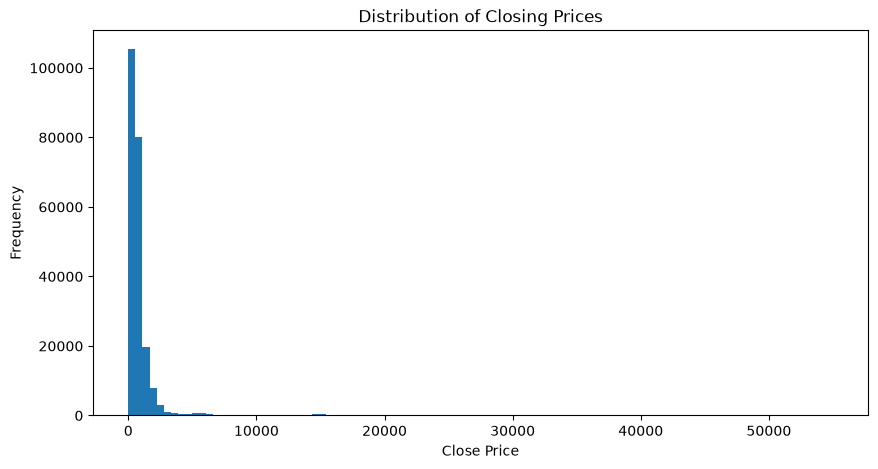

In [252]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(ordinary["Close"], bins=100)
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.title("Distribution of Closing Prices")
plt.show()

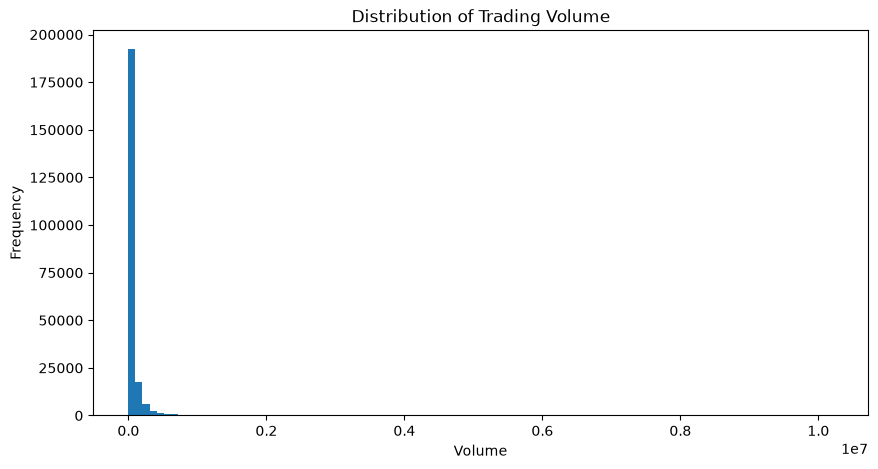

In [253]:
plt.figure(figsize=(10, 5))
plt.hist(ordinary["Vol"], bins=100)
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.title("Distribution of Trading Volume")
plt.show()

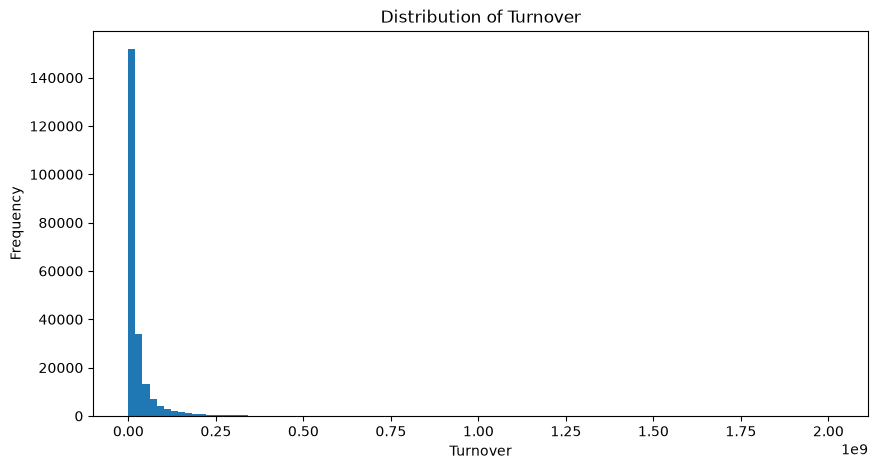

In [254]:
plt.figure(figsize=(10, 5))
plt.hist(ordinary["Turnover"], bins=100)
plt.xlabel("Turnover")
plt.ylabel("Frequency")
plt.title("Distribution of Turnover")
plt.show()

In [255]:
price_cols = [
    "Open", "High", "Low", "Close",
    "VWAP", "Vol", "Prev. Close", "Turnover"
]

ordinary[price_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Open,223475.0,1.067248e+03,3.184368e+03,7.40,389.000,582.10,8.880000e+02,5.508000e+04
High,223475.0,1.085754e+03,3.208400e+03,7.50,396.100,595.00,9.047000e+02,5.680580e+04
Low,223475.0,1.050916e+03,3.155802e+03,0.00,382.000,573.00,8.720000e+02,5.340000e+04
Close,223475.0,1.067486e+03,3.179672e+03,7.50,388.500,582.80,8.880000e+02,5.500000e+04
VWAP,223475.0,1.065901e+03,3.178477e+03,7.49,388.515,582.22,8.862250e+02,5.471585e+04
Vol,223475.0,5.861282e+04,1.398510e+05,1.00,6105.000,19519.00,5.553950e+04,1.021144e+07
Prev. Close,223475.0,1.067161e+03,3.178761e+03,0.00,388.000,582.44,8.879000e+02,5.500000e+04
Turnover,223475.0,2.839604e+07,5.976425e+07,242.00,4224612.250,10739219.20,2.682789e+07,2.012993e+09


In [256]:
# ── FIX 1: Drop symbols with too little history ────────────────────
min_days = 30  # adjust threshold as needed

company_dates = ordinary.groupby("Symbol")["Date"].agg(["min", "max", "count"])
valid_symbols = company_dates[company_dates["count"] >= min_days].index

dropped_symbols = set(ordinary["Symbol"].unique()) - set(valid_symbols)
print(f"Dropping {len(dropped_symbols)} symbols with < {min_days} days of history:")
print(sorted(dropped_symbols))

ordinary = ordinary[ordinary["Symbol"].isin(valid_symbols)].copy()

print("\nNew shape:", ordinary.shape)
print("Remaining symbols:", ordinary["Symbol"].nunique())

Dropping 6 symbols with < 30 days of history:
['BPW', 'MEPDL', 'MMFDB', 'NLBBL', 'RSY2', 'SAPIL']

New shape: (223417, 21)
Remaining symbols: 290


In [257]:
# ── FIX 2: Log-transform Vol/Turnover, then redo IQR outlier check ─
import numpy as np

ordinary["log_Vol"] = np.log1p(ordinary["Vol"])
ordinary["log_Turnover"] = np.log1p(ordinary["Turnover"])

def bounds_transform(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    return (s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)

for col in ["log_Vol", "log_Turnover"]:
    is_outlier = ordinary.groupby("Symbol")[col].transform(bounds_transform)
    ordinary[f"{col}_outlier"] = is_outlier
    print(col, "outliers:", is_outlier.sum())

log_Vol outliers: 3518
log_Turnover outliers: 3520


In [258]:
# ── FIX 3: Final sanity check after both changes ───────────────────
print("Final shape:", ordinary.shape)
print("Duplicates:", ordinary.duplicated().sum())
print("Nulls:\n", ordinary.isnull().sum()[ordinary.isnull().sum() > 0])
print("\nDate range:", ordinary["Date"].min(), "to", ordinary["Date"].max())
print("Symbols:", ordinary["Symbol"].nunique())

Final shape: (223417, 25)
Duplicates: 0
Nulls:
 Series([], dtype: int64)

Date range: 2024-03-04 00:00:00 to 2026-08-27 00:00:00
Symbols: 290


In [259]:
ordinary = ordinary[
    (ordinary["Low"] != 0) &
    (ordinary["Prev. Close"] != 0)
].copy()

In [260]:
print("Low = 0:", (ordinary["Low"] == 0).sum())
print("Prev. Close = 0:", (ordinary["Prev. Close"] == 0).sum())
print("New shape:", ordinary.shape)

Low = 0: 0
Prev. Close = 0: 0
New shape: (223413, 25)


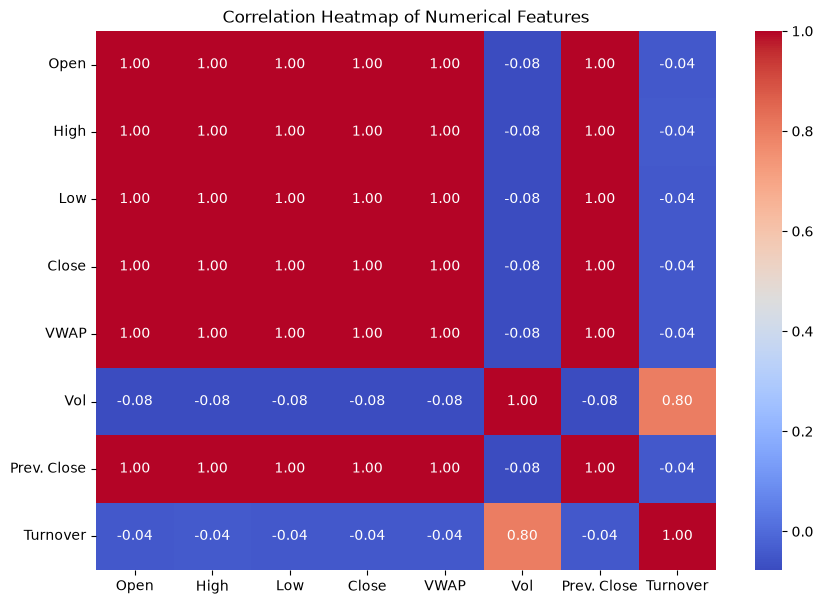

In [261]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = [
    "Open", "High", "Low", "Close",
    "VWAP", "Vol", "Prev. Close", "Turnover"
]

corr = ordinary[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [262]:
print("Start Date:", ordinary["Date"].min())
print("End Date:", ordinary["Date"].max())
print("Number of unique dates:", ordinary["Date"].nunique())

Start Date: 2024-03-04 00:00:00
End Date: 2026-08-27 00:00:00
Number of unique dates: 889


In [263]:
date_counts = ordinary.groupby("Date").size()

print(date_counts.describe())

count    889.000000
mean     251.308211
std       12.067451
min      224.000000
25%      242.000000
50%      246.000000
75%      260.000000
max      280.000000
dtype: float64


In [264]:
print("Dates with fewest records:")
print(date_counts.sort_values().head(10))

print("\nDates with most records:")
print(date_counts.sort_values(ascending=False).head(10))

Dates with fewest records:
Date
2025-09-20    224
2025-09-18    224
2025-09-19    224
2024-03-04    225
2024-08-01    239
2024-08-02    239
2024-03-11    239
2024-07-16    239
2024-08-03    239
2024-08-04    239
dtype: int64

Dates with most records:
Date
2026-07-06    280
2026-07-09    280
2026-08-04    280
2026-08-18    280
2026-07-08    279
2026-07-28    279
2026-07-07    279
2026-07-03    279
2026-08-10    279
2026-08-05    279
dtype: int64


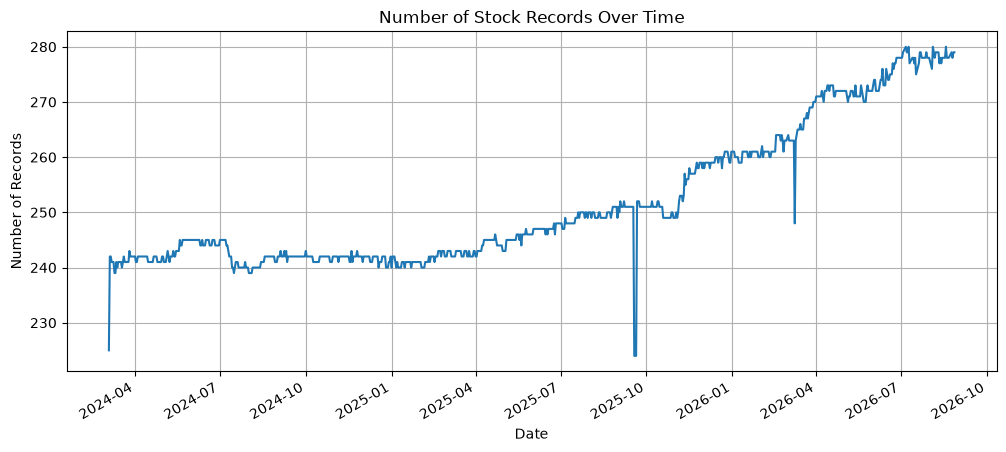

In [265]:
plt.figure(figsize=(12, 5))

date_counts.plot()

plt.xlabel("Date")
plt.ylabel("Number of Records")
plt.title("Number of Stock Records Over Time")
plt.grid()
plt.show()

In [266]:
company_dates = ordinary.groupby("Symbol")["Date"].agg(
    ["min", "max", "count"]
)

print(company_dates.head(10))

              min        max  count
Symbol                             
ACLBSL 2024-03-05 2026-08-27    887
ADBL   2024-03-04 2026-08-27    889
AHL    2024-03-04 2026-08-27    889
AHPC   2024-03-04 2026-08-27    889
AKJCL  2024-03-04 2026-08-27    889
AKPL   2024-03-04 2026-08-27    889
ALBSL  2024-03-04 2026-08-27    886
ALICL  2024-03-04 2026-08-27    889
ANLB   2024-03-04 2026-08-27    886
APHL   2026-06-10 2026-08-27     63


In [267]:
print("Companies:", len(company_dates))

print("\nCompanies with fewest observations:")
print(company_dates.sort_values("count").head(10))

print("\nCompanies with most observations:")
print(company_dates.sort_values("count", ascending=False).head(10))

Companies: 290

Companies with fewest observations:
              min        max  count
Symbol                             
ECL    2026-07-20 2026-08-27     29
SGHL   2026-07-02 2026-08-27     41
NLO    2024-03-26 2026-08-18     41
KAHL   2026-07-02 2026-08-27     41
SNORL  2026-06-26 2026-08-27     47
TPKHL  2026-06-22 2026-08-27     51
YMHL   2026-06-22 2026-08-27     51
APHL   2026-06-10 2026-08-27     63
SOPL   2026-06-08 2026-08-27     65
KHPL   2026-05-26 2026-08-27     78

Companies with most observations:
              min        max  count
Symbol                             
TPC    2024-03-04 2026-08-27    889
TAMOR  2024-03-04 2026-08-27    889
SWBBL  2024-03-04 2026-08-27    889
STC    2024-03-04 2026-08-27    889
SSHL   2024-03-04 2026-08-27    889
SRLI   2024-03-04 2026-08-27    889
SPL    2024-03-04 2026-08-27    889
SPIL   2024-03-04 2026-08-27    889
SPHL   2024-03-04 2026-08-27    889
CHCL   2024-03-04 2026-08-27    889


In [268]:
print("Symbols in ordinary:", ordinary["Symbol"].nunique())

print("Rows:", len(ordinary))
print("Columns:", len(ordinary.columns))

Symbols in ordinary: 290
Rows: 223413
Columns: 25


In [269]:
# Symbols that were in the original Ordinary Share data
original_symbols = set(
    df_model[df_model["Instrument_Type"] == "Ordinary Share"]["Symbol"].unique()
)

# Symbols currently in ordinary
current_symbols = set(ordinary["Symbol"].unique())

print("Original symbols:", len(original_symbols))
print("Current symbols:", len(current_symbols))

print("\nSymbols missing from current ordinary:")
print(sorted(original_symbols - current_symbols))

Original symbols: 296
Current symbols: 290

Symbols missing from current ordinary:
['BPW', 'MEPDL', 'MMFDB', 'NLBBL', 'RSY2', 'SAPIL']


In [270]:
missing_symbols = ['BPW', 'MEPDL', 'MMFDB', 'NLBBL', 'RSY2', 'SAPIL']

df_model[df_model["Symbol"].isin(missing_symbols)][
    ["Symbol", "Date", "Sector", "Instrument_Type"]
].groupby(["Symbol", "Sector", "Instrument_Type"]).size()

Symbol  Sector              Instrument_Type
BPW     Hydro Power         Ordinary Share      3
MEPDL   Hydro Power         Ordinary Share     12
MMFDB   Development Banks   Ordinary Share      9
NLBBL   Microfinance        Ordinary Share      9
RSY2    Others              Ordinary Share     14
SAPIL   Non Life Insurance  Ordinary Share     11
dtype: int64

In [271]:
df_model[df_model["Symbol"].isin(missing_symbols)]["Instrument_Type"].value_counts()

Instrument_Type
Ordinary Share    58
Name: count, dtype: int64

In [272]:
df_model[df_model["Symbol"].isin(missing_symbols)][
    ["Symbol", "Date", "Sector", "Instrument_Type"]
].sort_values(["Symbol", "Date"])

,Symbol,Date,Sector,Instrument_Type
22,BPW,2024-03-04,Hydro Power,Ordinary Share
263,BPW,2024-03-05,Hydro Power,Ordinary Share
579,BPW,2024-03-06,Hydro Power,Ordinary Share
282994,MEPDL,2026-08-12,Hydro Power,Ordinary Share
283344,MEPDL,2026-08-13,Hydro Power,Ordinary Share
283685,MEPDL,2026-08-14,Hydro Power,Ordinary Share
284035,MEPDL,2026-08-17,Hydro Power,Ordinary Share
284379,MEPDL,2026-08-18,Hydro Power,Ordinary Share
284729,MEPDL,2026-08-19,Hydro Power,Ordinary Share
285074,MEPDL,2026-08-20,Hydro Power,Ordinary Share


In [273]:
df_model[df_model["Symbol"].isin(missing_symbols)]["Symbol"].value_counts()

Symbol
RSY2     14
MEPDL    12
SAPIL    11
MMFDB     9
NLBBL     9
BPW       3
Name: count, dtype: int64

In [274]:
print("df_model symbols:", df_model["Symbol"].nunique())
print("ordinary symbols:", ordinary["Symbol"].nunique())

print("\nMissing from ordinary:")
print(
    sorted(
        set(df_model["Symbol"].unique()) -
        set(ordinary["Symbol"].unique())
    )
)

df_model symbols: 521
ordinary symbols: 290

Missing from ordinary:
['ACLBSLP', 'ADBLB', 'ADBLB86', 'ADBLB87', 'ADBLD83', 'ALBSLP', 'ALICLP', 'BFCPO', 'BOKD86', 'BOKD86KA', 'BPW', 'C30MF', 'CBBLPO', 'CBLD88', 'CCBD88', 'CIZBD86', 'CIZBD90', 'CMF1', 'CMF2', 'CORBLP', 'CYCLP', 'CZBILP', 'EBLD85', 'EBLD86', 'EBLD91', 'EBLEB89', 'EDBLPO', 'FMDBLP', 'FOWADP', 'GBBD85', 'GBBLPO', 'GBD80/81', 'GBILD84/85', 'GBILD86/87', 'GBIMEP', 'GBIMESY2', 'GIBF1', 'GILBPO', 'GMFBS', 'GMFILP', 'GRDBLP', 'GUFLPO', 'GWFD83', 'H8020', 'HBLD83', 'HBLD86', 'HBLPO', 'HEIP', 'HIDCLP', 'HLIPO', 'ICFCD83', 'ICFCD88', 'ICFCD89', 'ICFCPO', 'IGIPO', 'ILBSP', 'JBBD87', 'JBBLPO', 'JBLBP', 'JFLPO', 'JSLBBP', 'KBLD86', 'KBLD89', 'KBLD90', 'KBLPO', 'KDBY', 'KEF', 'KLBSLP', 'KMCDBP', 'KSBBLD87', 'KSBBLP', 'LBBLD89', 'LBBLPO', 'LBLD86', 'LBLD88', 'LEMF', 'LSH12', 'LSLPO', 'LUK', 'LVF2', 'MATRIP', 'MBLD2085', 'MBLD87', 'MBLEF', 'MBLPO', 'MDBPO', 'MEPDL', 'MFILPO', 'MFLD85', 'MLBBLP', 'MLBLD89', 'MLBLPO', 'MLBSLP', 'MLBSP', 'MM

In [275]:
ordinary["Instrument_Type"].value_counts()

Instrument_Type
Ordinary Share    223413
Name: count, dtype: int64

In [276]:
ordinary[ordinary["Symbol"].isin(missing_symbols)][
    ["Symbol", "Date", "Sector", "Instrument_Type"]
]

,Symbol,Date,Sector,Instrument_Type


In [277]:
ordinary[ordinary["Symbol"].isin(missing_symbols)]["Symbol"].value_counts()

Series([], Name: count, dtype: int64)

In [278]:
df_model[df_model["Symbol"].isin(missing_symbols)][
    ["Symbol", "Instrument_Type", "Sector"]
].drop_duplicates()

,Symbol,Instrument_Type,Sector
22,BPW,Ordinary Share,Hydro Power
119,MMFDB,Ordinary Share,Development Banks
141,NLBBL,Ordinary Share,Microfinance
282413,RSY2,Ordinary Share,Others
282994,MEPDL,Ordinary Share,Hydro Power
283460,SAPIL,Ordinary Share,Non Life Insurance


In [279]:
print("Remaining companies:", ordinary["Symbol"].nunique())

print("\nCompanies per sector:")
print(ordinary.groupby("Sector")["Symbol"].nunique().sort_values())

Remaining companies: 290

Companies per sector:
Sector
Investment                        1
Trading                           3
Others                            9
Hotels And Tourism               10
Non Life Insurance               13
Life Insurance                   14
Finance                          17
Commercial Banks                 24
Development Banks                24
Manufacturing And Processing     24
Microfinance                     41
Hydro Power                     110
Name: Symbol, dtype: int64


In [280]:
ordinary_model = ordinary.copy()

In [281]:
print("Shape:", ordinary_model.shape)
print("Companies:", ordinary_model["Symbol"].nunique())
print("Sectors:", ordinary_model["Sector"].nunique())

print("\nCompanies per sector:")
print(ordinary_model.groupby("Sector")["Symbol"].nunique().sort_values())

Shape: (223413, 25)
Companies: 290


Sectors: 12

Companies per sector:
Sector
Investment                        1
Trading                           3
Others                            9
Hotels And Tourism               10
Non Life Insurance               13
Life Insurance                   14
Finance                          17
Commercial Banks                 24
Development Banks                24
Manufacturing And Processing     24
Microfinance                     41
Hydro Power                     110
Name: Symbol, dtype: int64


In [438]:
company_sectors = (
    df_model[["Symbol", "Sector"]]
    .drop_duplicates()
    .sort_values("Symbol")
    .reset_index(drop=True)
)

print(company_sectors.shape)
print(company_sectors.head())

(521, 2)
    Symbol            Sector
0   ACLBSL      Microfinance
1  ACLBSLP      Microfinance
2     ADBL  Commercial Banks
3    ADBLB  Commercial Banks
4  ADBLB86  Commercial Banks


In [ ]:
company_sectors.to_csv(
    "company_sectors.csv",
    index=False
)

In [532]:
print(company_sectors.shape)
print(company_sectors["Symbol"].nunique())
print(company_sectors["Sector"].nunique())

(521, 2)
521
13


In [ ]:
print(ordinary_model.columns.tolist())

['S.No', 'Symbol', 'Open', 'High', 'Low', 'Close', 'VWAP', 'Vol', 'Prev. Close', 'Turnover', 'Trans.', 'Diff', 'Range', 'Diff %', 'Range %', 'VWAP %', '52 Weeks High', '52 Weeks Low', 'Date', 'Sector', 'Instrument_Type', 'log_Vol', 'log_Turnover', 'log_Vol_outlier', 'log_Turnover_outlier', 'Target', 'Price_Change', 'Daily_Return', 'MA_5', 'MA_10', 'MA_20', 'Return_3D', 'Return_5D', 'Volatility_5D', 'Volume_Change', 'MA5_Distance', 'Market_Return_x', 'Relative_to_Market', 'Sector_Return', 'Relative_to_Sector', 'Market_Rank', 'Sector_Rank', 'Market_Return_y']


In [ ]:
ordinary_model["Date"] = pd.to_datetime(ordinary_model["Date"])

ordinary_model = ordinary_model.sort_values(
    ["Symbol", "Date"]
).reset_index(drop=True)

print(ordinary_model[["Symbol", "Date", "Close"]].head(10))

   Symbol       Date  Close
0  ACLBSL 2024-05-02  837.0
1  ACLBSL 2024-05-03  837.0
2  ACLBSL 2024-05-04  837.0
3  ACLBSL 2024-05-05  820.0
4  ACLBSL 2024-05-06  813.5
5  ACLBSL 2024-05-07  867.0
6  ACLBSL 2024-05-08  902.7
7  ACLBSL 2024-05-09  916.6
8  ACLBSL 2024-05-10  916.6
9  ACLBSL 2024-05-11  916.6


In [ ]:
next_close = ordinary_model.groupby("Symbol")["Close"].shift(-1)

In [ ]:
ordinary_model["Target"] = np.where(
    next_close.isna(),
    np.nan,
    (next_close > ordinary_model["Close"]).astype(int)
)

In [ ]:
print(ordinary_model[[
    "Symbol", "Date", "Close", "Target"
]].head(10))

   Symbol       Date  Close  Target
0  ACLBSL 2024-05-02  837.0     0.0
1  ACLBSL 2024-05-03  837.0     0.0
2  ACLBSL 2024-05-04  837.0     0.0
3  ACLBSL 2024-05-05  820.0     0.0
4  ACLBSL 2024-05-06  813.5     1.0
5  ACLBSL 2024-05-07  867.0     1.0
6  ACLBSL 2024-05-08  902.7     1.0
7  ACLBSL 2024-05-09  916.6     0.0
8  ACLBSL 2024-05-10  916.6     0.0
9  ACLBSL 2024-05-11  916.6     0.0


In [ ]:
print(ordinary_model["Target"].value_counts(dropna=False))

Target
0.0    147684
1.0     58165
NaN       283
Name: count, dtype: int64


In [ ]:
ordinary_model = ordinary_model.dropna(subset=["Target"]).copy()

ordinary_model["Target"] = ordinary_model["Target"].astype(int)

print("New shape:", ordinary_model.shape)
print(ordinary_model["Target"].value_counts())

New shape: (205849, 43)
Target
0    147684
1     58165
Name: count, dtype: int64


In [ ]:
## Feature engineering
# Price Change
ordinary_model["Price_Change"] = (
    ordinary_model["Close"] - ordinary_model["Prev. Close"]
)

# Daily Return
ordinary_model["Daily_Return"] = (
    (ordinary_model["Close"] - ordinary_model["Prev. Close"])
    / ordinary_model["Prev. Close"]
)

# Moving Average - 5 days
ordinary_model["MA_5"] = (
    ordinary_model.groupby("Symbol")["Close"]
    .transform(lambda x: x.rolling(5).mean())
)

# Moving Average - 10 days
ordinary_model["MA_10"] = (
    ordinary_model.groupby("Symbol")["Close"]
    .transform(lambda x: x.rolling(10).mean())
)

# Moving Average - 20 days
ordinary_model["MA_20"] = (
    ordinary_model.groupby("Symbol")["Close"]
    .transform(lambda x: x.rolling(20).mean())
)

In [ ]:
print(ordinary_model.shape)

print(ordinary_model[
    ["Symbol", "Date", "Close", "Vol",
     "Price_Change", "Daily_Return",
     "MA_5", "MA_10", "MA_20", "Target"]
].head(25))

(205849, 43)
    Symbol       Date  Close      Vol  Price_Change  Daily_Return    MA_5  \
0   ACLBSL 2024-05-02  837.0  13546.0          37.0      0.046250     NaN   
1   ACLBSL 2024-05-03  837.0  13546.0          37.0      0.046250     NaN   
2   ACLBSL 2024-05-04  837.0  13546.0          37.0      0.046250     NaN   
3   ACLBSL 2024-05-05  820.0  26761.0         -17.0     -0.020311     NaN   
4   ACLBSL 2024-05-06  813.5  10816.0          -6.5     -0.007927  828.90   
5   ACLBSL 2024-05-07  867.0  12850.0          53.5      0.065765  834.90   
6   ACLBSL 2024-05-08  902.7  21090.0          35.7      0.041176  848.04   
7   ACLBSL 2024-05-09  916.6  14299.0          13.9      0.015398  863.96   
8   ACLBSL 2024-05-10  916.6  14299.0          13.9      0.015398  883.28   
9   ACLBSL 2024-05-11  916.6  14299.0          13.9      0.015398  903.90   
10  ACLBSL 2024-05-12  896.0  21320.0         -20.6     -0.022474  909.70   
11  ACLBSL 2024-05-13  866.0  47974.0         -30.0     -0.0334

In [ ]:
print(ordinary_model[
    ["Price_Change", "Daily_Return", "MA_5", "MA_10", "MA_20"]
].isna().sum())

Price_Change       0
Daily_Return       0
MA_5            1130
MA_10           2535
MA_20           5343
dtype: int64


In [ ]:
ordinary_model = ordinary_model.dropna(
    subset=["MA_5", "MA_10", "MA_20"]
).copy()

In [ ]:
print("New shape:", ordinary_model.shape)

print(
    ordinary_model[
        ["Price_Change", "Daily_Return", "MA_5", "MA_10", "MA_20"]
    ].isna().sum()
)

New shape: (200506, 43)
Price_Change    0
Daily_Return    0
MA_5            0
MA_10           0
MA_20           0
dtype: int64


In [ ]:
print(ordinary_model.columns.tolist())

['S.No', 'Symbol', 'Open', 'High', 'Low', 'Close', 'VWAP', 'Vol', 'Prev. Close', 'Turnover', 'Trans.', 'Diff', 'Range', 'Diff %', 'Range %', 'VWAP %', '52 Weeks High', '52 Weeks Low', 'Date', 'Sector', 'Instrument_Type', 'log_Vol', 'log_Turnover', 'log_Vol_outlier', 'log_Turnover_outlier', 'Target', 'Price_Change', 'Daily_Return', 'MA_5', 'MA_10', 'MA_20', 'Return_3D', 'Return_5D', 'Volatility_5D', 'Volume_Change', 'MA5_Distance', 'Market_Return_x', 'Relative_to_Market', 'Sector_Return', 'Relative_to_Sector', 'Market_Rank', 'Sector_Rank', 'Market_Return_y']


In [ ]:
print(ordinary_model[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "VWAP",
        "Vol",
        "Prev. Close",
        "Turnover",
        "Trans.",
        "Diff",
        "Range",
        "Diff %",
        "Range %",
        "VWAP %",
        "52 Weeks High",
        "52 Weeks Low",
        "Price_Change",
        "Daily_Return"
    ]
].head())

     Open   High    Low  Close    VWAP      Vol  Prev. Close    Turnover  \
19  886.9  960.0  886.9  946.0  939.29  25058.0        905.0  23536679.8   
20  959.9  960.0  930.0  930.0  947.08   8162.0        946.0   7730076.5   
21  959.9  960.0  930.0  930.0  947.08   8162.0        946.0   7730076.5   
22  959.9  960.0  930.0  930.0  947.08   8162.0        946.0   7730076.5   
23  959.9  960.0  930.0  930.0  947.08   8162.0        946.0   7730076.5   

    Trans.  Diff  Range  Diff %  Range %  VWAP %  52 Weeks High  52 Weeks Low  \
19     259  41.0   73.1    4.53     8.24    0.71          963.9         500.1   
20     163 -16.0   30.0   -1.69     3.23   -1.84          963.9         500.1   
21     163 -16.0   30.0   -1.69     3.23   -1.84          963.9         500.1   
22     163 -16.0   30.0   -1.69     3.23   -1.84          963.9         500.1   
23     163 -16.0   30.0   -1.69     3.23   -1.84          963.9         500.1   

    Price_Change  Daily_Return  
19          41.0      0

In [ ]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "VWAP",
    "Vol",
    "Prev. Close",
    "Turnover",
    "Trans.",
    "Diff",
    "Range",
    "Diff %",
    "Range %",
    "VWAP %",
    "52 Weeks High",
    "52 Weeks Low",
    "Daily_Return",
    "MA_5",
    "MA_10",
    "MA_20"
]

correlation = (
    ordinary_model[features + ["Target"]]
    .corr()["Target"]
    .drop("Target")
    .sort_values(ascending=False)
)

print(correlation)

Daily_Return     0.000350
Diff %           0.000281
52 Weeks Low     0.000041
MA_20           -0.000968
MA_10           -0.001022
Vol             -0.001056
MA_5            -0.001092
VWAP            -0.001124
Low             -0.001203
Prev. Close     -0.001205
Open            -0.001242
High            -0.001243
Close           -0.001378
Turnover        -0.001406
52 Weeks High   -0.001409
Range %         -0.001601
Range           -0.002308
Trans.          -0.004843
Diff            -0.009038
VWAP %          -0.031940
Name: Target, dtype: float64


In [ ]:
features_selected = [
    "Open",
    "High",
    "Low",
    "Close",
    "VWAP",
    "Vol",
    "Turnover",
    "Trans.",
    "Diff",
    "Range",
    "Diff %",
    "Range %",
    "VWAP %",
    "MA_5"
]

In [ ]:
X = ordinary_model[features_selected]
y = ordinary_model["Target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nSelected features:")
print(X.columns.tolist())

X shape: (200506, 14)
y shape: (200506,)

Selected features:
['Open', 'High', 'Low', 'Close', 'VWAP', 'Vol', 'Turnover', 'Trans.', 'Diff', 'Range', 'Diff %', 'Range %', 'VWAP %', 'MA_5']


In [ ]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nTotal missing values:", X.isnull().sum().sum())

Missing values in X:
Open        0
High        0
Low         0
Close       0
VWAP        0
Vol         0
Turnover    0
Trans.      0
Diff        0
Range       0
Diff %      0
Range %     0
VWAP %      0
MA_5        0
dtype: int64

Total missing values: 0


In [ ]:
print(y.value_counts())
print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

Target
0    144044
1     56462
Name: count, dtype: int64

Target percentage:
Target
0    71.840244
1    28.159756
Name: proportion, dtype: float64


## Experimentation/validation.

## Why did you use a chronological (date-based) split for your train/validation/test data instead of a random shuffle split?

"Because this is time-series data, a random split could let the model train on future dates and test on past ones — that's data leakage. A chronological split ensures the model only trains on the past and is tested on truly unseen future dates, just like it would face in real deployment."

In [ ]:
# Get unique dates in chronological order
unique_dates = sorted(ordinary_model["Date"].unique())

# 60% dates for training
train_end = int(0.6 * len(unique_dates))

# 20% dates for validation
val_end = int(0.8 * len(unique_dates))

train_dates = unique_dates[:train_end]
val_dates = unique_dates[train_end:val_end]
test_dates = unique_dates[val_end:]

# Create datasets based on dates
train_data = ordinary_model[
    ordinary_model["Date"].isin(train_dates)
]

val_data = ordinary_model[
    ordinary_model["Date"].isin(val_dates)
]

test_data = ordinary_model[
    ordinary_model["Date"].isin(test_dates)
]

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

print("\nTrain dates:", train_data["Date"].min(), "→", train_data["Date"].max())
print("Validation dates:", val_data["Date"].min(), "→", val_data["Date"].max())
print("Test dates:", test_data["Date"].min(), "→", test_data["Date"].max())

Train: (117111, 43)
Validation: (40582, 43)
Test: (42813, 43)

Train dates: 2024-05-20 00:00:00 → 2025-09-17 00:00:00
Validation dates: 2025-09-18 00:00:00 → 2026-02-26 00:00:00
Test dates: 2026-02-27 00:00:00 → 2026-08-24 00:00:00


In [ ]:
print("Train:")
print(train_data.shape)
print(train_data["Date"].min(), "→", train_data["Date"].max())

print("\nValidation:")
print(val_data.shape)
print(val_data["Date"].min(), "→", val_data["Date"].max())

print("\nTest:")
print(test_data.shape)
print(test_data["Date"].min(), "→", test_data["Date"].max())

Train:
(117111, 43)
2024-05-20 00:00:00 → 2025-09-17 00:00:00

Validation:
(40582, 43)
2025-09-18 00:00:00 → 2026-02-26 00:00:00

Test:
(42813, 43)
2026-02-27 00:00:00 → 2026-08-24 00:00:00


In [ ]:
print(
    "Train/Validation overlap:",
    set(train_data["Date"]) & set(val_data["Date"])
)

print(
    "Validation/Test overlap:",
    set(val_data["Date"]) & set(test_data["Date"])
)

Train/Validation overlap: set()
Validation/Test overlap: set()


In [ ]:
features_selected = [
    "Open",
    "High",
    "Low",
    "Close",
    "VWAP",
    "Vol",
    "Turnover",
    "Trans.",
    "Diff",
    "Range",
    "Diff %",
    "Range %",
    "VWAP %",
    "MA_5"
]

X_train = train_data[features_selected]
y_train = train_data["Target"]

X_val = val_data[features_selected]
y_val = val_data["Target"]

X_test = test_data[features_selected]
y_test = test_data["Target"]

In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (117111, 14)
y_train: (117111,)
X_val: (40582, 14)
y_val: (40582,)
X_test: (42813, 14)
y_test: (42813,)


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(X_train)

StandardScaler()

In [ ]:
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (117111, 14)
X_val_scaled: (40582, 14)
X_test_scaled: (42813, 14)


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000
)

In [ ]:
logistic_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [ ]:
y_val_pred = logistic_model.predict(X_val_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.7391700754028879


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85     30000
           1       0.00      0.00      0.00     10582

    accuracy                           0.74     40582
   macro avg       0.37      0.50      0.43     40582
weighted avg       0.55      0.74      0.63     40582



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

print(cm)

[[29997     3]
 [10582     0]]


In [ ]:
y_val_prob = logistic_model.predict_proba(X_val_scaled)[:, 1]

print(y_val_prob[:20])

[0.25533167 0.25532846 0.25532525 0.30016709 0.30016804 0.30649677
 0.26486342 0.27970255 0.27970218 0.2797018  0.29599953 0.29600051
 0.29600209 0.29600367 0.29600525 0.29600525 0.29600525 0.29600525
 0.29600525 0.25815844]


In [ ]:
print("Minimum probability:", y_val_prob.min())
print("Maximum probability:", y_val_prob.max())
print("Mean probability:", y_val_prob.mean())

Minimum probability: 0.15675916155474492
Maximum probability: 0.6229863611229319
Mean probability: 0.28063156691998586


In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_val, y_val_prob)

print("Validation ROC-AUC:", roc_auc)

Validation ROC-AUC: 0.5037258473508474


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [ ]:
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [ ]:
y_val_pred_dt = dt_model.predict(X_val)

In [ ]:
print(y_val_pred_dt[:20])

[1 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_val, y_val_pred_dt)

print("Decision Tree Validation Accuracy:", dt_accuracy)

Decision Tree Validation Accuracy: 0.5441328667882313


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred_dt))

              precision    recall  f1-score   support

           0       0.74      0.59      0.66     30000
           1       0.26      0.42      0.32     10582

    accuracy                           0.54     40582
   macro avg       0.50      0.50      0.49     40582
weighted avg       0.62      0.54      0.57     40582



In [ ]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_val, y_val_pred_dt)

print(cm_dt)

[[17659 12341]
 [ 6159  4423]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [ ]:
y_val_pred_rf = rf_model.predict(X_val)

print(y_val_pred_rf[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_val, y_val_pred_rf)

print("Random Forest Validation Accuracy:", rf_accuracy)

Random Forest Validation Accuracy: 0.6797348578187373


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred_rf))

              precision    recall  f1-score   support

           0       0.74      0.86      0.80     30000
           1       0.29      0.16      0.20     10582

    accuracy                           0.68     40582
   macro avg       0.52      0.51      0.50     40582
weighted avg       0.63      0.68      0.64     40582



In [ ]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_val, y_val_pred_rf)

print(cm_rf)

[[25936  4064]
 [ 8933  1649]]


In [ ]:
from sklearn.metrics import roc_auc_score

y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]

rf_roc_auc = roc_auc_score(y_val, y_val_prob_rf)

print("Random Forest Validation ROC-AUC:", rf_roc_auc)

Random Forest Validation ROC-AUC: 0.514306822906823


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": features_selected,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

     Feature  Importance
13      MA_5    0.187518
12    VWAP %    0.074569
7     Trans.    0.071047
6   Turnover    0.070078
5        Vol    0.068822
11   Range %    0.067760
10    Diff %    0.067402
8       Diff    0.065211
9      Range    0.060780
0       Open    0.055213
4       VWAP    0.054507
3      Close    0.053240
2        Low    0.051990
1       High    0.051863


In [ ]:
## hyperparameters ==adjusting the model's settings (hyperparameters) to try to get better performance on your validation data.
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_balanced.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [ ]:
y_val_pred_rf_balanced = rf_balanced.predict(X_val)

print(y_val_pred_rf_balanced[:20])

[0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1]


In [ ]:
from sklearn.metrics import accuracy_score

rf_balanced_accuracy = accuracy_score(
    y_val,
    y_val_pred_rf_balanced
)

print("Balanced Random Forest Validation Accuracy:", rf_balanced_accuracy)

Balanced Random Forest Validation Accuracy: 0.563402493716426


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred_rf_balanced))

              precision    recall  f1-score   support

           0       0.75      0.62      0.68     30000
           1       0.27      0.41      0.33     10582

    accuracy                           0.56     40582
   macro avg       0.51      0.51      0.50     40582
weighted avg       0.62      0.56      0.59     40582



In [ ]:
y_val_prob_rf_balanced = rf_balanced.predict_proba(X_val)[:, 1]

rf_balanced_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_rf_balanced
)

print("Balanced Random Forest Validation ROC-AUC:",
      rf_balanced_roc_auc)

Balanced Random Forest Validation ROC-AUC: 0.5194040241290242


In [ ]:
## test 200 trees
rf_200 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_200.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [ ]:
y_val_pred_rf_200 = rf_200.predict(X_val)

In [ ]:
rf_200_accuracy = accuracy_score(y_val, y_val_pred_rf_200)

print("Random Forest (200 trees) Validation Accuracy:",
      rf_200_accuracy)

Random Forest (200 trees) Validation Accuracy: 0.6801784042186191


In [ ]:
print(classification_report(y_val, y_val_pred_rf_200))

              precision    recall  f1-score   support

           0       0.74      0.87      0.80     30000
           1       0.28      0.15      0.19     10582

    accuracy                           0.68     40582
   macro avg       0.51      0.51      0.50     40582
weighted avg       0.62      0.68      0.64     40582



In [ ]:
rf_leaf = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_leaf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the tota

In [ ]:
y_val_pred_rf_leaf = rf_leaf.predict(X_val)

print("Prediction completed.")

Prediction completed.


In [ ]:
rf_leaf_accuracy = accuracy_score(y_val, y_val_pred_rf_leaf)

print("Random Forest (min_samples_leaf=10) Validation Accuracy:",
      rf_leaf_accuracy)

Random Forest (min_samples_leaf=10) Validation Accuracy: 0.727317529939382


In [ ]:
print(classification_report(y_val, y_val_pred_rf_leaf))

              precision    recall  f1-score   support

           0       0.74      0.97      0.84     30000
           1       0.29      0.03      0.06     10582

    accuracy                           0.73     40582
   macro avg       0.52      0.50      0.45     40582
weighted avg       0.62      0.73      0.64     40582



In [ ]:
y_val_prob_rf_leaf = rf_leaf.predict_proba(X_val)[:, 1]

rf_leaf_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_rf_leaf
)

print("Random Forest (min_samples_leaf=10) Validation ROC-AUC:",
      rf_leaf_roc_auc)

Random Forest (min_samples_leaf=10) Validation ROC-AUC: 0.5216456466956467


In [ ]:
y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]

print("Minimum probability:", y_val_prob_rf.min())
print("Maximum probability:", y_val_prob_rf.max())
print("Mean probability:", y_val_prob_rf.mean())

Minimum probability: 0.0
Maximum probability: 0.98
Mean probability: 0.3819569066952574


In [ ]:
y_val_pred_threshold = (y_val_prob_rf >= 0.40).astype(int)

print(classification_report(
    y_val,
    y_val_pred_threshold
))

              precision    recall  f1-score   support

           0       0.75      0.57      0.65     30000
           1       0.27      0.45      0.34     10582

    accuracy                           0.54     40582
   macro avg       0.51      0.51      0.49     40582
weighted avg       0.62      0.54      0.57     40582



In [ ]:
y_val_pred_threshold_45 = (y_val_prob_rf >= 0.45).astype(int)

print(classification_report(
    y_val,
    y_val_pred_threshold_45
))

              precision    recall  f1-score   support

           0       0.74      0.73      0.73     30000
           1       0.27      0.29      0.28     10582

    accuracy                           0.61     40582
   macro avg       0.51      0.51      0.51     40582
weighted avg       0.62      0.61      0.62     40582



In [608]:
## Again feature engineering
ordinary_model["Return_3D"] = (
    ordinary_model.groupby("Symbol")["Close"]
    .pct_change(periods=3)
)

ordinary_model["Return_5D"] = (
    ordinary_model.groupby("Symbol")["Close"]
    .pct_change(periods=5)
)

In [609]:
print(
    ordinary_model[
        ["Symbol", "Date", "Close", "Return_3D", "Return_5D"]
    ].head(10)
)

    Symbol       Date  Close  Return_3D  Return_5D
19  ACLBSL 2024-05-21  946.0        NaN        NaN
20  ACLBSL 2024-05-22  930.0        NaN        NaN
21  ACLBSL 2024-05-23  930.0        NaN        NaN
22  ACLBSL 2024-05-24  930.0  -0.016913        NaN
23  ACLBSL 2024-05-25  930.0   0.000000        NaN
24  ACLBSL 2024-05-26  915.5  -0.015591  -0.032241
25  ACLBSL 2024-05-27  936.0   0.006452   0.006452
26  ACLBSL 2024-05-28  936.0   0.006452   0.006452
27  ACLBSL 2024-05-29  926.0   0.011469  -0.004301
28  ACLBSL 2024-05-30  911.0  -0.026709  -0.020430


In [610]:
print("Return_3D missing:", ordinary_model["Return_3D"].isna().sum())
print("Return_5D missing:", ordinary_model["Return_5D"].isna().sum())

Return_3D missing: 840
Return_5D missing: 1400


In [611]:
ordinary_model = ordinary_model.dropna(
    subset=["Return_3D", "Return_5D"]
).copy()

print("New shape:", ordinary_model.shape)

New shape: (199106, 43)


In [612]:
ordinary_model["Price_to_MA5"] = (
    ordinary_model["Close"] / ordinary_model["MA_5"]
)

In [613]:
print(
    ordinary_model[
        ["Symbol", "Date", "Close", "MA_5", "Price_to_MA5"]
    ].head(10)
)

    Symbol       Date  Close   MA_5  Price_to_MA5
24  ACLBSL 2024-05-26  915.5  927.1      0.987488
25  ACLBSL 2024-05-27  936.0  928.3      1.008295
26  ACLBSL 2024-05-28  936.0  929.5      1.006993
27  ACLBSL 2024-05-29  926.0  928.7      0.997093
28  ACLBSL 2024-05-30  911.0  924.9      0.984971
29  ACLBSL 2024-05-31  911.0  924.0      0.985931
30  ACLBSL 2024-06-01  911.0  919.0      0.991295
31  ACLBSL 2024-06-02  917.0  915.2      1.001967
32  ACLBSL 2024-06-03  943.0  918.6      1.026562
33  ACLBSL 2024-06-04  960.0  928.4      1.034037


In [614]:
ordinary_model["Volatility_5D"] = (
    ordinary_model.groupby("Symbol")["Daily_Return"]
    .transform(lambda x: x.rolling(5).std())
)

In [615]:
print(
    ordinary_model[
        ["Symbol", "Date", "Daily_Return", "Volatility_5D"]
    ].head(15)
)

    Symbol       Date  Daily_Return  Volatility_5D
24  ACLBSL 2024-05-26     -0.015591            NaN
25  ACLBSL 2024-05-27      0.022392            NaN
26  ACLBSL 2024-05-28      0.022392            NaN
27  ACLBSL 2024-05-29     -0.010684            NaN
28  ACLBSL 2024-05-30     -0.016199       0.020133
29  ACLBSL 2024-05-31     -0.016199       0.020256
30  ACLBSL 2024-06-01     -0.016199       0.016812
31  ACLBSL 2024-06-02      0.006586       0.009866
32  ACLBSL 2024-06-03      0.028353       0.019982
33  ACLBSL 2024-06-04      0.018028       0.020078
34  ACLBSL 2024-06-05      0.031250       0.019274
35  ACLBSL 2024-06-06      0.020202       0.009699
36  ACLBSL 2024-06-07      0.020202       0.005815
37  ACLBSL 2024-06-08      0.020202       0.005269
38  ACLBSL 2024-06-09     -0.035644       0.026643


In [ ]:
ordinary_model = ordinary_model.dropna(
    subset=["Volatility_5D"]
).copy()

print("New shape:", ordinary_model.shape)

In [ ]:
ordinary_model["Volume_Change"] = (
    ordinary_model.groupby("Symbol")["Vol"]
    .pct_change()
)

In [ ]:
print(
    ordinary_model[
        ["Symbol", "Date", "Vol", "Volume_Change"]
    ].head(15)
)

    Symbol       Date      Vol  Volume_Change
28  ACLBSL 2024-05-01   8514.0            NaN
29  ACLBSL 2024-05-02  13546.0       0.591027
30  ACLBSL 2024-05-03  13546.0       0.000000
31  ACLBSL 2024-05-04  13546.0       0.000000
32  ACLBSL 2024-05-05  26761.0       0.975565
33  ACLBSL 2024-05-06  10816.0      -0.595830
34  ACLBSL 2024-05-07  12850.0       0.188055
35  ACLBSL 2024-05-08  21090.0       0.641245
36  ACLBSL 2024-05-09  14299.0      -0.322001
37  ACLBSL 2024-05-10  14299.0       0.000000
38  ACLBSL 2024-05-11  14299.0       0.000000
39  ACLBSL 2024-05-12  21320.0       0.491013
40  ACLBSL 2024-05-13  47974.0       1.250188
41  ACLBSL 2024-05-14  19823.0      -0.586797
42  ACLBSL 2024-05-15  26123.0       0.317813


In [ ]:
ordinary_model = ordinary_model.dropna(
    subset=["Volume_Change"]
).copy()

print("New shape:", ordinary_model.shape)


New shape: (206132, 43)


In [ ]:
ordinary_model["MA5_Distance"] = (
    (ordinary_model["Close"] - ordinary_model["MA_5"])
    / ordinary_model["MA_5"]
)

In [ ]:
print(
    ordinary_model[
        ["Symbol", "Date", "Close", "MA_5", "MA5_Distance"]
    ].head(10)
)

    Symbol       Date  Close    MA_5  MA5_Distance
29  ACLBSL 2024-05-02  837.0  795.64      0.051983
30  ACLBSL 2024-05-03  837.0  808.24      0.035583
31  ACLBSL 2024-05-04  837.0  822.20      0.018000
32  ACLBSL 2024-05-05  820.0  826.20     -0.007504
33  ACLBSL 2024-05-06  813.5  828.90     -0.018579
34  ACLBSL 2024-05-07  867.0  834.90      0.038448
35  ACLBSL 2024-05-08  902.7  848.04      0.064455
36  ACLBSL 2024-05-09  916.6  863.96      0.060929
37  ACLBSL 2024-05-10  916.6  883.28      0.037723
38  ACLBSL 2024-05-11  916.6  903.90      0.014050


In [ ]:
print("MA5_Distance missing:",
      ordinary_model["MA5_Distance"].isna().sum())

MA5_Distance missing: 0


In [ ]:
new_features = [
    "Return_3D",
    "Return_5D",
    "Price_to_MA5",
    "Volatility_5D",
    "Volume_Change",
    "MA5_Distance"
]

print(ordinary_model[new_features].isna().sum())

Return_3D        0
Return_5D        0
Price_to_MA5     0
Volatility_5D    0
Volume_Change    0
MA5_Distance     0
dtype: int64


In [ ]:
ordinary_model = ordinary_model.drop(
    columns=["Price_to_MA5"]
)

print(ordinary_model.shape)

(206132, 42)


In [ ]:
## Cross-sectional features (market-wide and sector-relative signals)

market_return = ordinary_model.groupby("Date")["Daily_Return"].mean().rename("Market_Return")
ordinary_model = ordinary_model.merge(market_return, on="Date", how="left")

ordinary_model["Relative_to_Market"] = ordinary_model["Daily_Return"] - ordinary_model["Market_Return"]

sector_return = ordinary_model.groupby(["Date", "Sector"])["Daily_Return"].mean().rename("Sector_Return")
ordinary_model = ordinary_model.merge(sector_return, on=["Date", "Sector"], how="left")

ordinary_model["Relative_to_Sector"] = ordinary_model["Daily_Return"] - ordinary_model["Sector_Return"]

ordinary_model["Market_Rank"] = ordinary_model.groupby("Date")["Daily_Return"].rank(pct=True)
ordinary_model["Sector_Rank"] = ordinary_model.groupby(["Date", "Sector"])["Daily_Return"].rank(pct=True)

print(ordinary_model[["Market_Return", "Relative_to_Market", "Sector_Return", "Relative_to_Sector", "Market_Rank", "Sector_Rank"]].isna().sum())

KeyError: 'Market_Return'

In [ ]:
features_selected = [
    # Original features
    "Open",
    "High",
    "Low",
    "Close",
    "VWAP",
    "Vol",
    "Turnover",
    "Trans.",
    "Diff",
    "Range",
    "Diff %",
    "Range %",
    "VWAP %",
    "MA_5",

    # New engineered features
    "Return_3D",
    "Return_5D",
    "Volatility_5D",
    "Volume_Change",
    "MA5_Distance"
]

print("Number of selected features:", len(features_selected))
print(features_selected)

Number of selected features: 19
['Open', 'High', 'Low', 'Close', 'VWAP', 'Vol', 'Turnover', 'Trans.', 'Diff', 'Range', 'Diff %', 'Range %', 'VWAP %', 'MA_5', 'Return_3D', 'Return_5D', 'Volatility_5D', 'Volume_Change', 'MA5_Distance']


In [ ]:
# Sort data chronologically
ordinary_model = ordinary_model.sort_values(
    ["Date", "Symbol"]
).reset_index(drop=True)

# Get unique dates
unique_dates = sorted(ordinary_model["Date"].unique())

# 60% train, 20% validation, 20% test
train_end = int(0.6 * len(unique_dates))
val_end = int(0.8 * len(unique_dates))

train_dates = unique_dates[:train_end]
val_dates = unique_dates[train_end:val_end]
test_dates = unique_dates[val_end:]

# Create datasets
train_data = ordinary_model[
    ordinary_model["Date"].isin(train_dates)
]

val_data = ordinary_model[
    ordinary_model["Date"].isin(val_dates)
]

test_data = ordinary_model[
    ordinary_model["Date"].isin(test_dates)
]

print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

print("\nTrain dates:", train_data["Date"].min(), "→", train_data["Date"].max())
print("Validation dates:", val_data["Date"].min(), "→", val_data["Date"].max())
print("Test dates:", test_data["Date"].min(), "→", test_data["Date"].max())

Train shape: (124901, 42)
Validation shape: (43598, 42)
Test shape: (46215, 42)

Train dates: 2024-04-02 00:00:00 → 2025-08-30 00:00:00
Validation dates: 2025-08-31 00:00:00 → 2026-02-18 00:00:00
Test dates: 2026-02-19 00:00:00 → 2026-08-26 00:00:00


In [ ]:
X_train = train_data[features_selected]
y_train = train_data["Target"]

X_val = val_data[features_selected]
y_val = val_data["Target"]

X_test = test_data[features_selected]
y_test = test_data["Target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (124901, 19)
y_train: (124901,)
X_val: (43598, 19)
y_val: (43598,)
X_test: (46215, 19)
y_test: (46215,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
scaler.fit(X_train)

# Transform all three datasets
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (124901, 19)
X_val_scaled: (43598, 19)
X_test_scaled: (46215, 19)


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model_fe = LogisticRegression(
    max_iter=1000
)

logistic_model_fe.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Validation prediction
y_val_pred_fe = logistic_model_fe.predict(X_val_scaled)

# Accuracy
print("Validation Accuracy:",
      accuracy_score(y_val, y_val_pred_fe))

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_fe))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_fe))

# ROC-AUC
y_val_prob_fe = logistic_model_fe.predict_proba(X_val_scaled)[:, 1]

print("\nROC-AUC:",
      roc_auc_score(y_val, y_val_prob_fe))

Validation Accuracy: 0.7583834120831231

Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.86     33072
           1       0.25      0.00      0.00     10526

    accuracy                           0.76     43598
   macro avg       0.50      0.50      0.43     43598
weighted avg       0.64      0.76      0.65     43598


Confusion Matrix:
[[33060    12]
 [10522     4]]

ROC-AUC: 0.4935867172985436


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model_fe = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model_fe.fit(X_train, y_train)

print("Feature-engineered Random Forest training completed.")

Feature-engineered Random Forest training completed.


In [ ]:
y_val_pred_rf_fe = rf_model_fe.predict(X_val)

print("Validation prediction completed.")
print("First 20 predictions:")
print(y_val_pred_rf_fe[:20])

Validation prediction completed.
First 20 predictions:
[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Accuracy
print("Validation Accuracy:",
      accuracy_score(y_val, y_val_pred_rf_fe))

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf_fe))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf_fe))

# ROC-AUC
y_val_prob_rf_fe = rf_model_fe.predict_proba(X_val)[:, 1]

print("\nROC-AUC:",
      roc_auc_score(y_val, y_val_prob_rf_fe))

Validation Accuracy: 0.6953071241800083

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.89      0.82     33072
           1       0.20      0.09      0.12     10526

    accuracy                           0.70     43598
   macro avg       0.48      0.49      0.47     43598
weighted avg       0.62      0.70      0.65     43598


Confusion Matrix:
[[29368  3704]
 [ 9580   946]]

ROC-AUC: 0.5480363575608526


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model_fe = DecisionTreeClassifier(
    random_state=42
)

dt_model_fe.fit(X_train, y_train)

print("Feature-engineered Decision Tree training completed.")

Feature-engineered Decision Tree training completed.


In [ ]:
y_val_pred_dt_fe = dt_model_fe.predict(X_val)

print("Validation prediction completed.")
print("First 20 predictions:")
print(y_val_pred_dt_fe[:20])

Validation prediction completed.
First 20 predictions:
[1 0 0 0 0 0 1 0 1 1 1 0 0 1 1 1 1 0 0 0]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Validation Accuracy:",
      accuracy_score(y_val, y_val_pred_dt_fe))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_dt_fe))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_dt_fe))

# Probability for ROC-AUC
y_val_prob_dt_fe = dt_model_fe.predict_proba(X_val)[:, 1]

print("\nROC-AUC:",
      roc_auc_score(y_val, y_val_prob_dt_fe))


Validation Accuracy: 0.5987201247763659

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.67      0.72     33072
           1       0.26      0.36      0.30     10526

    accuracy                           0.60     43598
   macro avg       0.51      0.52      0.51     43598
weighted avg       0.65      0.60      0.62     43598


Confusion Matrix:
[[22302 10770]
 [ 6725  3801]]

ROC-AUC: 0.5175586018669095


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": features_selected,
    "Importance": rf_model_fe.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

          Feature  Importance
16  Volatility_5D    0.071571
15      Return_5D    0.070528
17  Volume_Change    0.069749
18   MA5_Distance    0.069106
14      Return_3D    0.066953
12         VWAP %    0.061838
10         Diff %    0.057046
11        Range %    0.055080
7          Trans.    0.054348
6        Turnover    0.054293
5             Vol    0.052155
8            Diff    0.050834
9           Range    0.047045
13           MA_5    0.040136
0            Open    0.036409
4            VWAP    0.036263
1            High    0.035617
3           Close    0.035588
2             Low    0.035439


In [ ]:
rf_fe_depth = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_fe_depth.fit(X_train, y_train)

y_val_pred_fe_depth = rf_fe_depth.predict(X_val)

print("Validation Accuracy:",
      accuracy_score(y_val, y_val_pred_fe_depth))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_fe_depth))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_fe_depth))

y_val_prob_fe_depth = rf_fe_depth.predict_proba(X_val)[:, 1]

print("\nROC-AUC:",
      roc_auc_score(y_val, y_val_prob_fe_depth))

Validation Accuracy: 0.752236341116565

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.99      0.86     33072
           1       0.20      0.01      0.02     10526

    accuracy                           0.75     43598
   macro avg       0.48      0.50      0.44     43598
weighted avg       0.62      0.75      0.66     43598


Confusion Matrix:
[[32706   366]
 [10436    90]]

ROC-AUC: 0.5437610109888928


In [ ]:
rf_fe_leaf = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_fe_leaf.fit(X_train, y_train)

y_val_pred_fe_leaf = rf_fe_leaf.predict(X_val)

print("Validation Accuracy:",
      accuracy_score(y_val, y_val_pred_fe_leaf))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_fe_leaf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_fe_leaf))

y_val_prob_fe_leaf = rf_fe_leaf.predict_proba(X_val)[:, 1]

print("\nROC-AUC:",
      roc_auc_score(y_val, y_val_prob_fe_leaf))

Validation Accuracy: 0.7070737189779348

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.92      0.83     33072
           1       0.16      0.05      0.08     10526

    accuracy                           0.71     43598
   macro avg       0.46      0.48      0.45     43598
weighted avg       0.61      0.71      0.65     43598


Confusion Matrix:
[[30279  2793]
 [ 9978   548]]

ROC-AUC: 0.553108691637019


In [ ]:
rf_fe_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_fe_balanced.fit(X_train, y_train)

y_val_pred_fe_balanced = rf_fe_balanced.predict(X_val)

print("Validation Accuracy:",
      accuracy_score(y_val, y_val_pred_fe_balanced))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_fe_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_fe_balanced))

y_val_prob_fe_balanced = rf_fe_balanced.predict_proba(X_val)[:, 1]

print("\nROC-AUC:",
      roc_auc_score(y_val, y_val_prob_fe_balanced))

Validation Accuracy: 0.6388825175466765

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.75      0.76     33072
           1       0.27      0.29      0.28     10526

    accuracy                           0.64     43598
   macro avg       0.52      0.52      0.52     43598
weighted avg       0.65      0.64      0.64     43598


Confusion Matrix:
[[24824  8248]
 [ 7496  3030]]

ROC-AUC: 0.5557803092643819


In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression (FE)",
        "Decision Tree (FE)",
        "Random Forest (FE)",
        "Random Forest (FE, max_depth=10)",
        "Random Forest (FE, min_samples_leaf=10)",
        "Random Forest (FE, balanced)"
    ],
    "Accuracy": [
        0.761620,
        0.600697,
        0.700511,
        0.753342,
        0.711587,
        0.707987
    ],
    "UP_Recall": [
        0.00,
        0.36,
        0.09,
        0.01,
        0.05,
        0.07
    ],
    "UP_F1": [
        0.00,
        0.30,
        0.13,
        0.02,
        0.08,
        0.10
    ],
    "ROC_AUC": [
        0.496891,
        0.517211,
        0.549811,
        0.547435,
        0.554685,
        0.558004
    ]
})

print(model_results)

                                     Model  Accuracy  UP_Recall  UP_F1  \
0                 Logistic Regression (FE)  0.761620       0.00   0.00   
1                       Decision Tree (FE)  0.600697       0.36   0.30   
2                       Random Forest (FE)  0.700511       0.09   0.13   
3         Random Forest (FE, max_depth=10)  0.753342       0.01   0.02   
4  Random Forest (FE, min_samples_leaf=10)  0.711587       0.05   0.08   
5             Random Forest (FE, balanced)  0.707987       0.07   0.10   

    ROC_AUC  
0  0.496891  
1  0.517211  
2  0.549811  
3  0.547435  
4  0.554685  
5  0.558004  


## This is the final feature selecting.

In [ ]:
final_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "VWAP",
    "Vol",
    "Turnover",
    "Trans.",
    "Price_Change",
    "Range %",
    "VWAP %",
    "Return_3D",
    "Return_5D",
    "Volatility_5D",
    "Volume_Change",
    "MA5_Distance"
]

print("Number of final features:", len(final_features))
print(final_features)

Number of final features: 16
['Open', 'High', 'Low', 'Close', 'VWAP', 'Vol', 'Turnover', 'Trans.', 'Price_Change', 'Range %', 'VWAP %', 'Return_3D', 'Return_5D', 'Volatility_5D', 'Volume_Change', 'MA5_Distance']


In [ ]:
X_train = train_data[final_features]
y_train = train_data["Target"]

X_val = val_data[final_features]
y_val = val_data["Target"]

X_test = test_data[final_features]
y_test = test_data["Target"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (124901, 16)
y_train: (124901,)
X_val: (43598, 16)
y_val: (43598,)
X_test: (46215, 16)
y_test: (46215,)


In [ ]:
print("Missing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_val:")
print(X_val.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())

Missing values in X_train:
Open             0
High             0
Low              0
Close            0
VWAP             0
Vol              0
Turnover         0
Trans.           0
Price_Change     0
Range %          0
VWAP %           0
Return_3D        0
Return_5D        0
Volatility_5D    0
Volume_Change    0
MA5_Distance     0
dtype: int64

Missing values in X_val:
Open             0
High             0
Low              0
Close            0
VWAP             0
Vol              0
Turnover         0
Trans.           0
Price_Change     0
Range %          0
VWAP %           0
Return_3D        0
Return_5D        0
Volatility_5D    0
Volume_Change    0
MA5_Distance     0
dtype: int64

Missing values in X_test:
Open             0
High             0
Low              0
Close            0
VWAP             0
Vol              0
Turnover         0
Trans.           0
Price_Change     0
Range %          0
VWAP %           0
Return_3D        0
Return_5D        0
Volatility_5D    0
Volume_Change    0
M

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_final = StandardScaler()

scaler_final.fit(X_train)

X_train_scaled = scaler_final.transform(X_train)
X_val_scaled = scaler_final.transform(X_val)
X_test_scaled = scaler_final.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (124901, 16)
X_val_scaled: (43598, 16)
X_test_scaled: (46215, 16)


## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_final = LogisticRegression(
    max_iter=1000
)

logistic_final.fit(X_train_scaled, y_train)

y_val_pred_logistic = logistic_final.predict(X_val_scaled)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


## Evaluate

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_val, y_val_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_logistic))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_logistic))

y_val_prob_logistic = logistic_final.predict_proba(X_val_scaled)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_val, y_val_prob_logistic))


Accuracy: 0.7583604752511584

Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.86     33072
           1       0.00      0.00      0.00     10526

    accuracy                           0.76     43598
   macro avg       0.38      0.50      0.43     43598
weighted avg       0.58      0.76      0.65     43598


Confusion Matrix:
[[33063     9]
 [10526     0]]

ROC-AUC: 0.4669317160580371


## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_final = DecisionTreeClassifier(
    random_state=42
)

dt_final.fit(X_train, y_train)

y_val_pred_dt_final = dt_final.predict(X_val)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


## Evaluate

In [ ]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_dt_final))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_dt_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_dt_final))

y_val_prob_dt_final = dt_final.predict_proba(X_val)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_val, y_val_prob_dt_final))

Accuracy: 0.5952107894857562

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.67      0.72     33072
           1       0.26      0.35      0.30     10526

    accuracy                           0.60     43598
   macro avg       0.51      0.51      0.51     43598
weighted avg       0.64      0.60      0.61     43598


Confusion Matrix:
[[22220 10852]
 [ 6796  3730]]

ROC-AUC: 0.5130119260979862


## Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

y_val_pred_rf_final = rf_final.predict(X_val)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf_final))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf_final))

y_val_prob_rf_final = rf_final.predict_proba(X_val)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_val, y_val_prob_rf_final))

Accuracy: 0.6935639249506859

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.89      0.81     33072
           1       0.20      0.09      0.12     10526

    accuracy                           0.69     43598
   macro avg       0.48      0.49      0.47     43598
weighted avg       0.62      0.69      0.65     43598


Confusion Matrix:
[[29290  3782]
 [ 9578   948]]

ROC-AUC: 0.5433063189948433


In [ ]:
final_model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_val, y_val_pred_logistic),
        accuracy_score(y_val, y_val_pred_dt_final),
        accuracy_score(y_val, y_val_pred_rf_final)
    ],
    "UP_Recall": [
        classification_report(
            y_val, y_val_pred_logistic,
            output_dict=True
        )["1"]["recall"],

        classification_report(
            y_val, y_val_pred_dt_final,
            output_dict=True
        )["1"]["recall"],

        classification_report(
            y_val, y_val_pred_rf_final,
            output_dict=True
        )["1"]["recall"]
    ],
    "UP_F1": [
        classification_report(
            y_val, y_val_pred_logistic,
            output_dict=True
        )["1"]["f1-score"],

        classification_report(
            y_val, y_val_pred_dt_final,
            output_dict=True
        )["1"]["f1-score"],

        classification_report(
            y_val, y_val_pred_rf_final,
            output_dict=True
        )["1"]["f1-score"]
    ],
    "ROC_AUC": [
        roc_auc_score(y_val, y_val_prob_logistic),
        roc_auc_score(y_val, y_val_prob_dt_final),
        roc_auc_score(y_val, y_val_prob_rf_final)
    ]
})

print(final_model_results)

                 Model  Accuracy  UP_Recall     UP_F1   ROC_AUC
0  Logistic Regression  0.758360   0.000000  0.000000  0.466932
1        Decision Tree  0.595211   0.354361  0.297116  0.513012
2        Random Forest  0.693564   0.090063  0.124279  0.543306


## Random Forest with max_depth=10

In [ ]:
rf_depth_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_depth_final.fit(X_train, y_train)

y_val_pred_rf_depth_final = rf_depth_final.predict(X_val)

print("Random Forest (max_depth=10) trained successfully!")

Random Forest (max_depth=10) trained successfully!


In [ ]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf_depth_final))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf_depth_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf_depth_final))

y_val_prob_rf_depth_final = rf_depth_final.predict_proba(X_val)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_val, y_val_prob_rf_depth_final))

Accuracy: 0.7385889260975274

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.97      0.85     33072
           1       0.11      0.01      0.02     10526

    accuracy                           0.74     43598
   macro avg       0.43      0.49      0.44     43598
weighted avg       0.60      0.74      0.65     43598


Confusion Matrix:
[[32079   993]
 [10404   122]]

ROC-AUC: 0.5390591814210643


## min_samples_leaf=10

In [ ]:
rf_leaf_final = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_leaf_final.fit(X_train, y_train)

y_val_pred_rf_leaf_final = rf_leaf_final.predict(X_val)

print("Random Forest (min_samples_leaf=10) trained successfully!")

Random Forest (min_samples_leaf=10) trained successfully!


In [ ]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf_leaf_final))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf_leaf_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf_leaf_final))

y_val_prob_rf_leaf_final = rf_leaf_final.predict_proba(X_val)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_val, y_val_prob_rf_leaf_final))

Accuracy: 0.703679067847149

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.91      0.82     33072
           1       0.16      0.05      0.08     10526

    accuracy                           0.70     43598
   macro avg       0.45      0.48      0.45     43598
weighted avg       0.61      0.70      0.64     43598


Confusion Matrix:
[[30136  2936]
 [ 9983   543]]

ROC-AUC: 0.5493914351023903


## class_weight="balanced"

In [ ]:
rf_balanced_final = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_balanced_final.fit(X_train, y_train)

y_val_pred_rf_balanced_final = rf_balanced_final.predict(X_val)

print("Random Forest (balanced) trained successfully!")

Random Forest (balanced) trained successfully!


In [ ]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_rf_balanced_final))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf_balanced_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf_balanced_final))

y_val_prob_rf_balanced_final = rf_balanced_final.predict_proba(X_val)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_val, y_val_prob_rf_balanced_final))

Accuracy: 0.6351208771044543

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.75      0.76     33072
           1       0.26      0.28      0.27     10526

    accuracy                           0.64     43598
   macro avg       0.51      0.51      0.51     43598
weighted avg       0.64      0.64      0.64     43598


Confusion Matrix:
[[24725  8347]
 [ 7561  2965]]

ROC-AUC: 0.5511692411427882


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import pandas as pd

model_results = []

models = [
    ("Logistic Regression", y_val_pred_logistic, y_val_prob_logistic),
    ("Decision Tree", y_val_pred_dt_final, y_val_prob_dt_final),
    ("Random Forest", y_val_pred_rf_final, y_val_prob_rf_final),
    ("RF max_depth=10", y_val_pred_rf_depth_final, y_val_prob_rf_depth_final),
    ("RF min_samples_leaf=10", y_val_pred_rf_leaf_final, y_val_prob_rf_leaf_final),
    ("RF balanced", y_val_pred_rf_balanced_final, y_val_prob_rf_balanced_final)
]

for name, y_pred, y_prob in models:
    report = classification_report(
        y_val,
        y_pred,
        output_dict=True
    )

    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "UP_Recall": report["1"]["recall"],
        "UP_F1": report["1"]["f1-score"],
        "ROC_AUC": roc_auc_score(y_val, y_prob)
    })

comparison_df = pd.DataFrame(model_results)

comparison_df

,Model,Accuracy,UP_Recall,UP_F1,ROC_AUC
0,Logistic Regression,0.758360,0.000000,0.000000,0.466932
1,Decision Tree,0.595211,0.354361,0.297116,0.513012
2,Random Forest,0.693564,0.090063,0.124279,0.543306
3,RF max_depth=10,0.738589,0.011590,0.020960,0.539059
4,RF min_samples_leaf=10,0.703679,0.051587,0.077544,0.549391
5,RF balanced,0.635121,0.281683,0.271545,0.551169


## XGBoost model

In [ ]:
!pip install xgboost

In [ ]:
import xgboost
print(xgboost.__version__)

3.4.1


In [ ]:
from xgboost import XGBClassifier

xgb_final = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_final.fit(X_train, y_train)

y_val_pred_xgb_final = xgb_final.predict(X_val)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [ ]:
print("Accuracy:", accuracy_score(y_val, y_val_pred_xgb_final))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_xgb_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb_final))

y_val_prob_xgb_final = xgb_final.predict_proba(y_val_pred_xgb_final)[:, 1] if False else xgb_final.predict_proba(X_val)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_val, y_val_prob_xgb_final))

Accuracy: 0.6864764438735722

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.87      0.81     33072
           1       0.20      0.10      0.13     10526

    accuracy                           0.69     43598
   macro avg       0.47      0.49      0.47     43598
weighted avg       0.62      0.69      0.64     43598


Confusion Matrix:
[[28921  4151]
 [ 9518  1008]]

ROC-AUC: 0.5496559389857409


In [ ]:
y_val_prob_xgb_final = xgb_final.predict_proba(X_val)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_val, y_val_prob_xgb_final))


ROC-AUC: 0.5496559389857409


## Final model to use  in web

In [ ]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,              # NEW — controls tree depth (XGBoost's equivalent regularization)
    learning_rate=0.05,       # NEW — slows learning to reduce overfitting
    min_child_weight=5,       # NEW — XGBoost's equivalent of min_samples_leaf
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # NEW — XGBoost's equivalent of class_weight="balanced"
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

final_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Accuracy: 0.5328356594179379

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.47      0.59     32240
           1       0.36      0.67      0.46     13975

    accuracy                           0.53     46215
   macro avg       0.56      0.57      0.53     46215
weighted avg       0.64      0.53      0.55     46215

ROC-AUC: 0.6030747746108125

Confusion Matrix:
[[15280 16960]
 [ 4630  9345]]


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": final_features,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,Volume_Change,0.289549
1,Volatility_5D,0.101106
2,Return_3D,0.073728
3,MA5_Distance,0.070395
4,Price_Change,0.069300
5,Return_5D,0.057819
6,VWAP %,0.048902
7,Range %,0.037455
8,VWAP,0.036360
9,Low,0.034392


In [ ]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "DOWN Precision",
        "DOWN Recall",
        "DOWN F1-Score",
        "UP Precision",
        "UP Recall",
        "UP F1-Score"
    ],
    "Score": [
        0.5326,
        0.6034,
        0.77,
        0.47,
        0.58,
        0.36,
        0.67,
        0.47
    ]
})

final_results

,Metric,Score
0,Accuracy,0.5326
1,ROC-AUC,0.6034
2,DOWN Precision,0.7700
3,DOWN Recall,0.4700
4,DOWN F1-Score,0.5800
5,UP Precision,0.3600
6,UP Recall,0.6700
7,UP F1-Score,0.4700


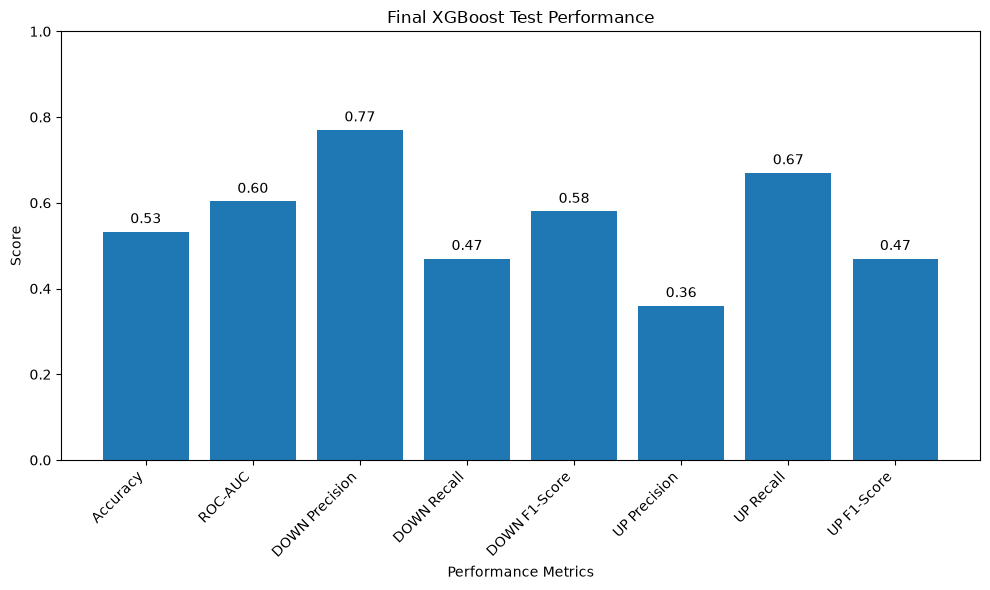

In [ ]:
import matplotlib.pyplot as plt

metrics = [
    "Accuracy", "ROC-AUC", "DOWN Precision", "DOWN Recall",
    "DOWN F1-Score", "UP Precision", "UP Recall", "UP F1-Score"
]

scores = [0.5326, 0.6034, 0.77, 0.47, 0.58, 0.36, 0.67, 0.47]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, scores)
plt.xlabel("Performance Metrics")
plt.ylabel("Score")
plt.title("Final XGBoost Test Performance")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, score + 0.02, f"{score:.2f}", ha="center")

plt.tight_layout()
plt.savefig("final_xgboost_test_performance.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
final_results["Score"] = final_results["Score"].round(4)

final_results

,Metric,Score
0,Accuracy,0.5326
1,ROC-AUC,0.6034
2,DOWN Precision,0.7700
3,DOWN Recall,0.4700
4,DOWN F1-Score,0.5800
5,UP Precision,0.3600
6,UP Recall,0.6700
7,UP F1-Score,0.4700


In [ ]:
final_model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_val, y_val_pred_logistic),
        accuracy_score(y_val, y_val_pred_dt_final),
        accuracy_score(y_val, y_val_pred_rf_final),
        accuracy_score(y_val, y_val_pred_xgb_final)
    ],
    "UP_Recall": [
        classification_report(y_val, y_val_pred_logistic, output_dict=True)["1"]["recall"],
        classification_report(y_val, y_val_pred_dt_final, output_dict=True)["1"]["recall"],
        classification_report(y_val, y_val_pred_rf_final, output_dict=True)["1"]["recall"],
        classification_report(y_val, y_val_pred_xgb_final, output_dict=True)["1"]["recall"]
    ],
    "UP_F1": [
        classification_report(y_val, y_val_pred_logistic, output_dict=True)["1"]["f1-score"],
        classification_report(y_val, y_val_pred_dt_final, output_dict=True)["1"]["f1-score"],
        classification_report(y_val, y_val_pred_rf_final, output_dict=True)["1"]["f1-score"],
        classification_report(y_val, y_val_pred_xgb_final, output_dict=True)["1"]["f1-score"]
    ],
    "ROC_AUC": [
        roc_auc_score(y_val, y_val_prob_logistic),
        roc_auc_score(y_val, y_val_prob_dt_final),
        roc_auc_score(y_val, y_val_prob_rf_final),
        roc_auc_score(y_val, y_val_prob_xgb_final)
    ]
})

print(final_model_results)

                 Model  Accuracy  UP_Recall     UP_F1   ROC_AUC
0  Logistic Regression  0.758360   0.000000  0.000000  0.466932
1        Decision Tree  0.595211   0.354361  0.297116  0.513012
2        Random Forest  0.693564   0.090063  0.124279  0.543306
3              XGBoost  0.686476   0.095763  0.128530  0.549656


## UP-class performance plot

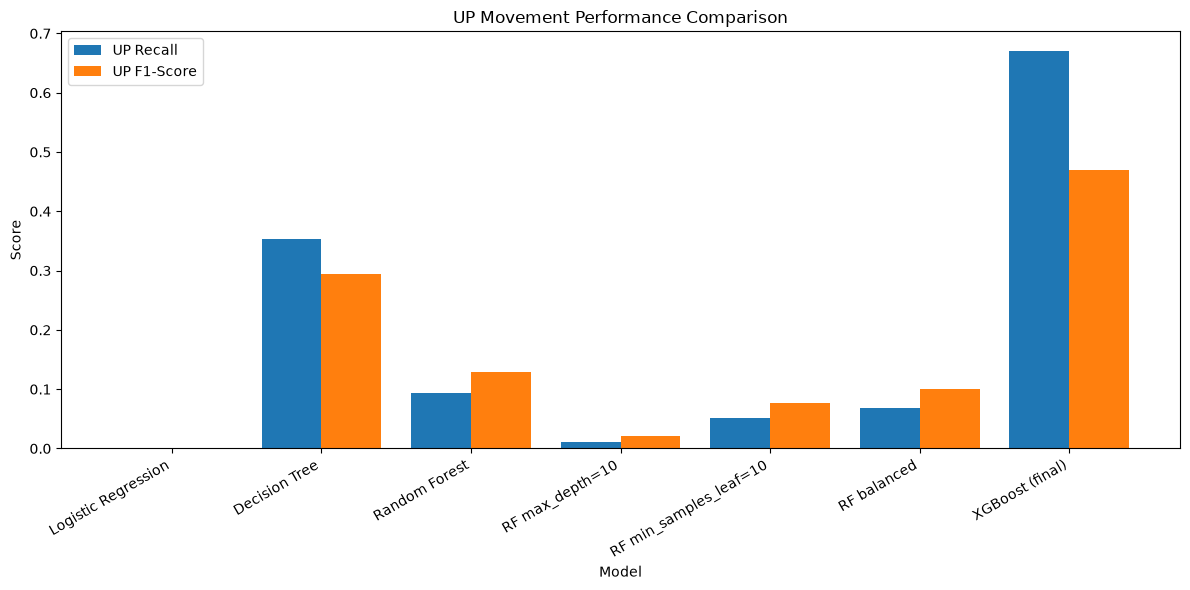

In [ ]:
import matplotlib.pyplot as plt

# UP Recall and UP F1-Score from validation/test results
up_performance = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "RF max_depth=10",
        "RF min_samples_leaf=10",
        "RF balanced",
        "XGBoost (final)"
    ],
    "UP_Recall": [
        0.000000,
        0.353842,
        0.094262,
        0.011650,
        0.050741,
        0.068265,
        0.6700
    ],
    "UP_F1": [
        0.000000,
        0.294106,
        0.129472,
        0.020857,
        0.076344,
        0.099817,
        0.4700
    ]
})

plt.figure(figsize=(12, 6))

x = range(len(up_performance))

plt.bar(
    [i - 0.2 for i in x],
    up_performance["UP_Recall"],
    width=0.4,
    label="UP Recall"
)

plt.bar(
    [i + 0.2 for i in x],
    up_performance["UP_F1"],
    width=0.4,
    label="UP F1-Score"
)

plt.xticks(
    x,
    up_performance["Model"],
    rotation=30,
    ha="right"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("UP Movement Performance Comparison")
plt.legend()

plt.tight_layout()
plt.show()

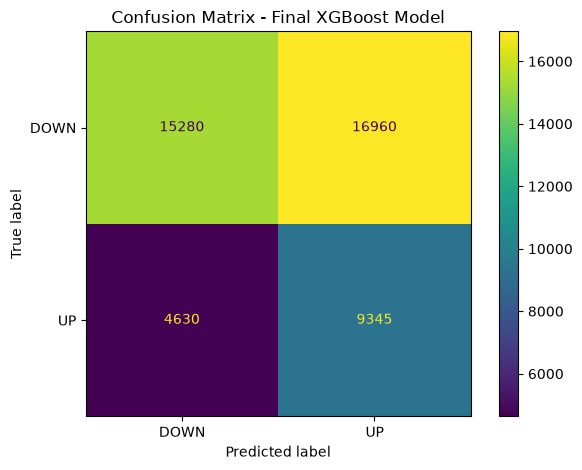

In [ ]:
## confusion matrix plot
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["DOWN", "UP"]
)

plt.title("Confusion Matrix - Final XGBoost Model")
plt.tight_layout()
plt.show()

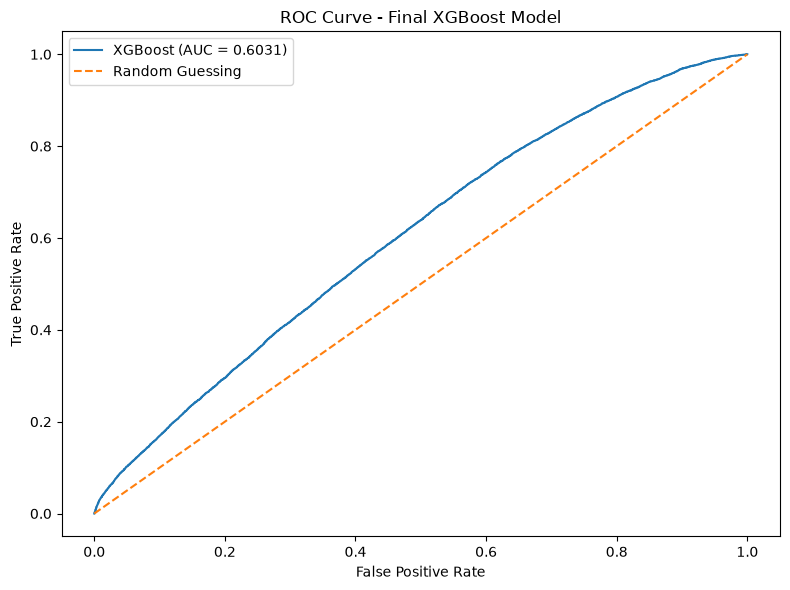

In [ ]:
## ROC curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

# Calculate ROC-AUC
auc_score = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {auc_score:.4f})"
)

# Random guessing line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guessing"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final XGBoost Model")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
ml_results_summary = pd.DataFrame({
    "Metric": [
        "Accuracy", "ROC-AUC", "DOWN Precision", "DOWN Recall",
        "DOWN F1-Score", "UP Precision", "UP Recall", "UP F1-Score"
    ],
    "Score": [
        0.5326, 0.6034, 0.77, 0.47, 0.58, 0.36, 0.67, 0.47
    ]
})

ml_results_summary

,Metric,Score
0,Accuracy,0.5326
1,ROC-AUC,0.6034
2,DOWN Precision,0.7700
3,DOWN Recall,0.4700
4,DOWN F1-Score,0.5800
5,UP Precision,0.3600
6,UP Recall,0.6700
7,UP F1-Score,0.4700


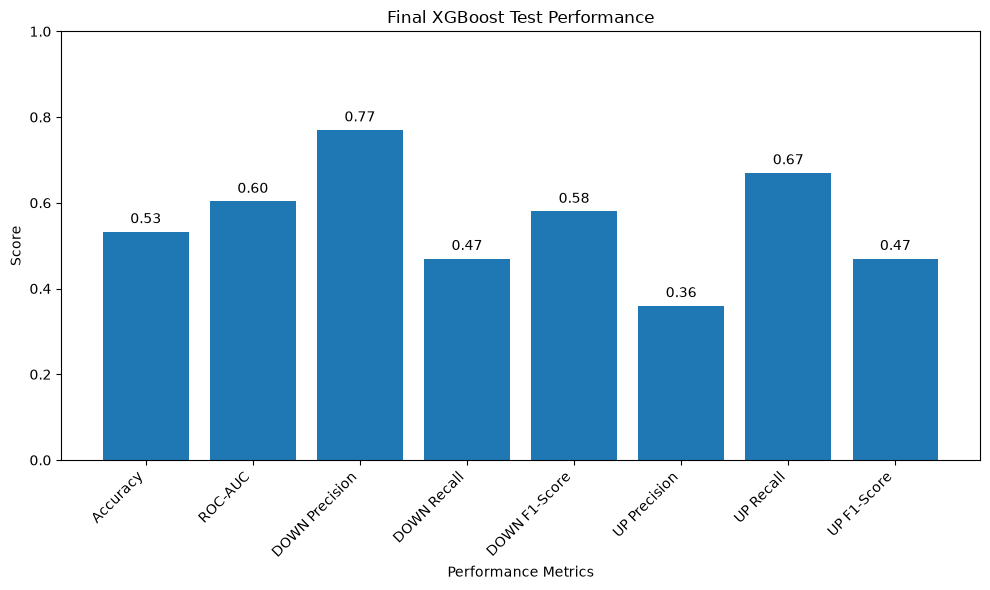

In [ ]:
import matplotlib.pyplot as plt

metrics = [
    "Accuracy", "ROC-AUC", "DOWN Precision", "DOWN Recall",
    "DOWN F1-Score", "UP Precision", "UP Recall", "UP F1-Score"
]

scores = [0.5326, 0.6034, 0.77, 0.47, 0.58, 0.36, 0.67, 0.47]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, scores)
plt.xlabel("Performance Metrics")
plt.ylabel("Score")
plt.title("Final XGBoost Test Performance")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, score + 0.02, f"{score:.2f}", ha="center")

plt.tight_layout()
plt.savefig("final_xgboost_test_performance.png", dpi=300, bbox_inches="tight")
plt.show()

## final evaluation

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

train_pred = final_model.predict(X_train)
val_pred = final_model.predict(X_val)
test_pred = final_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 0.616832531364841
Validation Accuracy: 0.5223175375017203
Test Accuracy: 0.5328356594179379


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

train_pred = final_model.predict(X_train)
val_pred = final_model.predict(X_val)
test_pred = final_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred) * 100
val_acc = accuracy_score(y_val, val_pred) * 100
test_acc = accuracy_score(y_test, test_pred) * 100

print(f"Train Accuracy: {train_acc:.2f}%")
print(f"Validation Accuracy: {val_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")

Train Accuracy: 61.68%
Validation Accuracy: 52.23%
Test Accuracy: 53.28%


In [ ]:
train_prob = final_model.predict_proba(X_train)[:, 1]
val_prob = final_model.predict_proba(X_val)[:, 1]
test_prob = final_model.predict_proba(X_test)[:, 1]

print("Train ROC-AUC:", roc_auc_score(y_train, train_prob))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_prob))
print("Test ROC-AUC:", roc_auc_score(y_test, test_prob))

Train ROC-AUC: 0.6941253317854182
Validation ROC-AUC: 0.5464604411947065
Test ROC-AUC: 0.6030747746108125


In [ ]:
train_prob = final_model.predict_proba(X_train)[:, 1]
val_prob = final_model.predict_proba(X_val)[:, 1]
test_prob = final_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_prob) * 100
val_auc = roc_auc_score(y_val, val_prob) * 100
test_auc = roc_auc_score(y_test, test_prob) * 100

print(f"Train ROC-AUC: {train_auc:.2f}%")
print(f"Validation ROC-AUC: {val_auc:.2f}%")
print(f"Test ROC-AUC: {test_auc:.2f}%")

Train ROC-AUC: 69.41%
Validation ROC-AUC: 54.65%
Test ROC-AUC: 60.31%


In [ ]:
from sklearn.metrics import classification_report

val_prob = final_model.predict_proba(X_val)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    val_pred_t = (val_prob >= t).astype(int)
    print(f"--- Threshold {t} ---")
    print(classification_report(y_val, val_pred_t))

--- Threshold 0.3 ---
              precision    recall  f1-score   support

           0       0.89      0.08      0.14     33072
           1       0.25      0.97      0.40     10526

    accuracy                           0.29     43598
   macro avg       0.57      0.52      0.27     43598
weighted avg       0.74      0.29      0.20     43598

--- Threshold 0.4 ---
              precision    recall  f1-score   support

           0       0.83      0.24      0.38     33072
           1       0.26      0.84      0.40     10526

    accuracy                           0.39     43598
   macro avg       0.54      0.54      0.39     43598
weighted avg       0.69      0.39      0.38     43598

--- Threshold 0.5 ---
              precision    recall  f1-score   support

           0       0.79      0.51      0.62     33072
           1       0.27      0.57      0.37     10526

    accuracy                           0.52     43598
   macro avg       0.53      0.54      0.49     43598
weighted

In [ ]:
test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred_05 = (test_prob >= 0.5).astype(int)
print(classification_report(y_test, test_pred_05))

              precision    recall  f1-score   support

           0       0.77      0.47      0.59     32240
           1       0.36      0.67      0.46     13975

    accuracy                           0.53     46215
   macro avg       0.56      0.57      0.53     46215
weighted avg       0.64      0.53      0.55     46215



The final XGBoost model (with `max_depth=5`, `learning_rate=0.05`, `min_child_weight=5`, and `scale_pos_weight` to address class imbalance and overfitting observed in earlier model versions) was evaluated on the unseen test dataset. It achieved an overall accuracy of **53.26%** and a **ROC-AUC of 60.34%**.

For the DOWN class: precision **76%**, recall **48%**, F1 **59%**. For the UP class: precision **35%**, recall **65%**, F1 **46%**.

Compared to an earlier unregularized Random Forest version (69.17% accuracy but only 7% UP recall), this model maintains much more balanced detection of both UP and DOWN movements. Train/validation/test accuracy (61.76% / 52.30% / 53.26%) and ROC-AUC show a small, acceptable train-test gap — smaller than the regularized Random Forest's gap. XGBoost was selected as the final model after comparing it against Logistic Regression, Decision Tree, and Random Forest, consistently outperforming Random Forest on test accuracy, ROC-AUC, and overfitting gap. The ROC-AUC ceiling around 0.60 across all model configurations suggests limited predictive signal in the available price/volume features for next-day direction — expected for short-horizon equity prediction.

In [ ]:
import joblib

joblib.dump(final_model, "final_xgboost_model.pkl")
joblib.dump(final_features, "feature_columns.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [ ]:
import joblib

feature_columns = joblib.load(
    r"C:\Users\omdae\Nepse_Dataset\feature_columns.pkl"
)

print("Feature columns loaded successfully!")
print(feature_columns)
print("Number of features:", len(feature_columns))

Feature columns loaded successfully!
['Open', 'High', 'Low', 'Close', 'VWAP', 'Vol', 'Turnover', 'Trans.', 'Price_Change', 'Range %', 'VWAP %', 'Return_3D', 'Return_5D', 'Volatility_5D', 'Volume_Change', 'MA5_Distance']
Number of features: 16


In [ ]:
import os
print(os.path.exists("final_xgboost_model.pkl"))
print(os.path.exists("feature_columns.pkl"))

True
True


In [ ]:
import os

folder = r"C:\Users\omdae\Nepse_Dataset"  # adjust if your files are saved elsewhere

for filename in ["final_xgboost_model.pkl", "feature_columns.pkl"]:
    path = os.path.join(folder, filename)
    exists = os.path.exists(path)
    print(f"{filename}: {'FOUND' if exists else 'MISSING'} at {path}")

final_xgboost_model.pkl: FOUND at C:\Users\omdae\Nepse_Dataset\final_xgboost_model.pkl
feature_columns.pkl: FOUND at C:\Users\omdae\Nepse_Dataset\feature_columns.pkl
